# Init-scale geometry, dimensionality, and transfer

This notebook tests how initialization scale (`init_scale`) affects:

- **State geometry**: PCA-based dimensionality (variance in first 2 PCs, number of PCs for 95% and 99% variance, optional participation ratio) for combined/core/comms pathways, **separately for same, near, and far** similarity conditions.
- **Representational movement**: hidden-state drift between phases (pre→A1, A1→B).
- **Transfer behaviour**: Holton-style error difference (initial B vs final A1).

We focus on a small set of RNN runs that share architecture and differ only in `init_scale`, using geometry participants `geom_sub_same`, `geom_sub_near`, `geom_sub_far`.


In [1]:
# 1. Setup and configuration

import sys
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Similarity colour scheme (fixed across all figures)
SIMILARITY_ORDER = ['same', 'near', 'far']
SIMILARITY_PALETTE = {'same': 'green', 'near': 'orange', 'far': 'blue'}


project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann
from a1b2.analysis.transfer_interference import prepare_pca_single_task
from a1b2.utils.figure_settings import task_colours
from a1b2.utils.figure_utils import plot_split_stim, get_axis_limits

data_folder = project_root / "data"
sim_folder = data_folder / "simulations"
config_path = project_root / "a1b2" / "models" / "experiments.json"
with open(config_path, "r") as f:
    settings = json.load(f)

print("Project root:", project_root)
print("Simulations folder:", sim_folder)


Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations


In [2]:
# 2. Select matching RNN conditions differing only in init_scale

TARGET_ARCH = "two_module_rnn"
TARGET_DIM_HIDDEN = 25
TARGET_NB_STEPS = 2
TARGET_ROUTING = "shared"
TARGET_COMMON_READOUT = True
TARGET_COMMON_INPUT = False
TARGET_SPARSITY = 1.0


def want_condition_init_scale(c):
    if c.get("arch") != TARGET_ARCH:
        return False
    if c.get("dim_hidden") != TARGET_DIM_HIDDEN:
        return False
    if c.get("nb_steps", 1) != TARGET_NB_STEPS:
        return False
    if c.get("input_routing", "shared") != TARGET_ROUTING:
        return False
    if c.get("common_readout", True) is not TARGET_COMMON_READOUT:
        return False
    if c.get("common_input", False) is not TARGET_COMMON_INPUT:
        return False
    if float(c.get("sparsity", TARGET_SPARSITY)) != TARGET_SPARSITY:
        return False
    return True


selected_conditions = [c for c in settings["conditions"] if want_condition_init_scale(c)]
rows = []
for c in selected_conditions:
    init_scale = c.get("init_scale", None)
    # Default (no init_scale in config) = PyTorch default scale 1.0; set explicitly so tables and plots include it
    if init_scale is None or (isinstance(init_scale, float) and np.isnan(init_scale)):
        init_scale = 1.0
    run_id = build_run_id(c)
    path = sim_folder / run_id
    rows.append({
        "name": c.get("name"),
        "run_id": run_id,
        "init_scale": init_scale,
        "sparsity": c.get("sparsity"),
        "input_routing": c.get("input_routing", "shared"),
        "common_readout": c.get("common_readout", True),
        "path_exists": path.exists(),
        "path": str(path),
    })

init_scale_conditions = pd.DataFrame(rows)
display(init_scale_conditions)


,name,run_id,init_scale,sparsity,input_routing,common_readout,path_exists,path
0,two_module_rnn_25_nb2,two_module_rnn_25_nb2_nb2_shared_sp1.0_sep_cr_RNN,1.00,1.0,shared,True,True,/home/kat/workspace/Structure-Function-Analysi...
1,two_module_rnn_25_nb2_init0.1,two_module_rnn_25_nb2_init0.1_nb2_shared_sp1.0...,0.10,1.0,shared,True,True,/home/kat/workspace/Structure-Function-Analysi...
2,two_module_rnn_25_nb2_init0.01,two_module_rnn_25_nb2_init0.01_nb2_shared_sp1....,0.01,1.0,shared,True,True,/home/kat/workspace/Structure-Function-Analysi...


In [3]:
# Filter to conditions with existing simulation folders and at least one init_scale variant

valid = init_scale_conditions[init_scale_conditions["path_exists"]]
if valid["init_scale"].nunique() <= 1:
    print("Warning: fewer than two distinct init_scale values with existing runs.")
valid


,name,run_id,init_scale,sparsity,input_routing,common_readout,path_exists,path
0,two_module_rnn_25_nb2,two_module_rnn_25_nb2_nb2_shared_sp1.0_sep_cr_RNN,1.00,1.0,shared,True,True,/home/kat/workspace/Structure-Function-Analysi...
1,two_module_rnn_25_nb2_init0.1,two_module_rnn_25_nb2_init0.1_nb2_shared_sp1.0...,0.10,1.0,shared,True,True,/home/kat/workspace/Structure-Function-Analysi...
2,two_module_rnn_25_nb2_init0.01,two_module_rnn_25_nb2_init0.01_nb2_shared_sp1....,0.01,1.0,shared,True,True,/home/kat/workspace/Structure-Function-Analysi...


In [4]:
# 3. Load ANN/RNN data for selected runs

all_ann_data = {}
for _, row in valid.iterrows():
    run_id = row["run_id"]
    path = Path(row["path"])
    ann_data = ann.load_ann_data(str(path), load_rnn_extra=True)
    # Require at least one participant for same/near/far
    if len(ann_data["same"]) > 0 and len(ann_data["near"]) > 0 and len(ann_data["far"]) > 0:
        all_ann_data[run_id] = {"data": ann_data, "init_scale": row["init_scale"]}

run_labels = list(all_ann_data.keys())
print("Loaded", len(run_labels), "runs with all three schedules.")
for rid in run_labels:
    d = all_ann_data[rid]["data"]
    scale = all_ann_data[rid]["init_scale"]
    print(f"  {rid} (init_scale={scale}): same={len(d['same'])} near={len(d['near'])} far={len(d['far'])}")


Loaded 3 runs with all three schedules.
  two_module_rnn_25_nb2_nb2_shared_sp1.0_sep_cr_RNN (init_scale=1.0): same=103 near=101 far=101
  two_module_rnn_25_nb2_init0.1_nb2_shared_sp1.0_sep_cr_RNN_init0.1 (init_scale=0.1): same=103 near=101 far=101
  two_module_rnn_25_nb2_init0.01_nb2_shared_sp1.0_sep_cr_RNN_init0.01 (init_scale=0.01): same=103 near=101 far=101


In [5]:
# 4. Compute per-participant metrics: representation, transfer, drift

rep_records = []
transfer_records = []
drift_records = []

for run_id in run_labels:
    bundle = all_ann_data[run_id]
    ann_data = bundle["data"]
    init_scale = bundle["init_scale"]

    for cond_name, entries in ann_data.items():  # cond_name: same/near/far
        for entry in entries:
            pid = str(entry["participant"])

            # --- Transfer metric (Holton-style proxy) ---
            acc = np.asarray(entry["accuracy"])  # (3 phases, n_trials)
            if acc.ndim != 2 or acc.shape[0] < 2:
                continue
            A1_acc = acc[0, 1::2]  # winter trials A1
            B_acc = acc[1, 1::2]   # winter trials B
            if len(A1_acc) < 6 or len(B_acc) < 6:
                continue
            final_A1 = float(np.mean(A1_acc[-6:]))
            init_B = float(np.mean(B_acc[:6]))
            error_diff = init_B - final_A1
            transfer_records.append({
                "run_id": run_id,
                "init_scale": init_scale,
                "condition": cond_name,
                "participant": pid,
                "error_diff": error_diff,
            })

            # --- Drift metrics: pre→A1 and A1→B ---
            pre = entry.get("hiddens_pre_training")
            post_A = entry.get("hiddens_post_phase_0")
            post_B = entry.get("hiddens_post_phase_1")
            if pre is not None and post_A is not None and post_B is not None:
                drift_preA = ann.compute_hidden_drift(pre, post_A)
                drift_AB = ann.compute_hidden_drift(post_A, post_B)
                drift_records.append({
                    "run_id": run_id,
                    "init_scale": init_scale,
                    "condition": cond_name,
                    "participant": pid,
                    "drift_preA": drift_preA,
                    "drift_AB": drift_AB,
                })

            # --- Representation metrics: combined/core/comms, per phase ---
            for phase_idx, phase_name in [(0, "post_A"), (1, "post_B"), (2, "post_A2")]:
                phase_key = f"hiddens_post_phase_{phase_idx}"
                if phase_key not in entry:
                    continue
                for path in ("combined", "core", "comms"):
                    try:
                        hids = ann._get_last_step_geometry_hids(entry, phase_idx, path=path)
                    except KeyError:
                        continue
                    metrics = ann.compute_state_representation_metrics(
                        hids,
                        variance_thresholds=(0.95, 0.99),
                        top_k=2,
                    )
                    row = {
                        "run_id": run_id,
                        "init_scale": init_scale,
                        "condition": cond_name,
                        "phase": phase_name,
                        "pathway": path,
                        "participant": pid,
                        "var_topk": metrics["var_topk"],
                    }
                    for thr, n_comp in metrics["n_components"].items():
                        key = f"n_pcs_{int(thr * 100)}"
                        row[key] = n_comp
                    # Optional: participation ratio
                    try:
                        pr = ann.compute_participation_ratio(hids)
                        row["pr"] = pr
                    except Exception:
                        row["pr"] = np.nan
                    rep_records.append(row)

rep_df = pd.DataFrame.from_records(rep_records)
transfer_df = pd.DataFrame.from_records(transfer_records)
drift_df = pd.DataFrame.from_records(drift_records)

print("rep_df shape:", rep_df.shape)
print("transfer_df shape:", transfer_df.shape)
print("drift_df shape:", drift_df.shape)
rep_df.head(), transfer_df.head(), drift_df.head()


rep_df shape: (6405, 10)
transfer_df shape: (915, 5)
drift_df shape: (0, 0)


(                                              run_id  init_scale condition  \
 0  two_module_rnn_25_nb2_nb2_shared_sp1.0_sep_cr_RNN         1.0      same   
 1  two_module_rnn_25_nb2_nb2_shared_sp1.0_sep_cr_RNN         1.0      same   
 2  two_module_rnn_25_nb2_nb2_shared_sp1.0_sep_cr_RNN         1.0      same   
 3  two_module_rnn_25_nb2_nb2_shared_sp1.0_sep_cr_RNN         1.0      same   
 4  two_module_rnn_25_nb2_nb2_shared_sp1.0_sep_cr_RNN         1.0      same   
 
      phase   pathway            participant  var_topk  n_pcs_95  n_pcs_99  \
 0   post_A  combined   sim_study2_same_sub9  0.458655        10        11   
 1   post_B  combined   sim_study2_same_sub9  0.559554        10        11   
 2  post_A2  combined   sim_study2_same_sub9  0.535509        10        11   
 3   post_A  combined  sim_study1_same_sub58  0.428799        10        11   
 4   post_B  combined  sim_study1_same_sub58  0.530822         9        11   
 
          pr  
 0  6.956267  
 1  5.499686  
 2  5.835

In [6]:
# 5. Aggregate metrics by run, init_scale, similarity, phase, and pathway

if not rep_df.empty:
    rep_summary = (
        rep_df
        .groupby(["run_id", "init_scale", "condition", "phase", "pathway"], as_index=False)
        .agg({
            "var_topk": "mean",
            "n_pcs_95": "mean",
            "n_pcs_99": "mean",
            "pr": "mean",
        })
    )
    display(rep_summary.head())
else:
    print("No representation metrics available.")

if not transfer_df.empty:
    transfer_summary = (
        transfer_df
        .groupby(["run_id", "init_scale", "condition"], as_index=False)
        .agg({"error_diff": "mean"})
    )
    display(transfer_summary.head())
else:
    print("No transfer metrics available.")

if not drift_df.empty:
    drift_summary = (
        drift_df
        .groupby(["run_id", "init_scale", "condition"], as_index=False)
        .agg({"drift_preA": "mean", "drift_AB": "mean"})
    )
    display(drift_summary.head())
else:
    print("No drift metrics available.")


,run_id,init_scale,condition,phase,pathway,var_topk,n_pcs_95,n_pcs_99,pr
0,two_module_rnn_25_nb2_init0.01_nb2_shared_sp1....,0.01,far,post_A,combined,0.999742,2.0,2.0,1.972166
1,two_module_rnn_25_nb2_init0.01_nb2_shared_sp1....,0.01,far,post_A,comms,0.999742,2.0,2.0,1.971780
2,two_module_rnn_25_nb2_init0.01_nb2_shared_sp1....,0.01,far,post_A,core,0.999735,2.0,2.0,1.971601
3,two_module_rnn_25_nb2_init0.01_nb2_shared_sp1....,0.01,far,post_A2,combined,0.582004,4.0,4.0,3.847875
4,two_module_rnn_25_nb2_init0.01_nb2_shared_sp1....,0.01,far,post_A2,comms,0.583432,4.0,4.0,3.844070


,run_id,init_scale,condition,error_diff
0,two_module_rnn_25_nb2_init0.01_nb2_shared_sp1....,0.01,far,-0.610689
1,two_module_rnn_25_nb2_init0.01_nb2_shared_sp1....,0.01,near,-0.468160
2,two_module_rnn_25_nb2_init0.01_nb2_shared_sp1....,0.01,same,-0.452433
3,two_module_rnn_25_nb2_init0.1_nb2_shared_sp1.0...,0.10,far,-0.610357
4,two_module_rnn_25_nb2_init0.1_nb2_shared_sp1.0...,0.10,near,-0.469363


No drift metrics available.


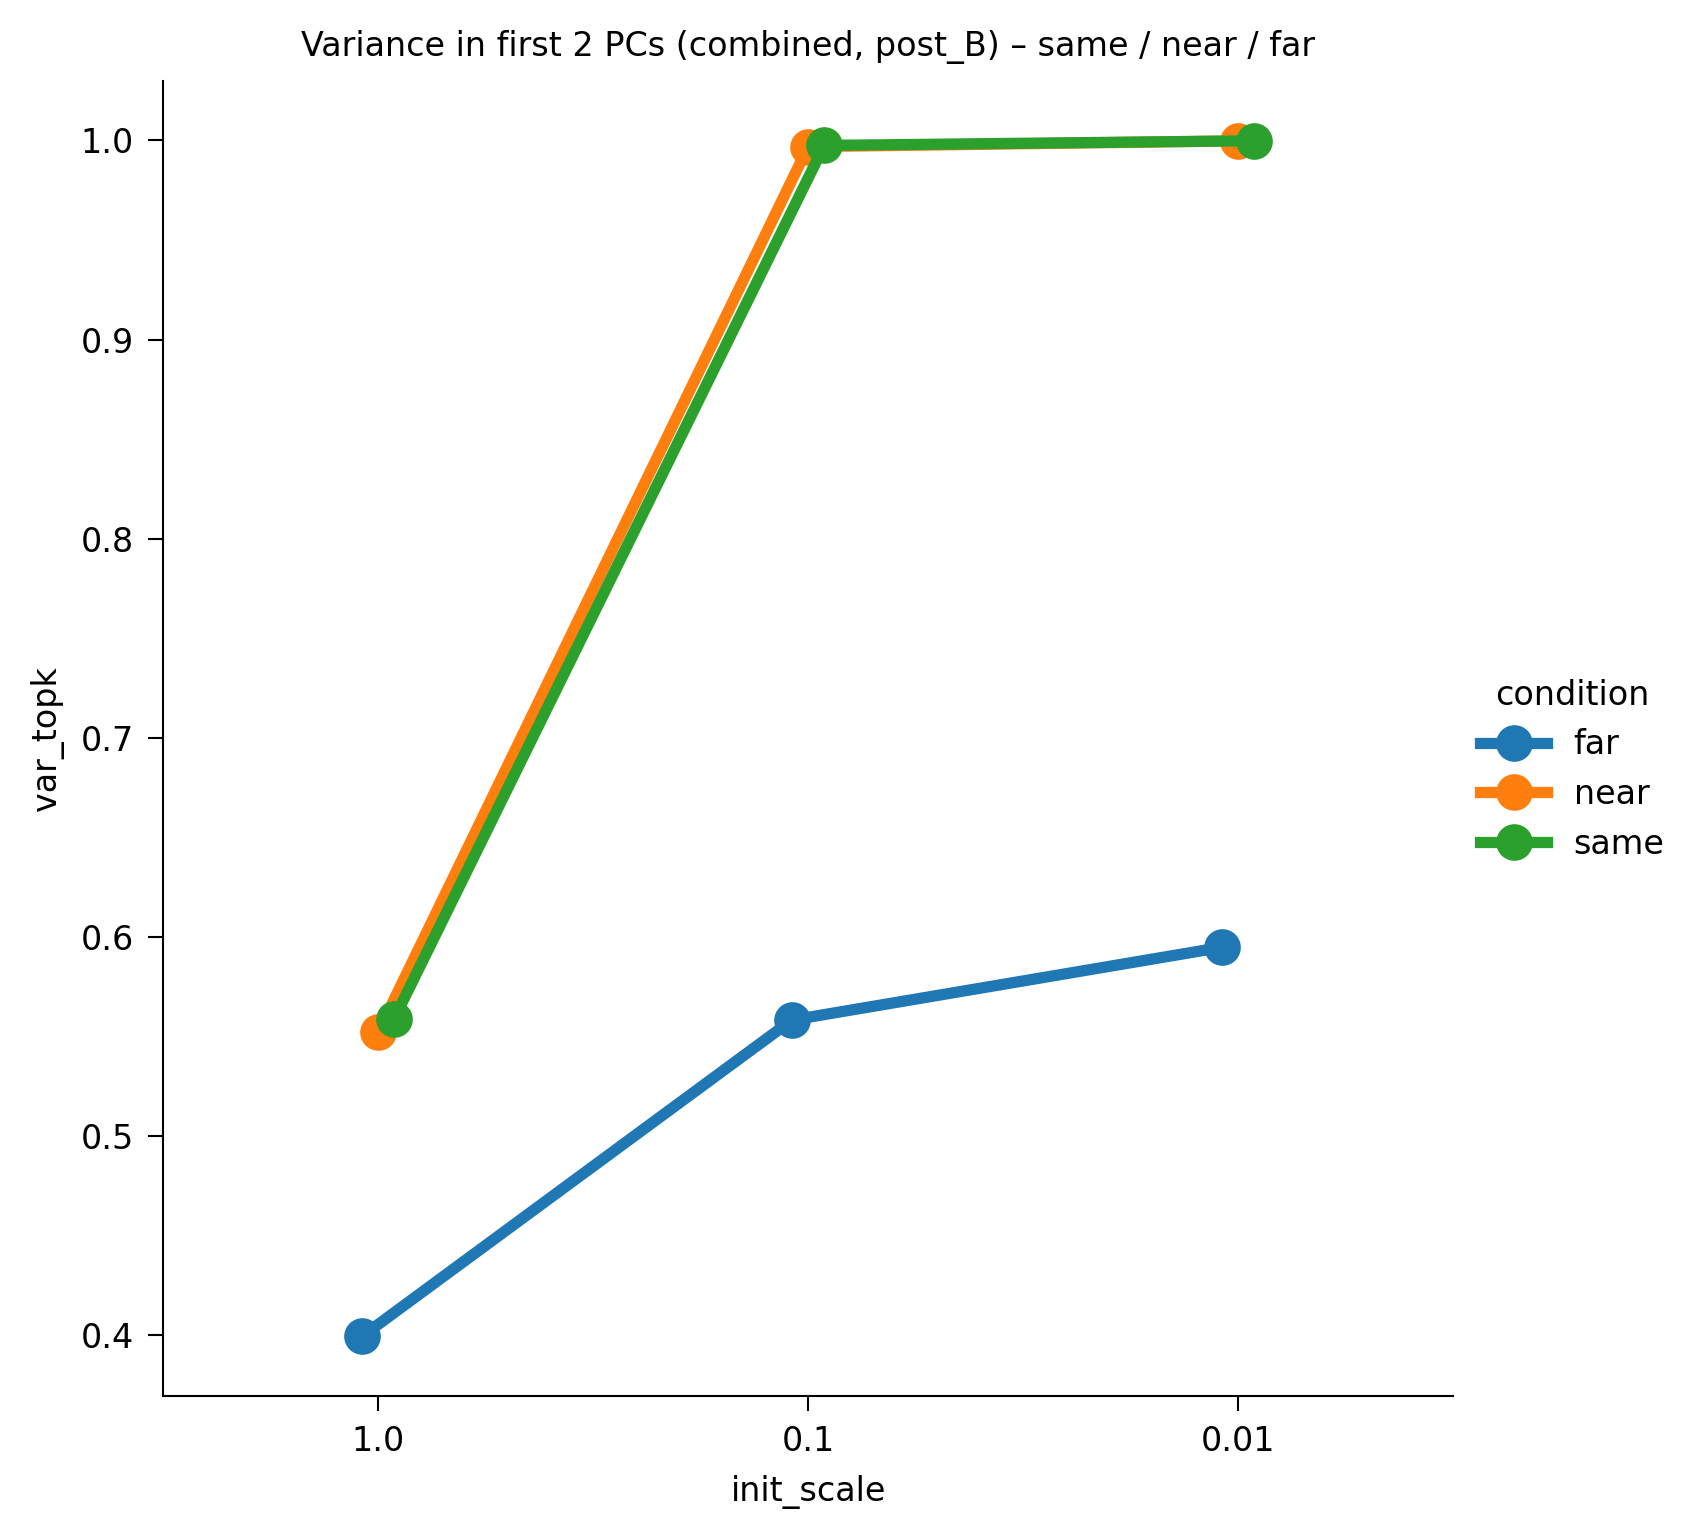

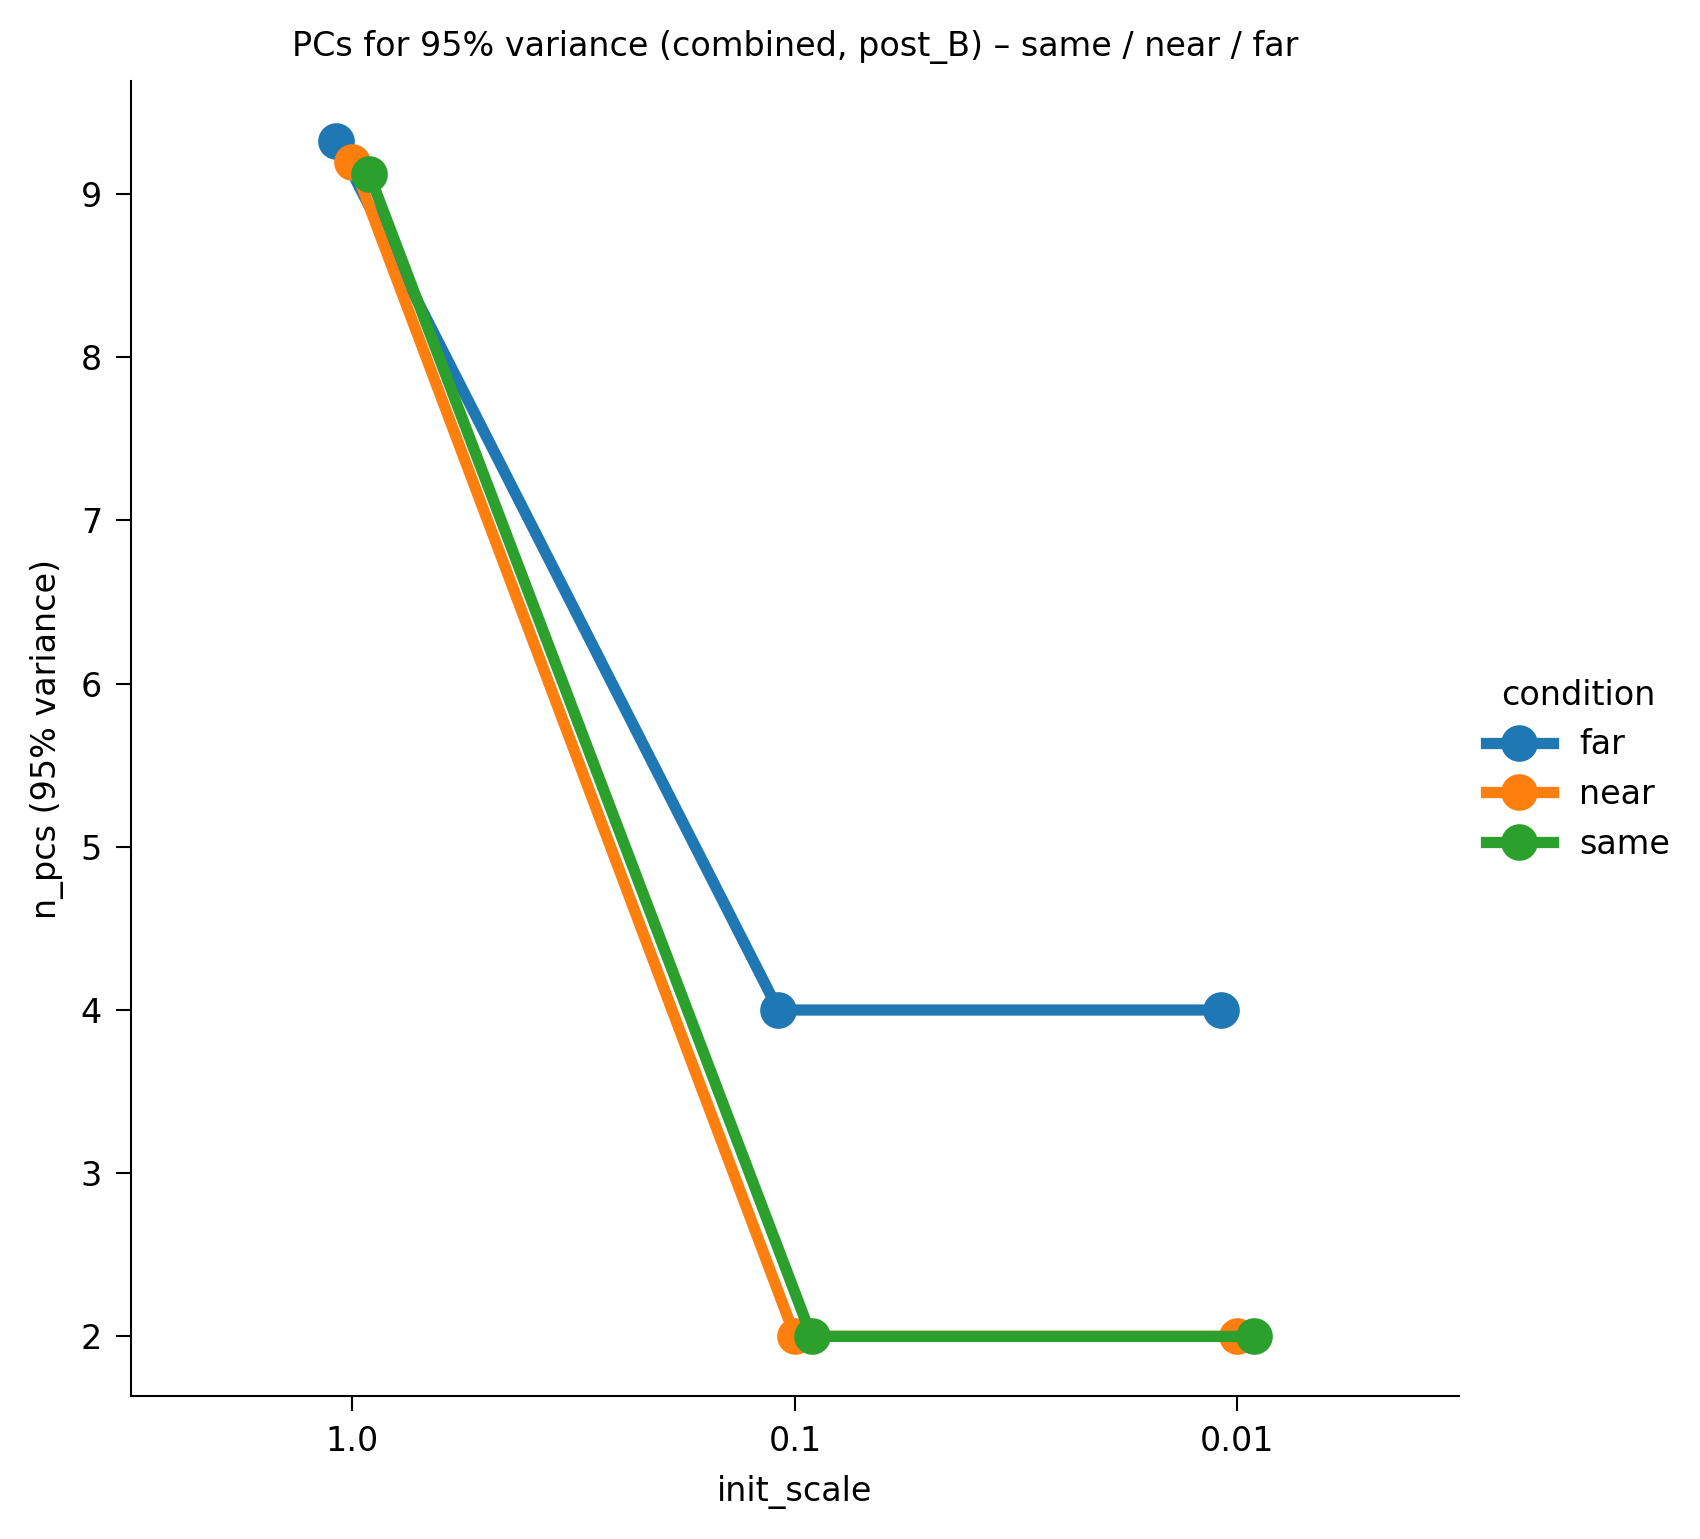

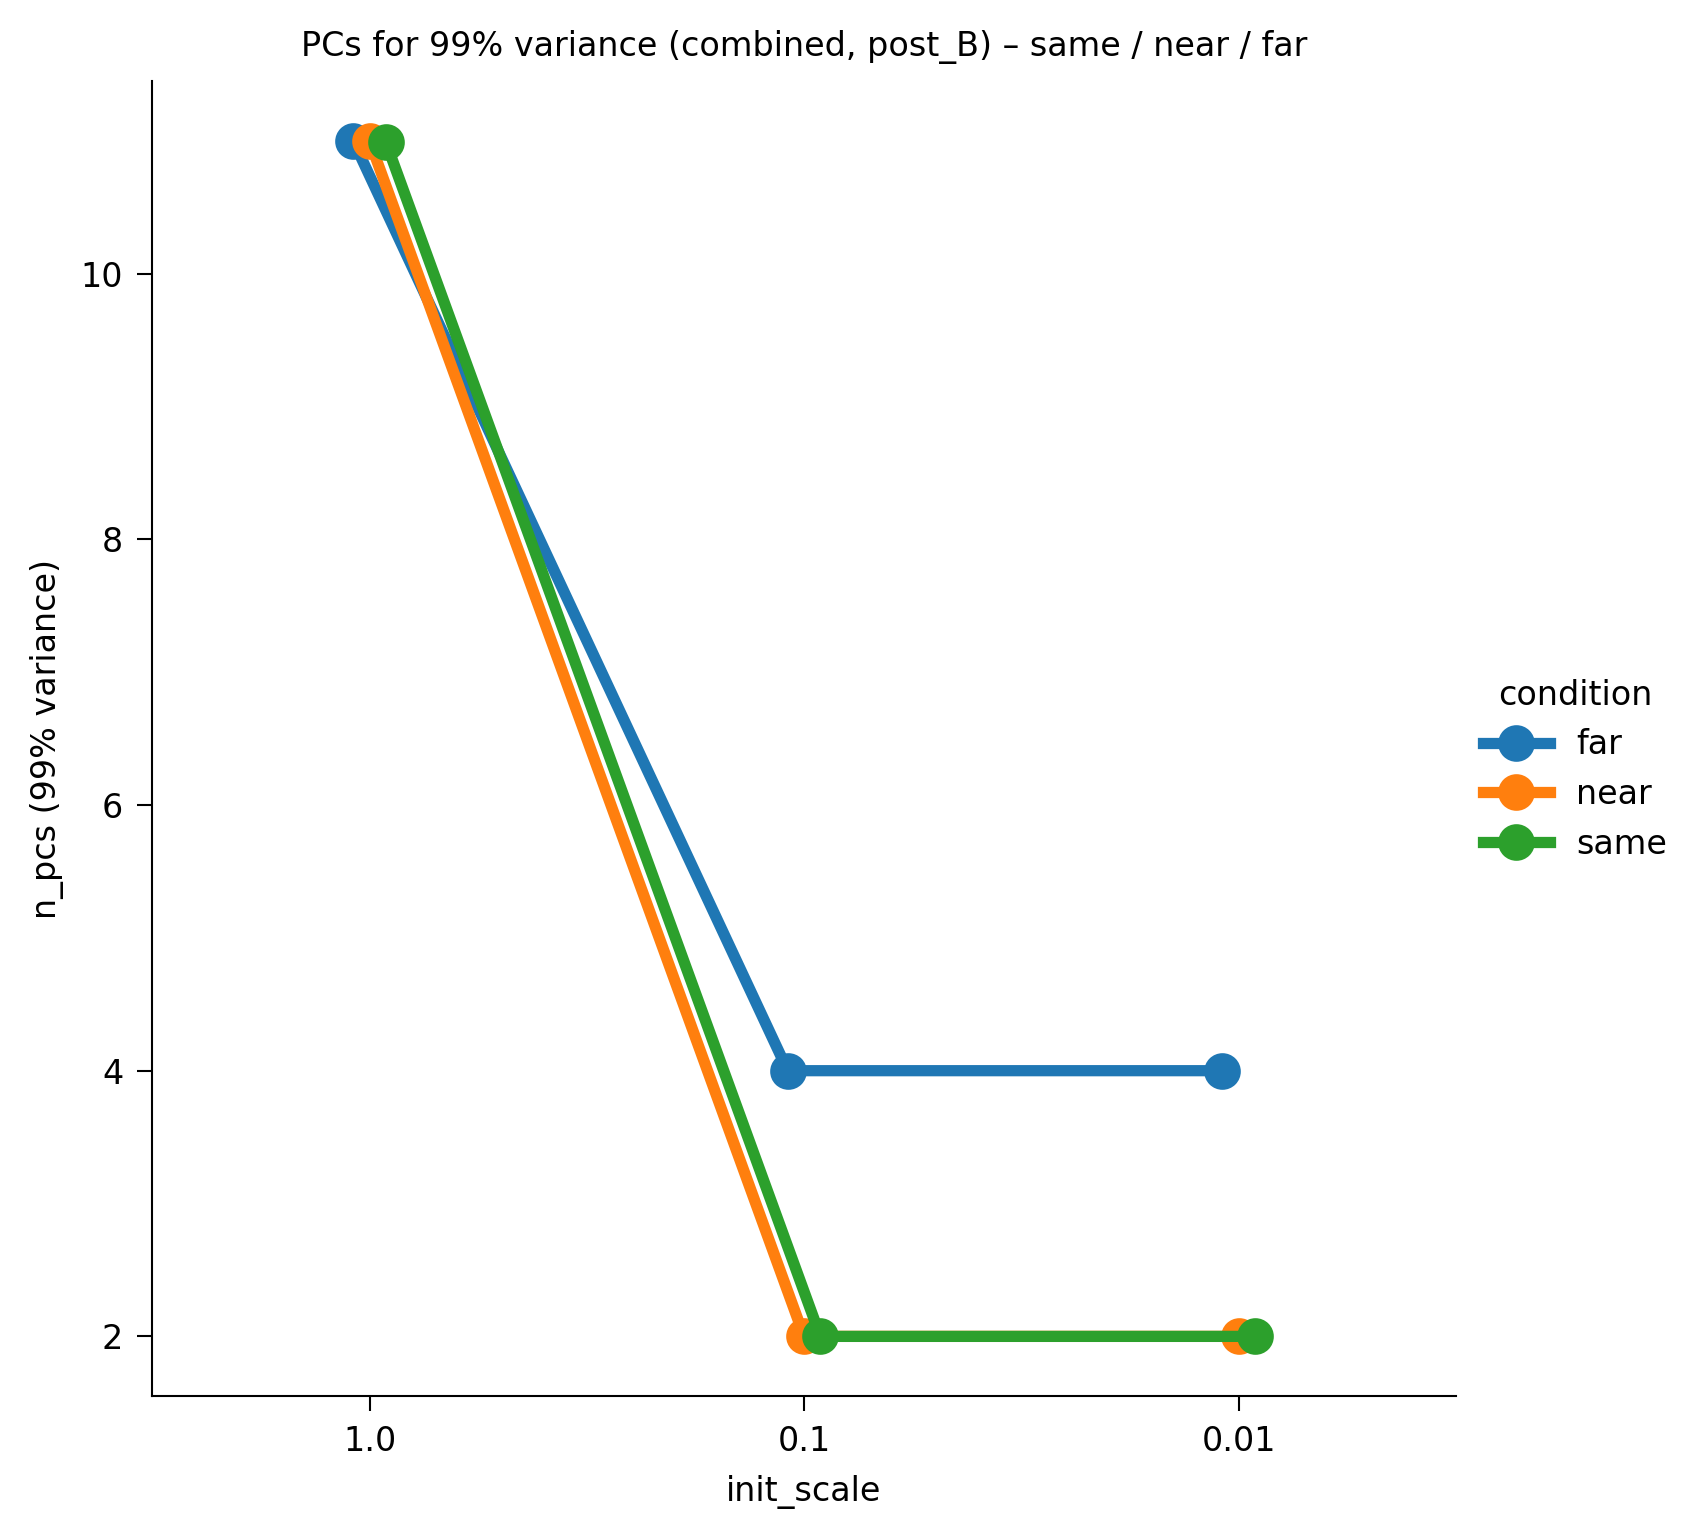

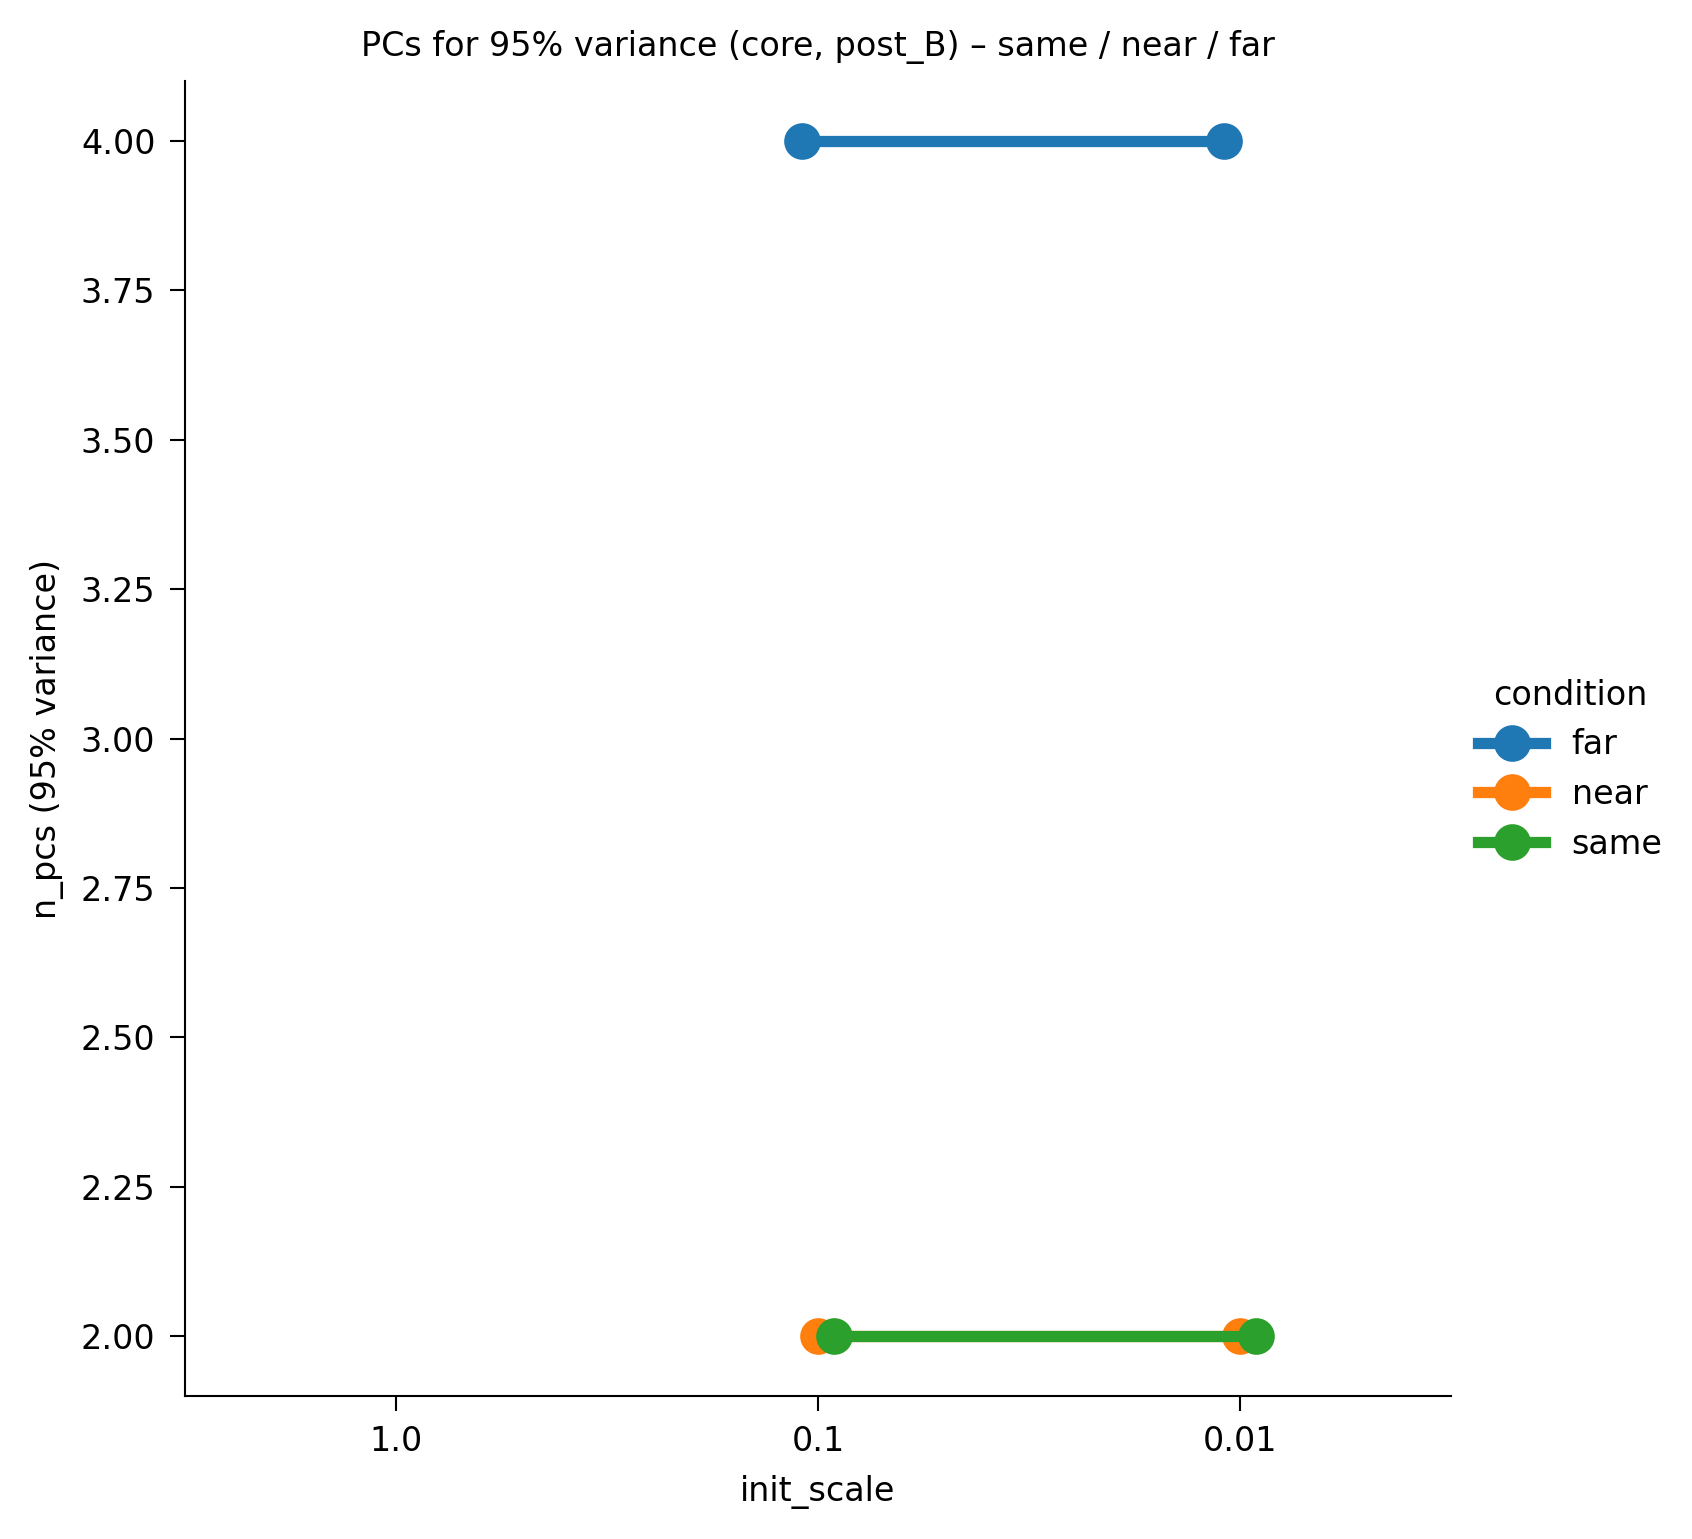

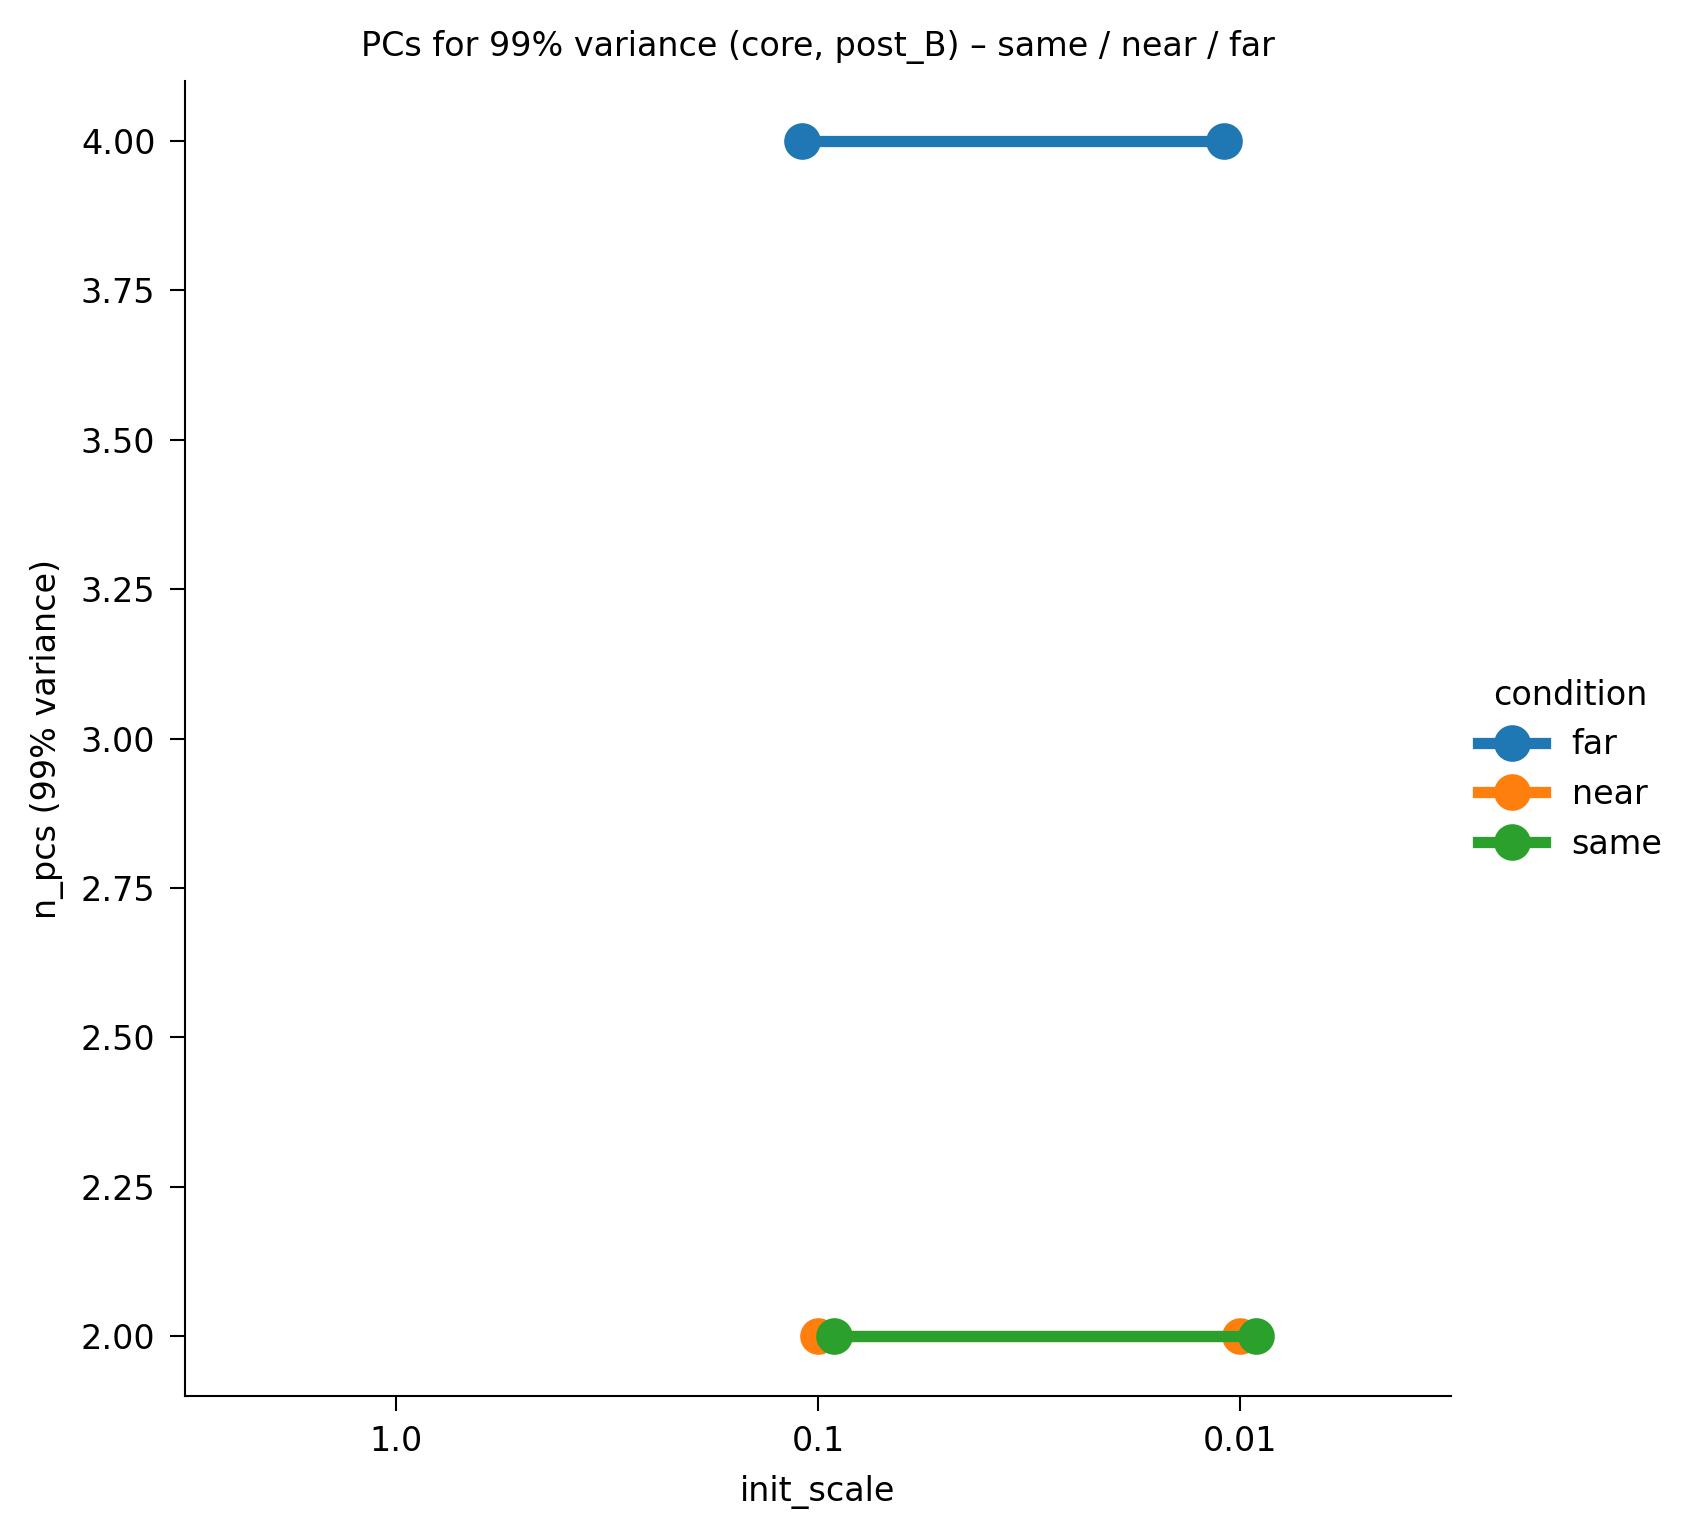

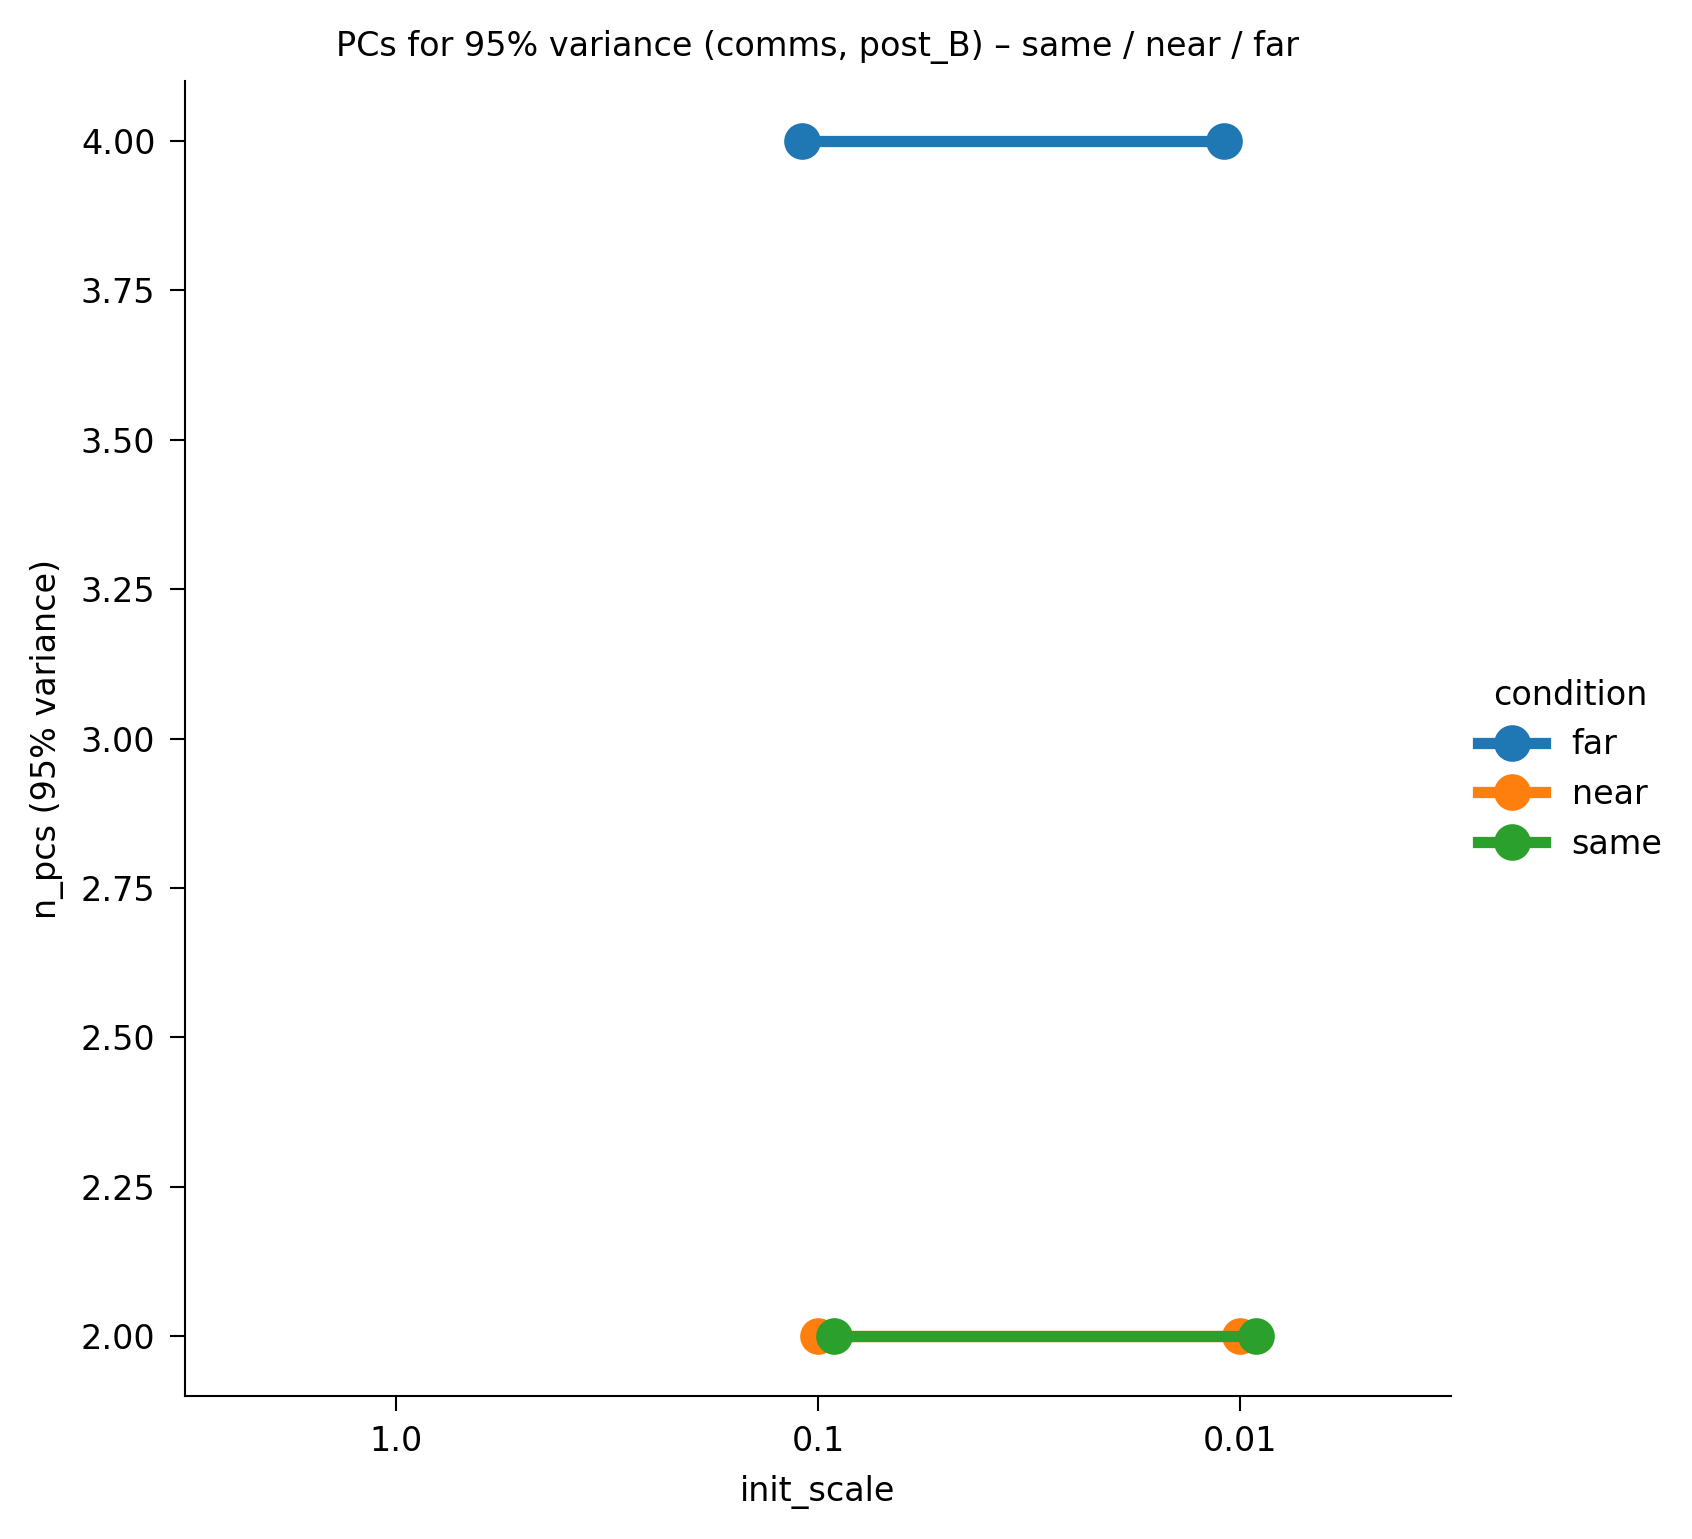

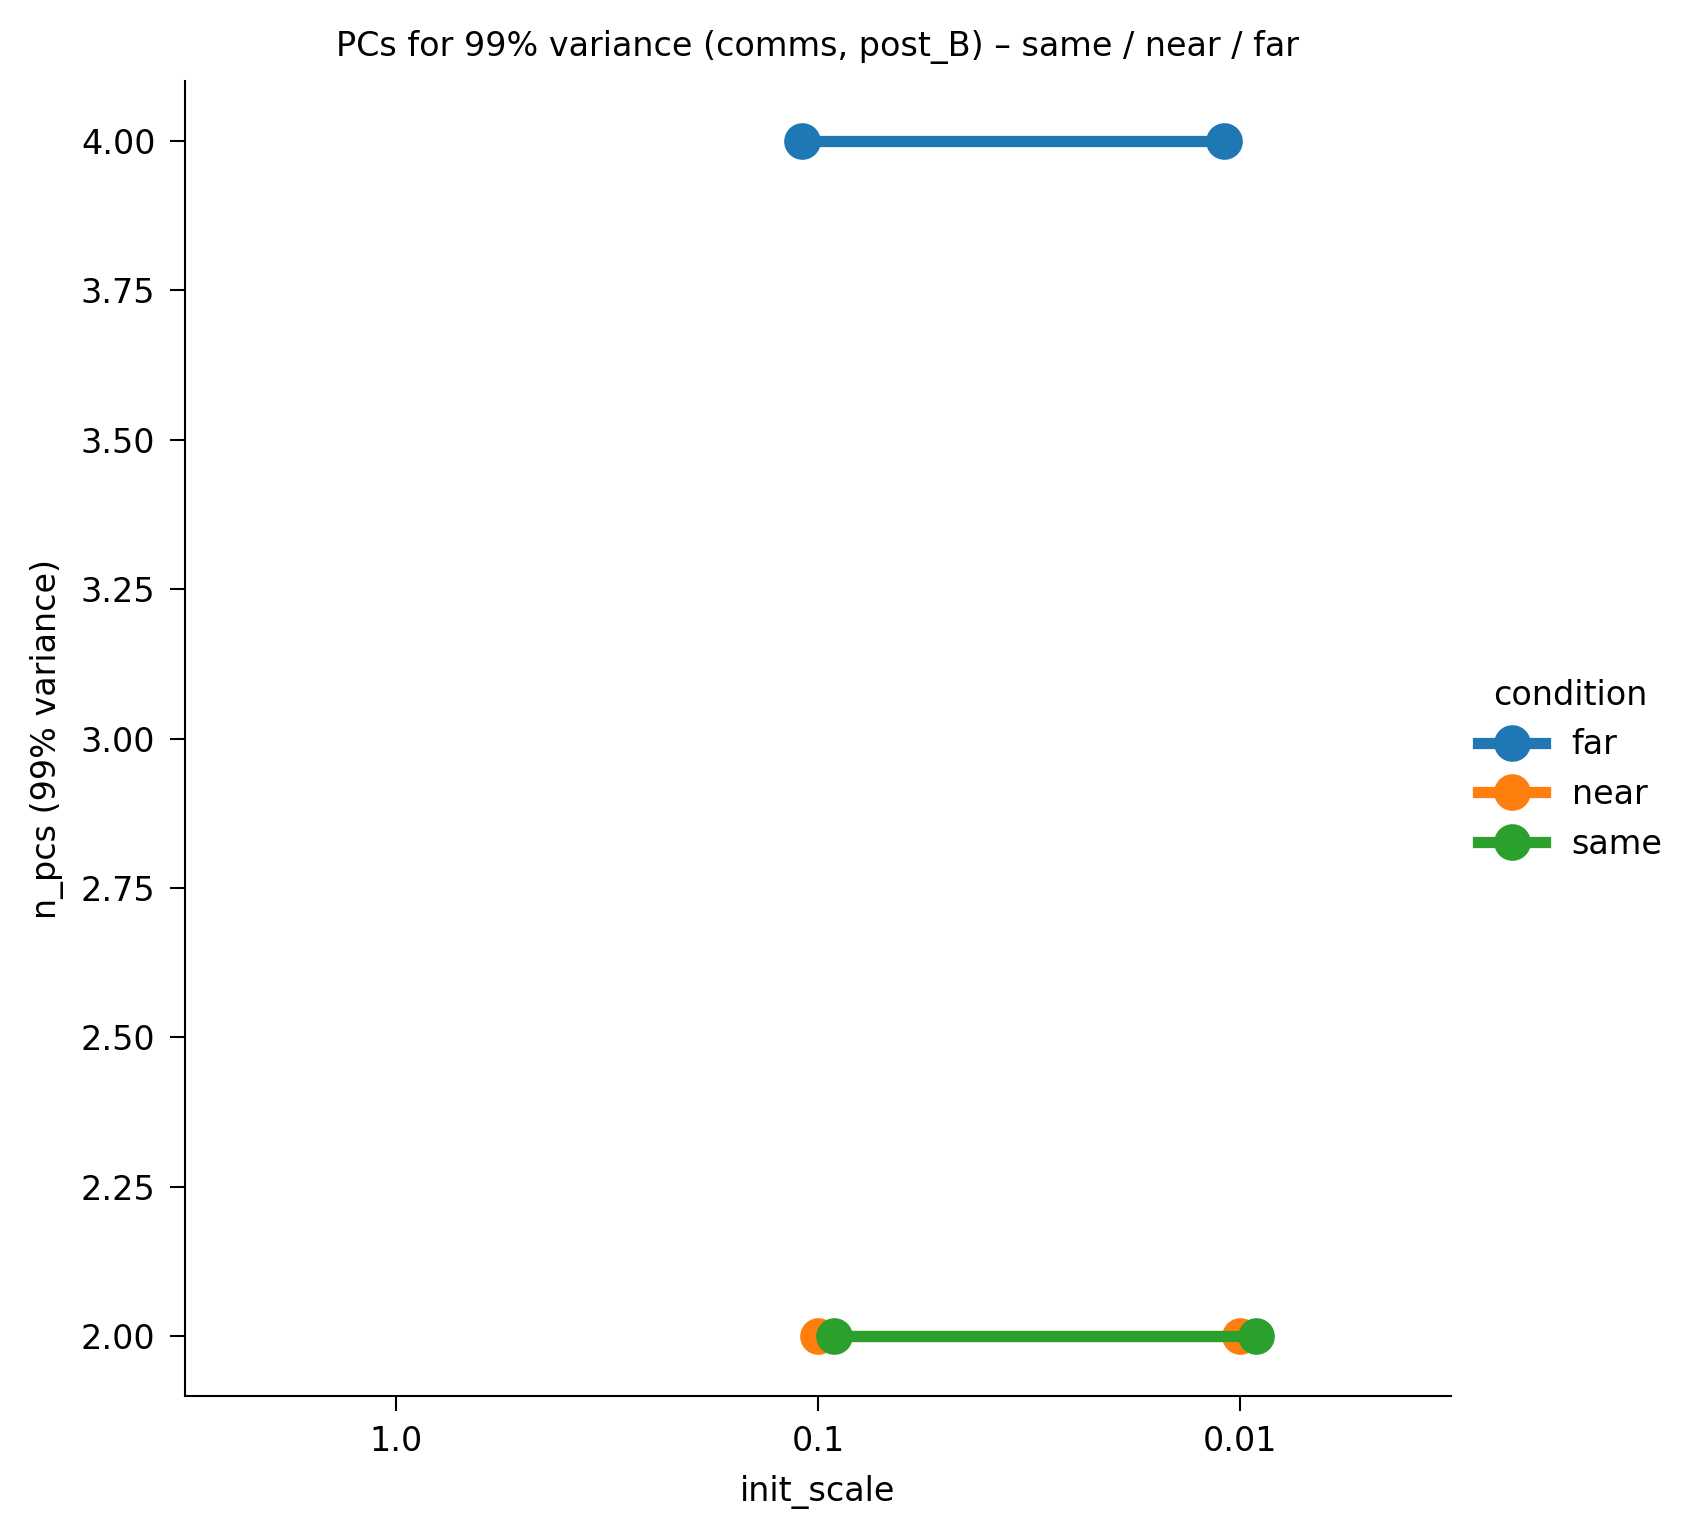

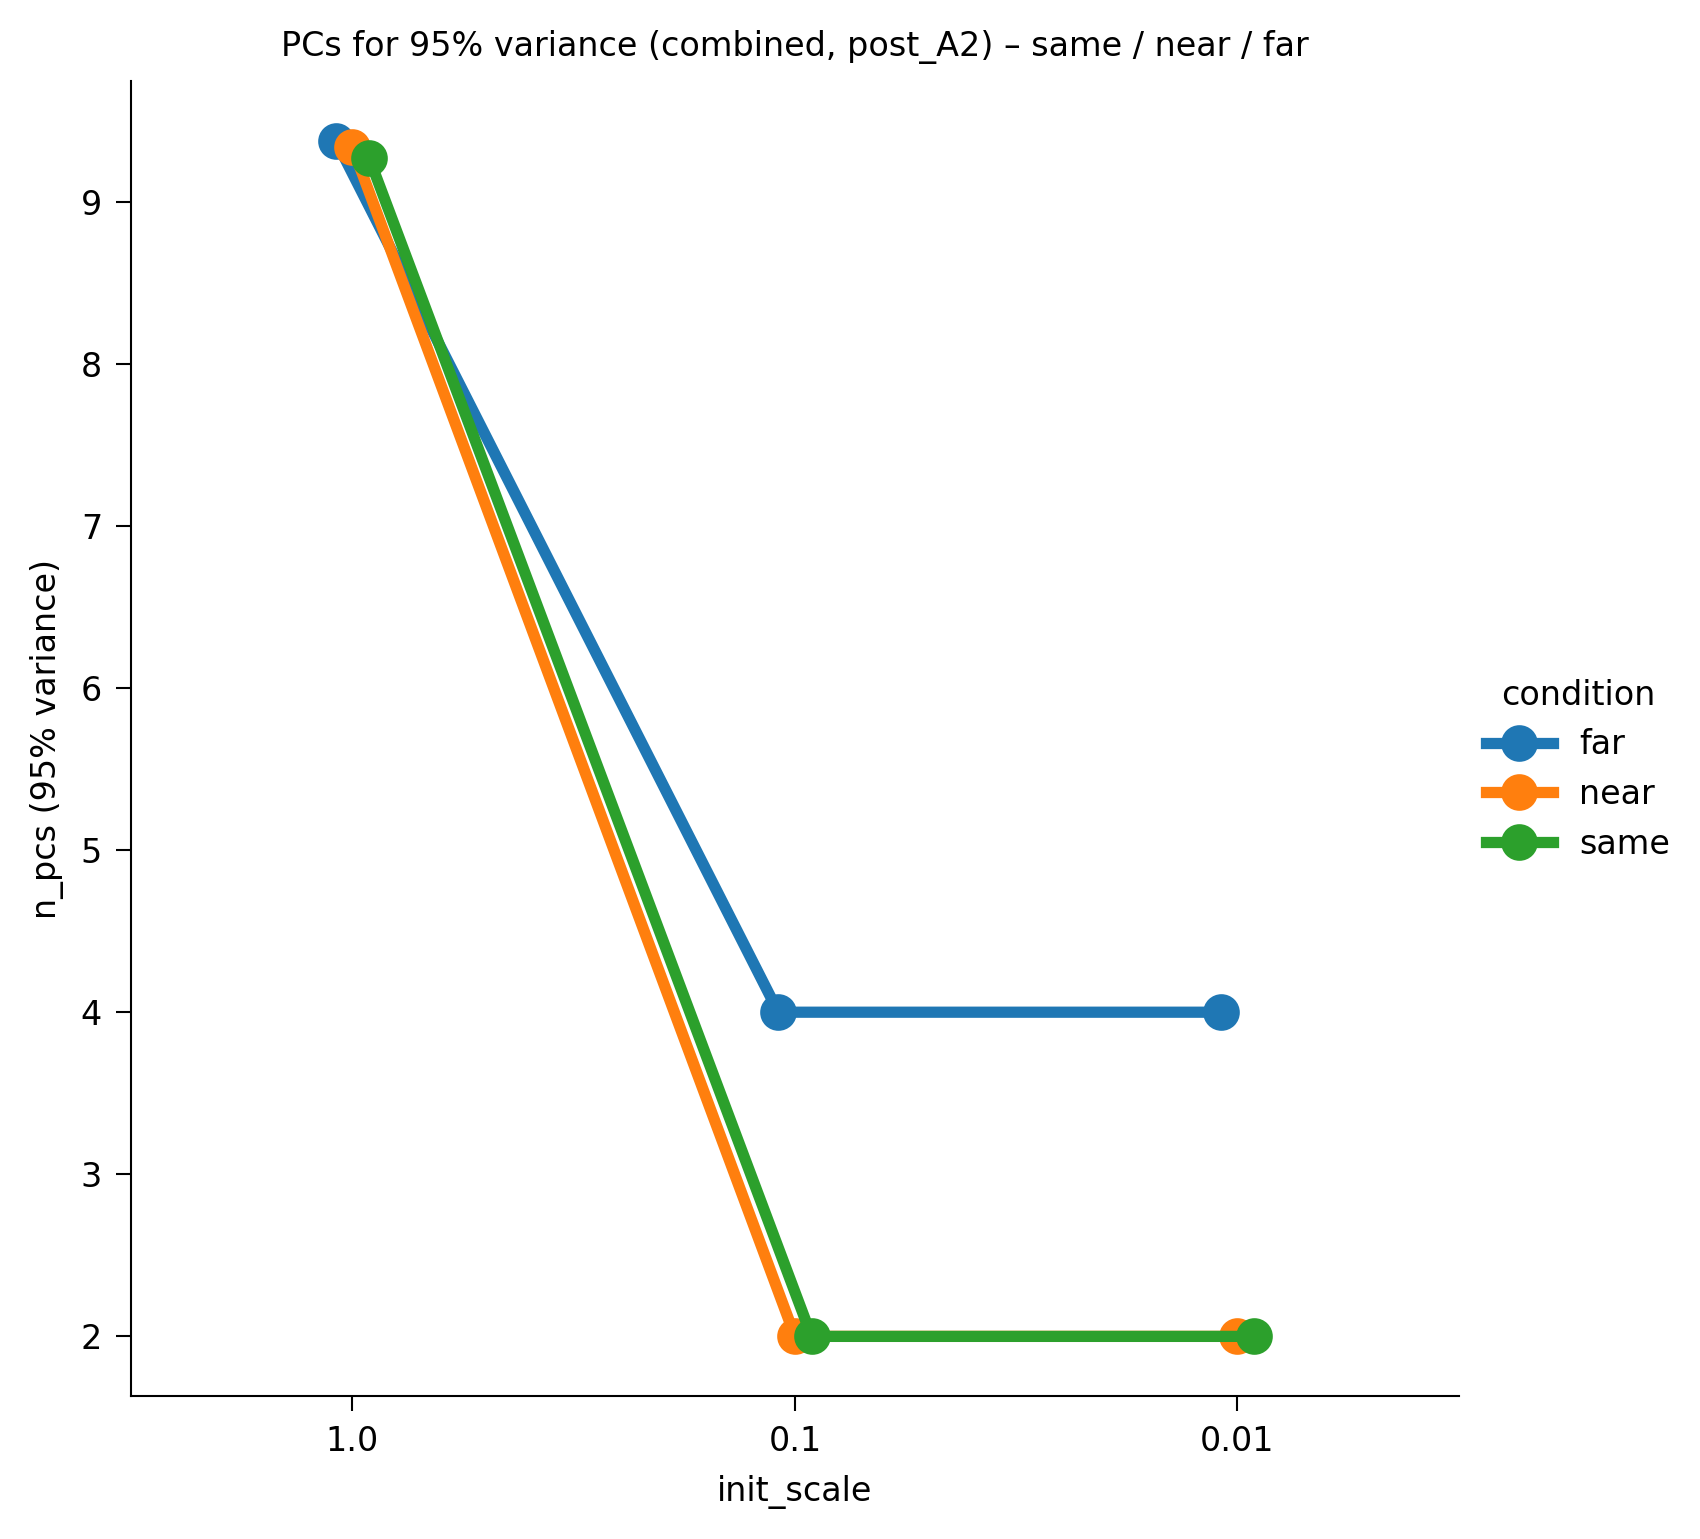

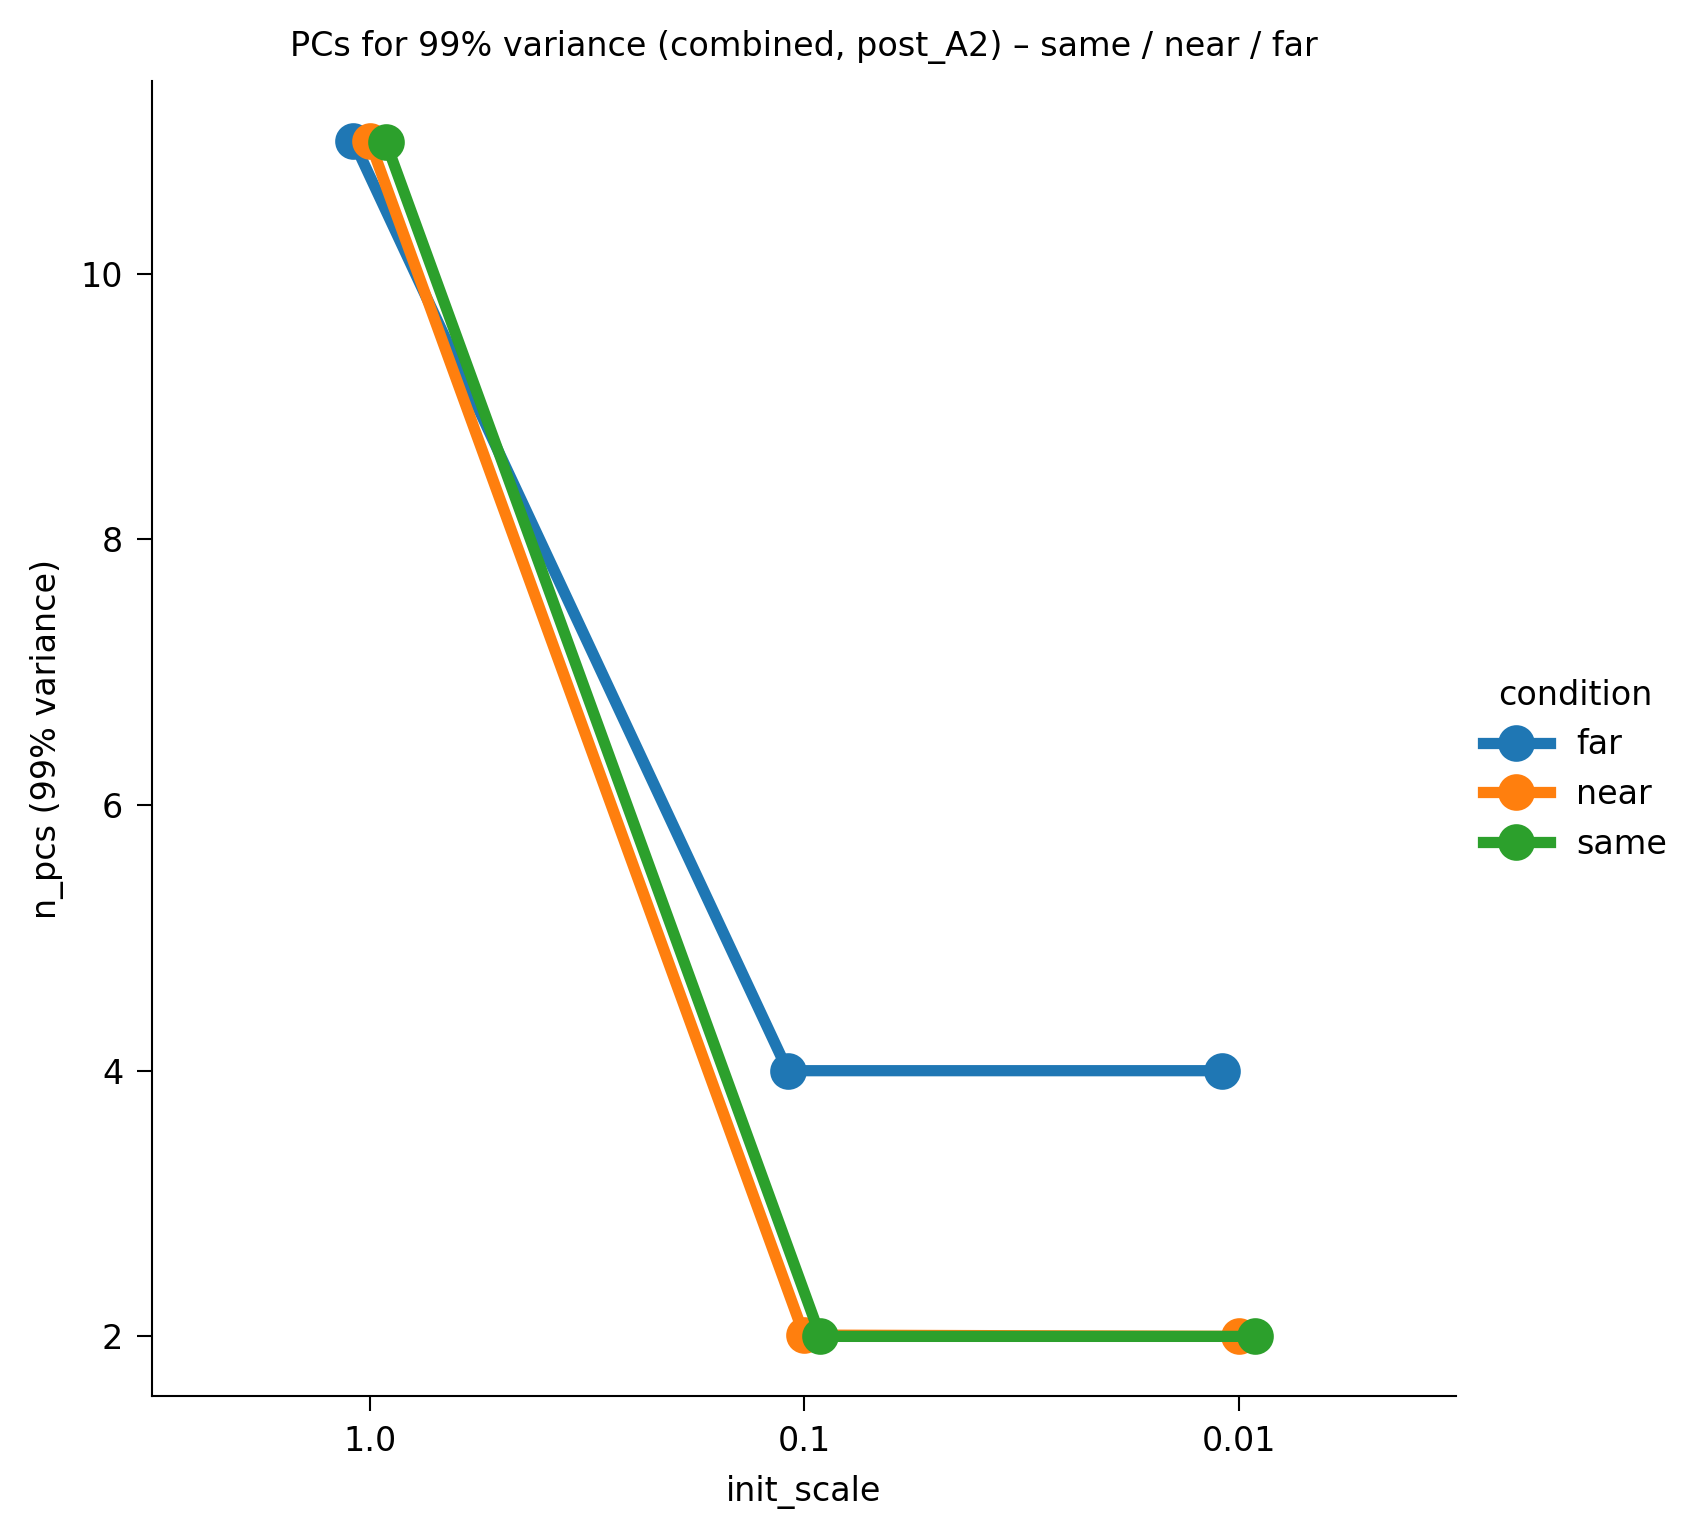

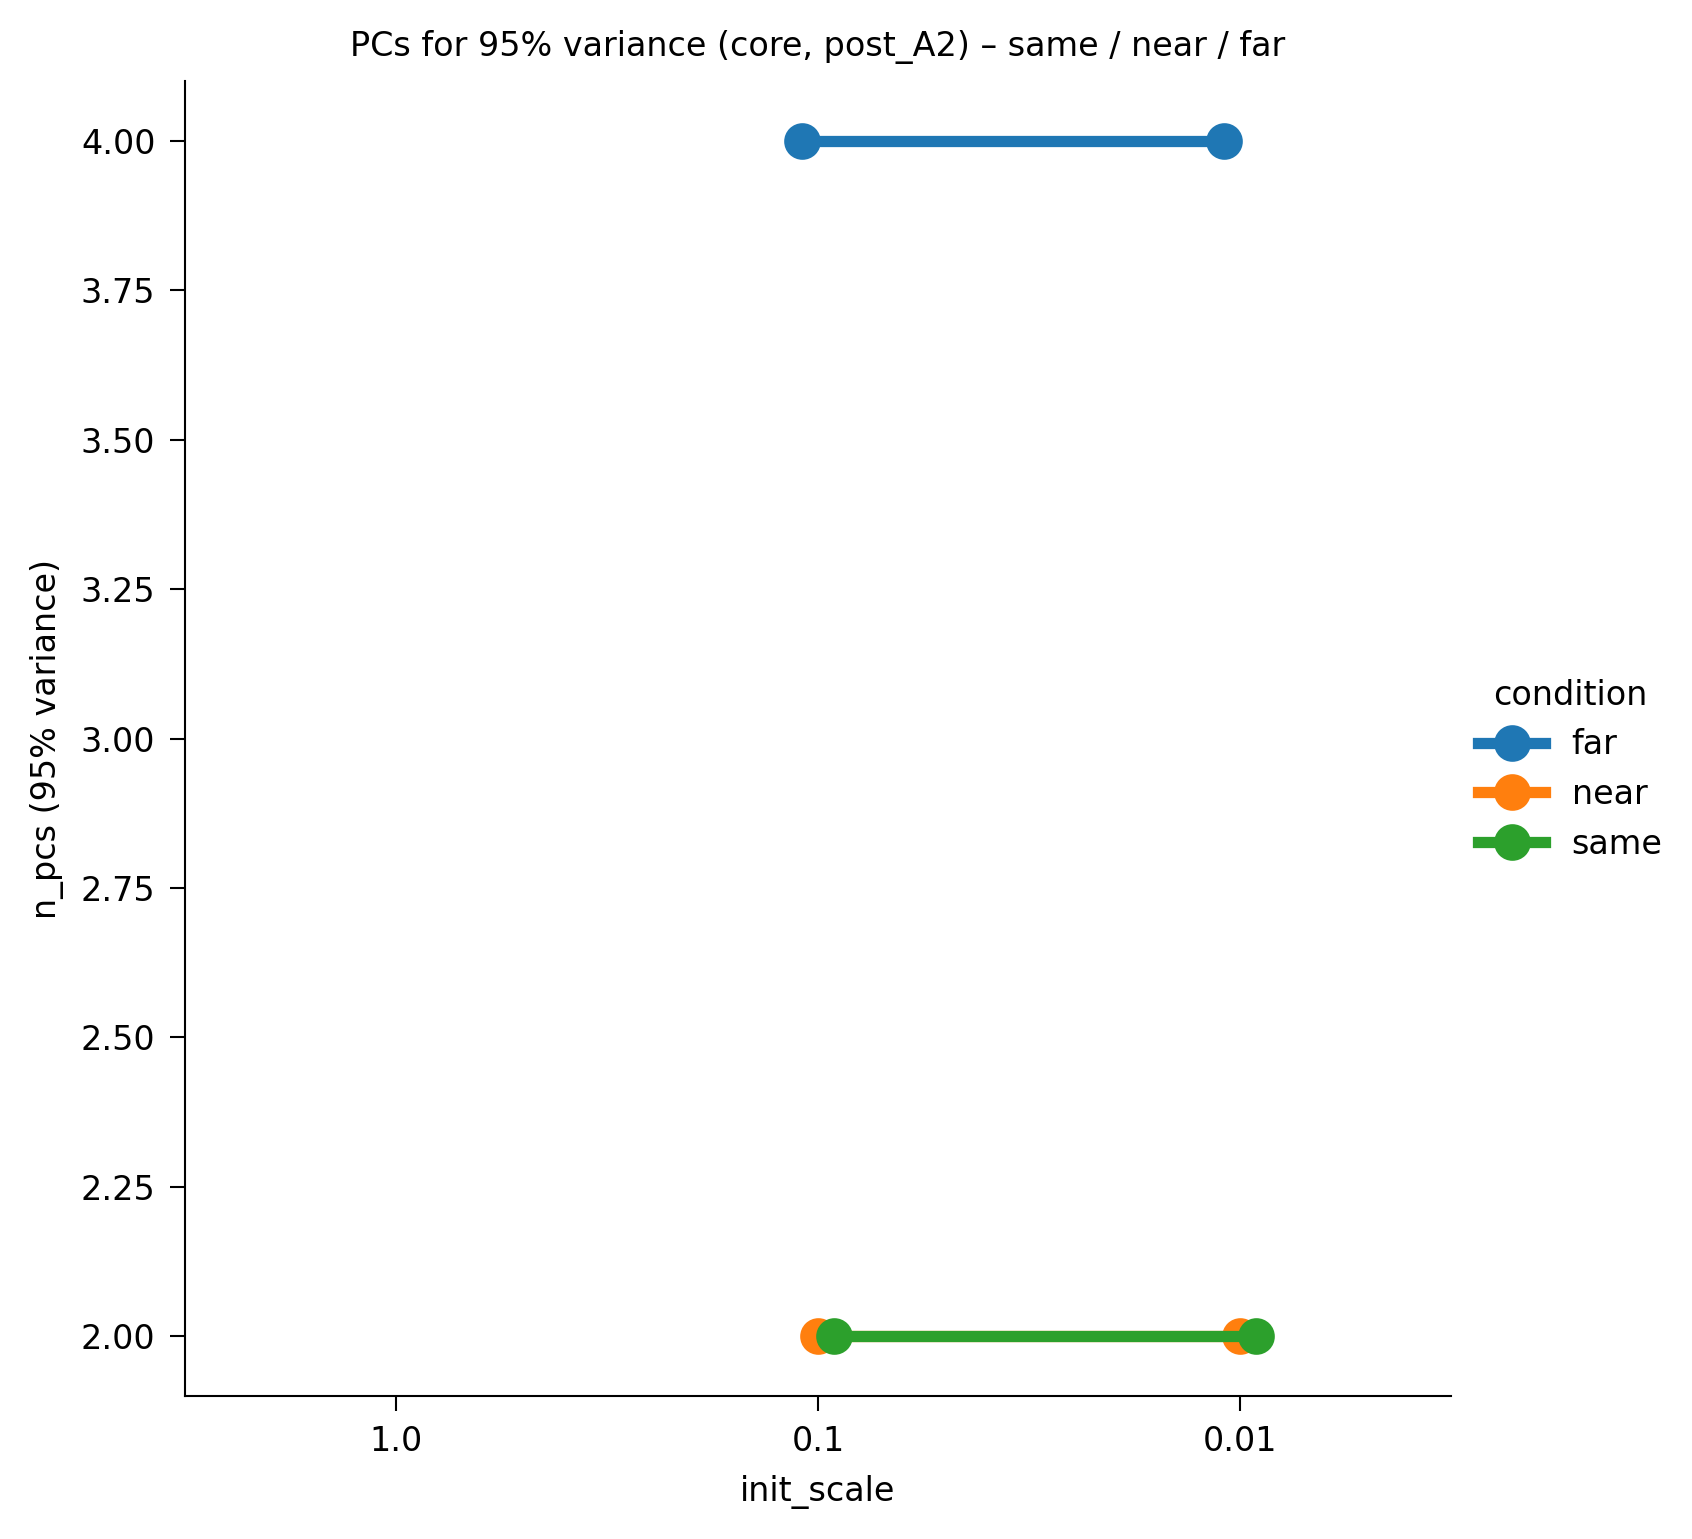

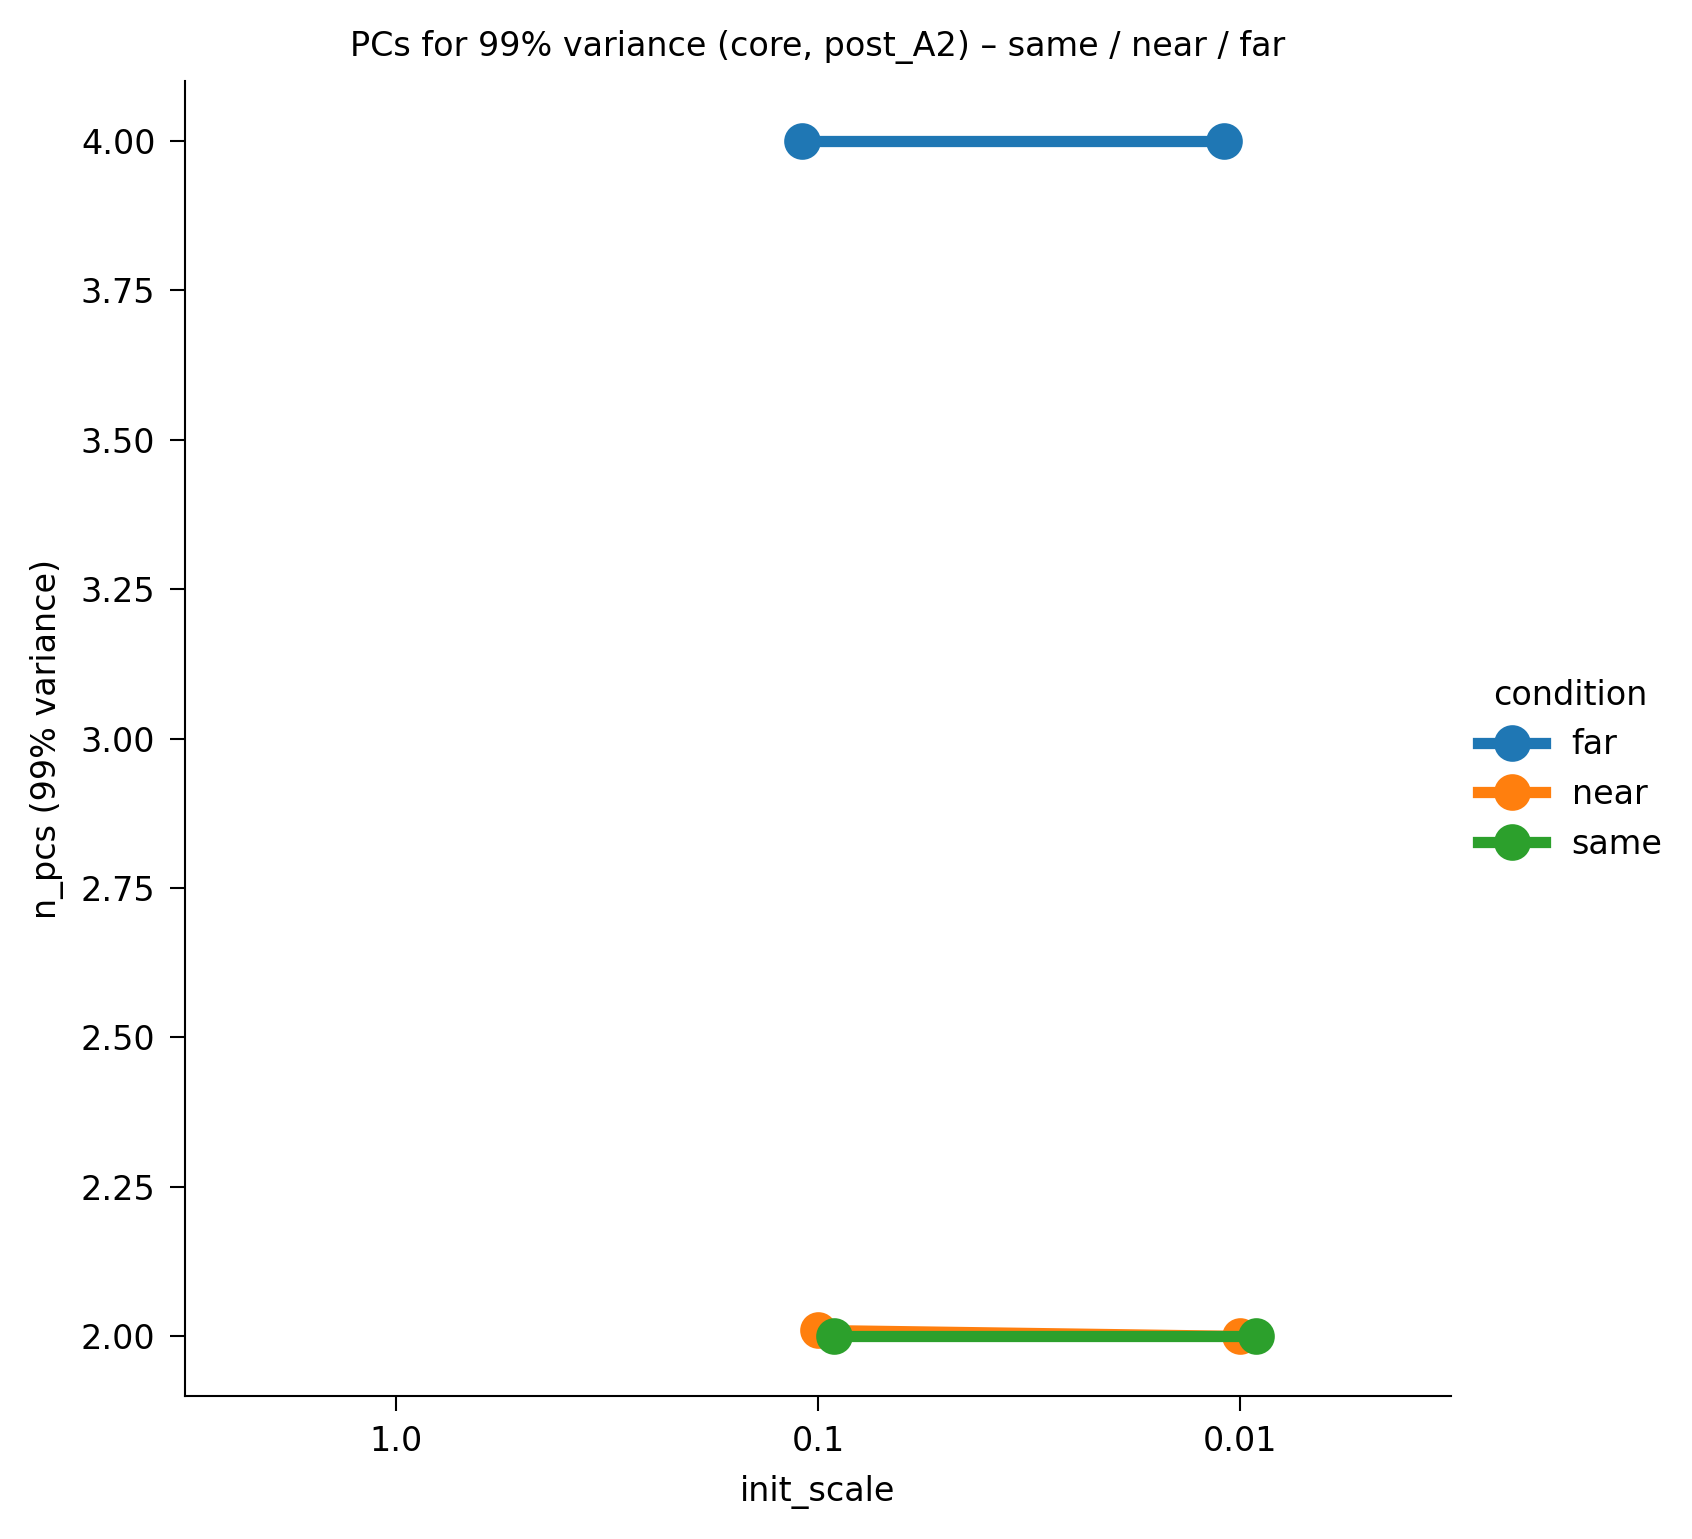

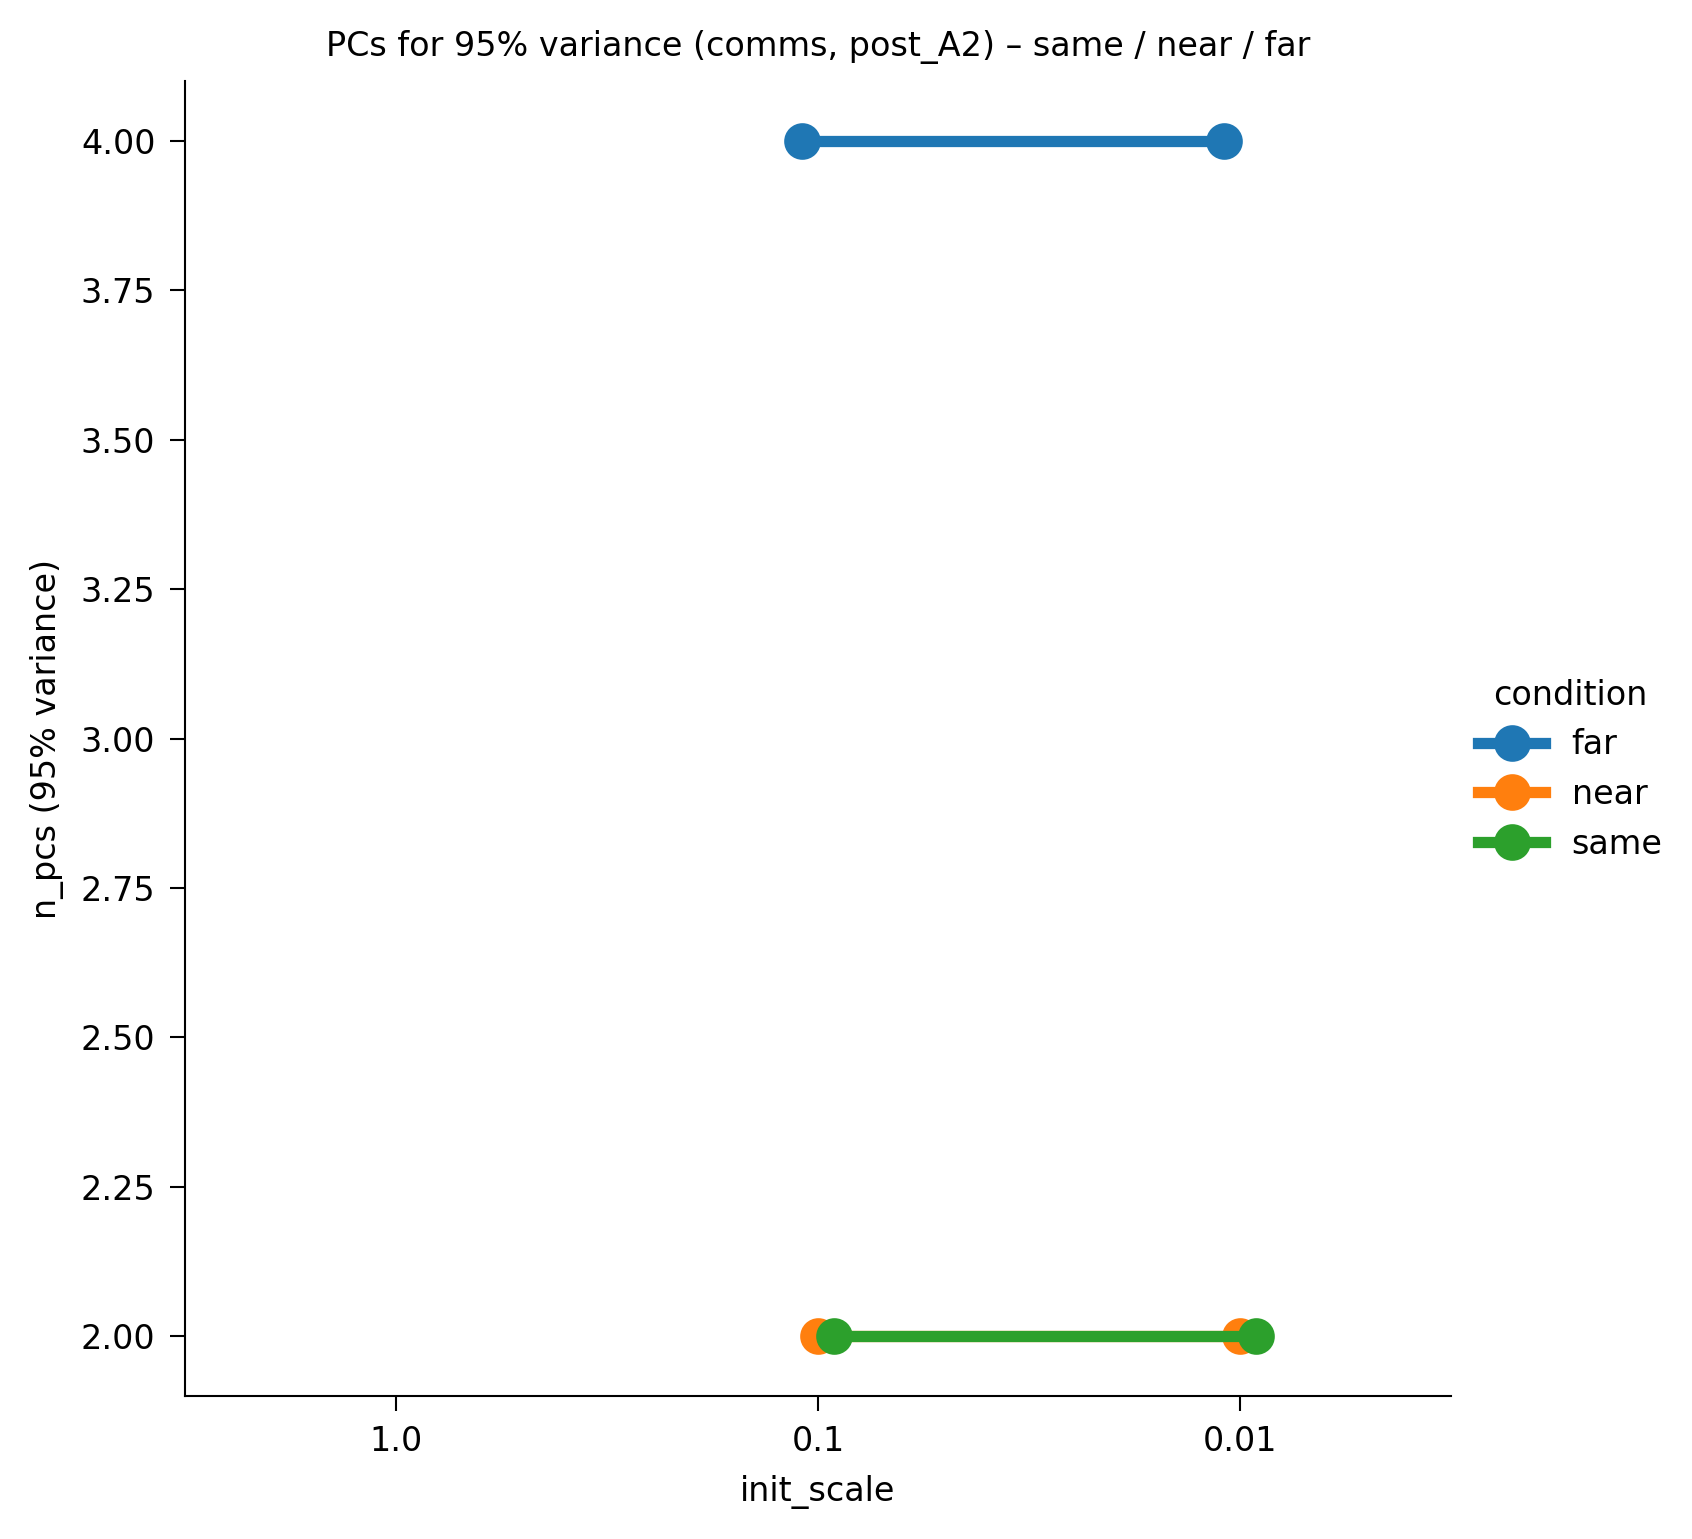

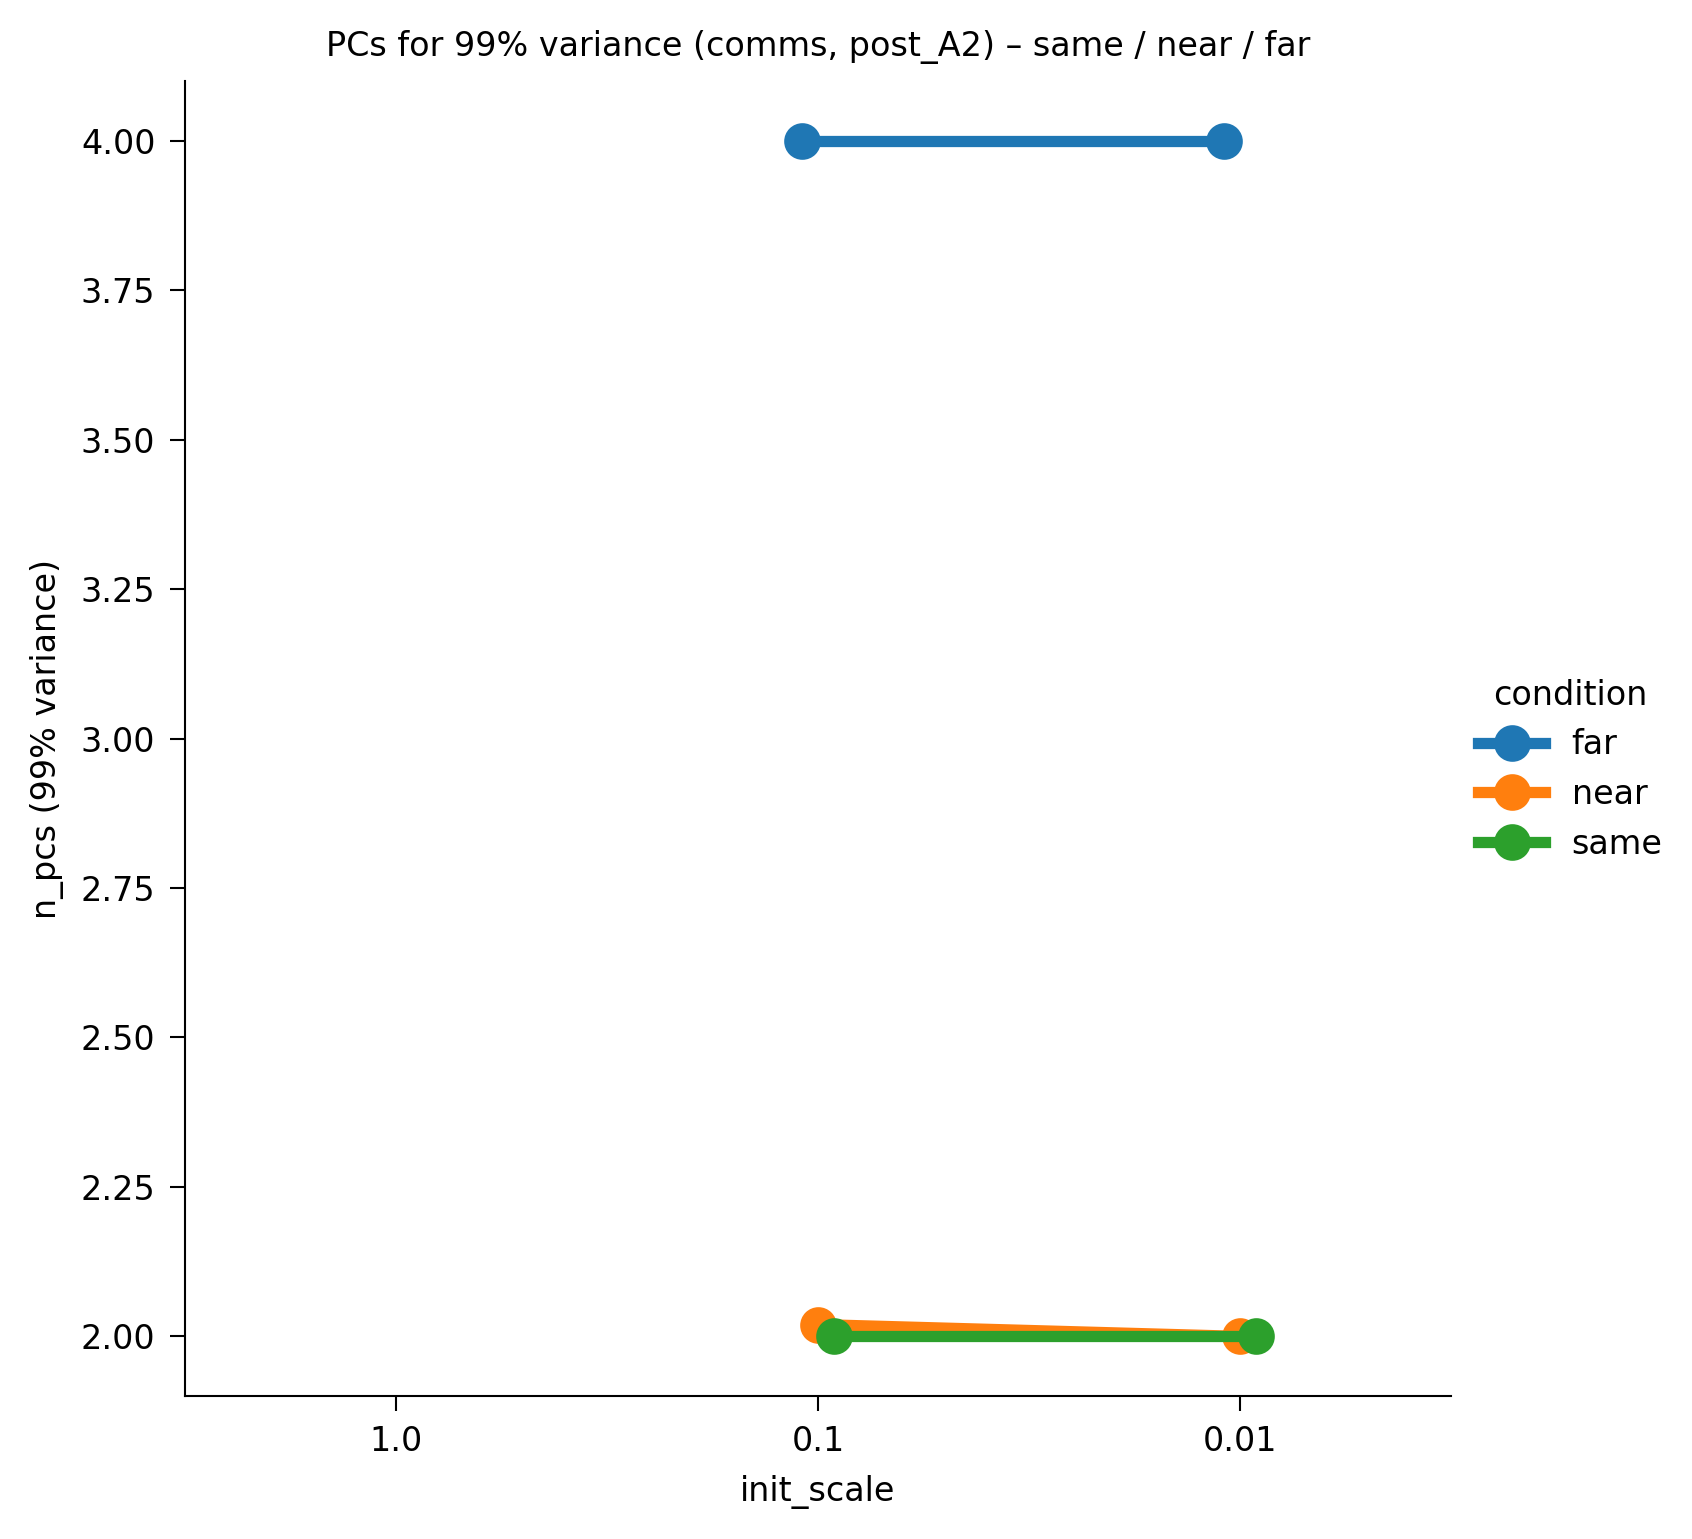

In [7]:
# 6. Visualization: dimensionality vs init_scale, differentiated by same/near/far

if 'rep_summary' in globals() and not rep_summary.empty:
    # Order for init_scale so default (1.0) appears first
    init_scale_order = sorted(rep_summary["init_scale"].dropna().unique(), reverse=True)  # 1.0, 0.1, 0.01

    # Variance in first 2 PCs (combined, post_B) by init_scale and condition
    plot_df = rep_summary[(rep_summary["phase"] == "post_B") & (rep_summary["pathway"] == "combined")]
    if not plot_df.empty:
        sns.catplot(
            data=plot_df,
            x="init_scale",
            y="var_topk",
            hue="condition",
            palette=SIMILARITY_PALETTE,
            kind="point",
            dodge=True,
            order=init_scale_order,
        )
        plt.title("Variance in first 2 PCs (combined, post_B) – same / near / far")
        plt.xlabel("init_scale")
        plt.show()

    # Number of PCs for 95% and 99% variance: by init_scale, hue=condition (same/near/far)
    for phase in ["post_B", "post_A2"]:
        for pathway in ["combined", "core", "comms"]:
            sub = rep_summary[(rep_summary["phase"] == phase) & (rep_summary["pathway"] == pathway)]
            if sub.empty:
                continue
            for y_col, title_suffix in [("n_pcs_95", "95% variance"), ("n_pcs_99", "99% variance")]:
                if y_col not in sub.columns:
                    continue
                sns.catplot(
                    data=sub,
                    x="init_scale",
                    y=y_col,
                    hue="condition",
                    palette=SIMILARITY_PALETTE,
                    kind="point",
                    dodge=True,
                    order=init_scale_order,
                )
                plt.title(f"PCs for {title_suffix} ({pathway}, {phase}) – same / near / far")
                plt.xlabel("init_scale")
                plt.ylabel(f"n_pcs ({title_suffix})")
                plt.show()
else:
    print("rep_summary not available for plotting.")


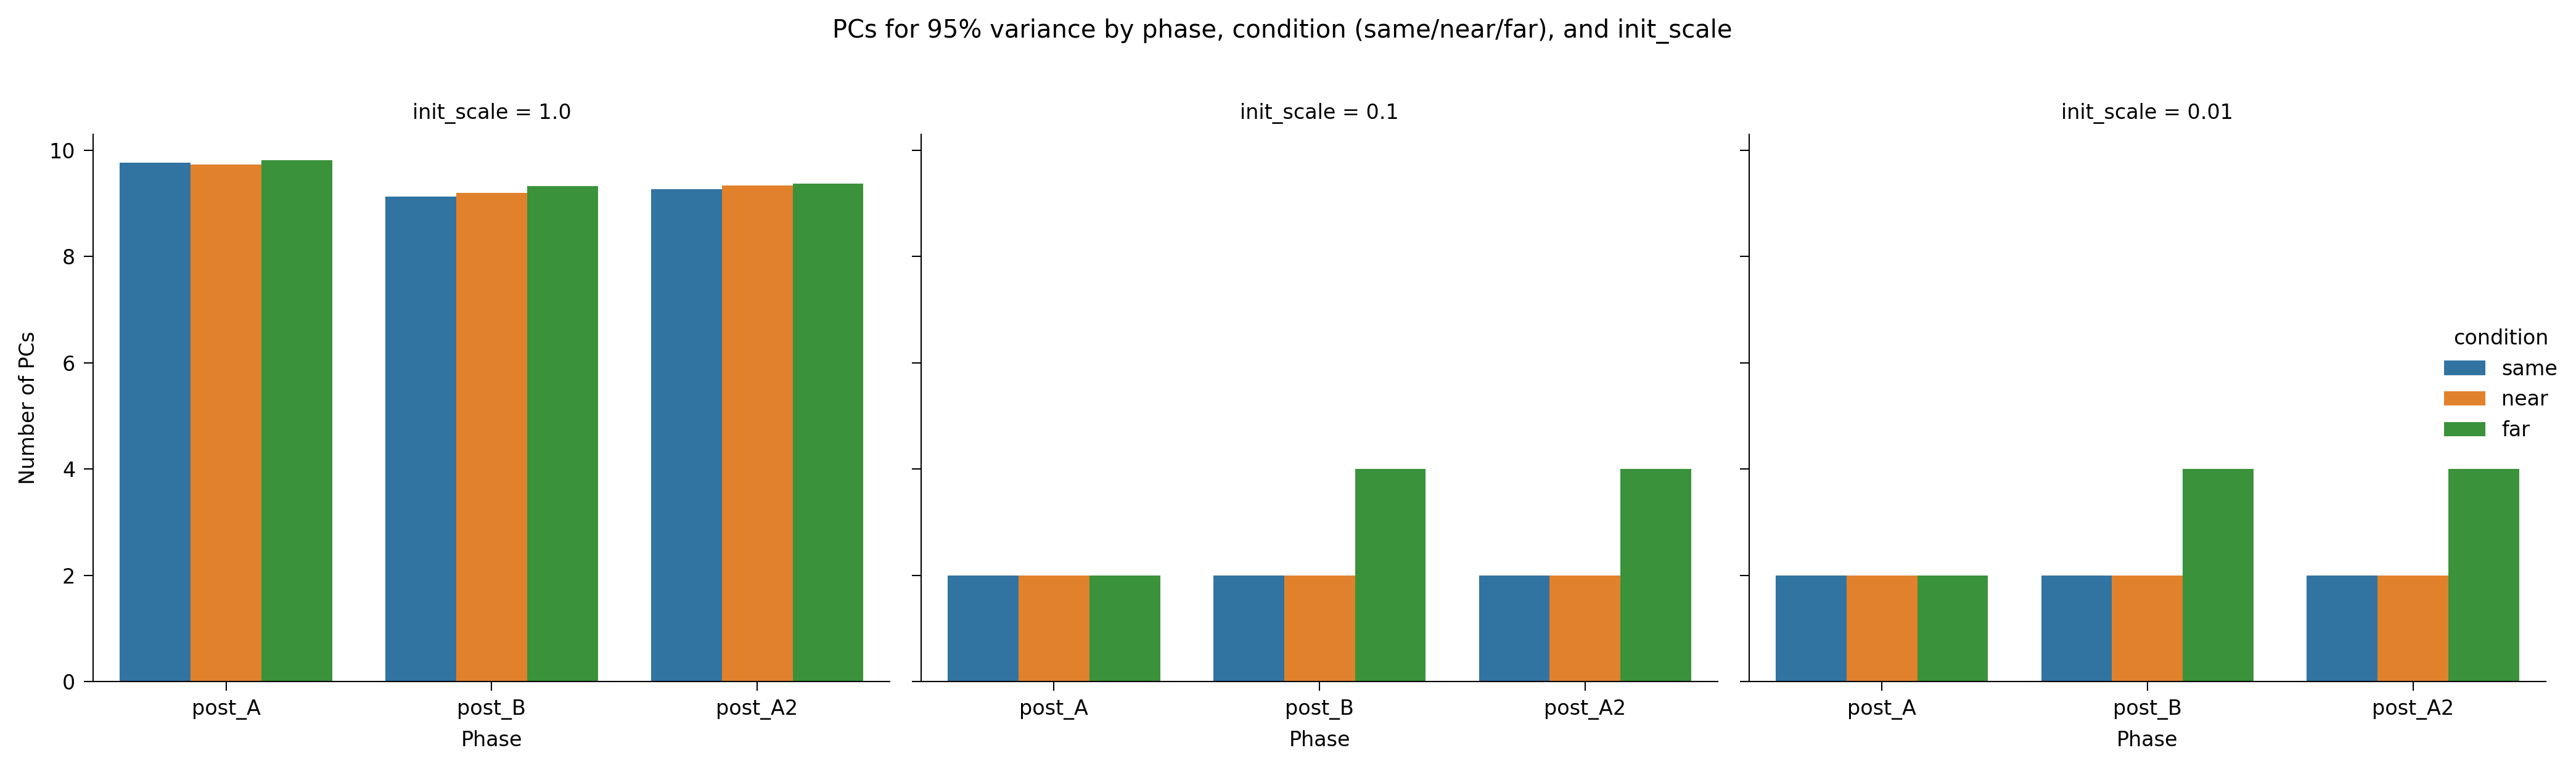

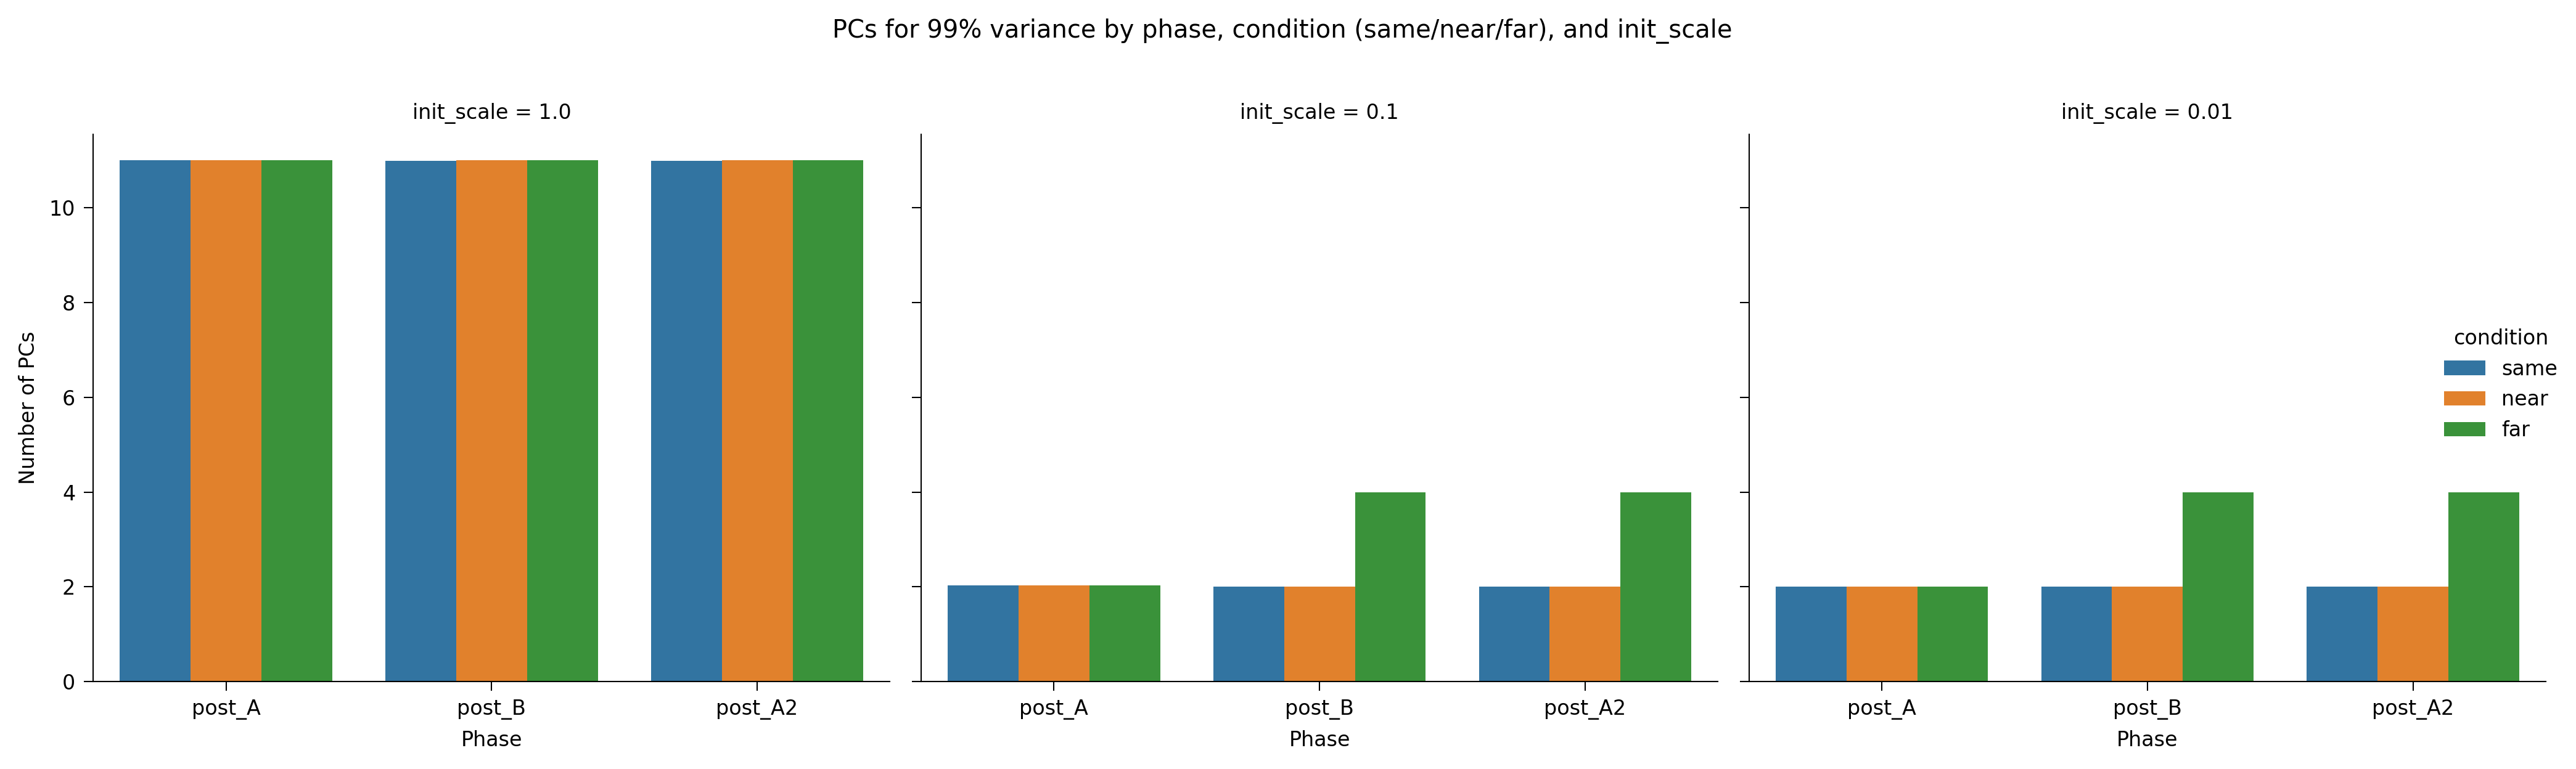

In [8]:
# 6a. Direct comparison: number of PCs (histogram/bar) for every condition and init_scale, all three phases

if 'rep_summary' in globals() and not rep_summary.empty:
    comp = rep_summary[rep_summary["pathway"] == "combined"].copy()
    col_order = sorted(comp["init_scale"].dropna().unique(), reverse=True)  # 1.0, 0.1, 0.01

    for y_col, title in [("n_pcs_95", "PCs for 95% variance"), ("n_pcs_99", "PCs for 99% variance")]:
        if y_col not in comp.columns:
            continue
        g = sns.catplot(
            data=comp,
            x="phase",
            y=y_col,
            hue="condition",
            palette=SIMILARITY_PALETTE,
            col="init_scale",
            col_order=col_order,
            kind="bar",
            dodge=True,
            height=4,
            aspect=1.1,
            order=["post_A", "post_B", "post_A2"],
            hue_order=["same", "near", "far"],
        )
        g.set_axis_labels("Phase", "Number of PCs")
        g.set_titles("init_scale = {col_name}")
        g.fig.suptitle(f"{title} by phase, condition (same/near/far), and init_scale", y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print("rep_summary not available.")

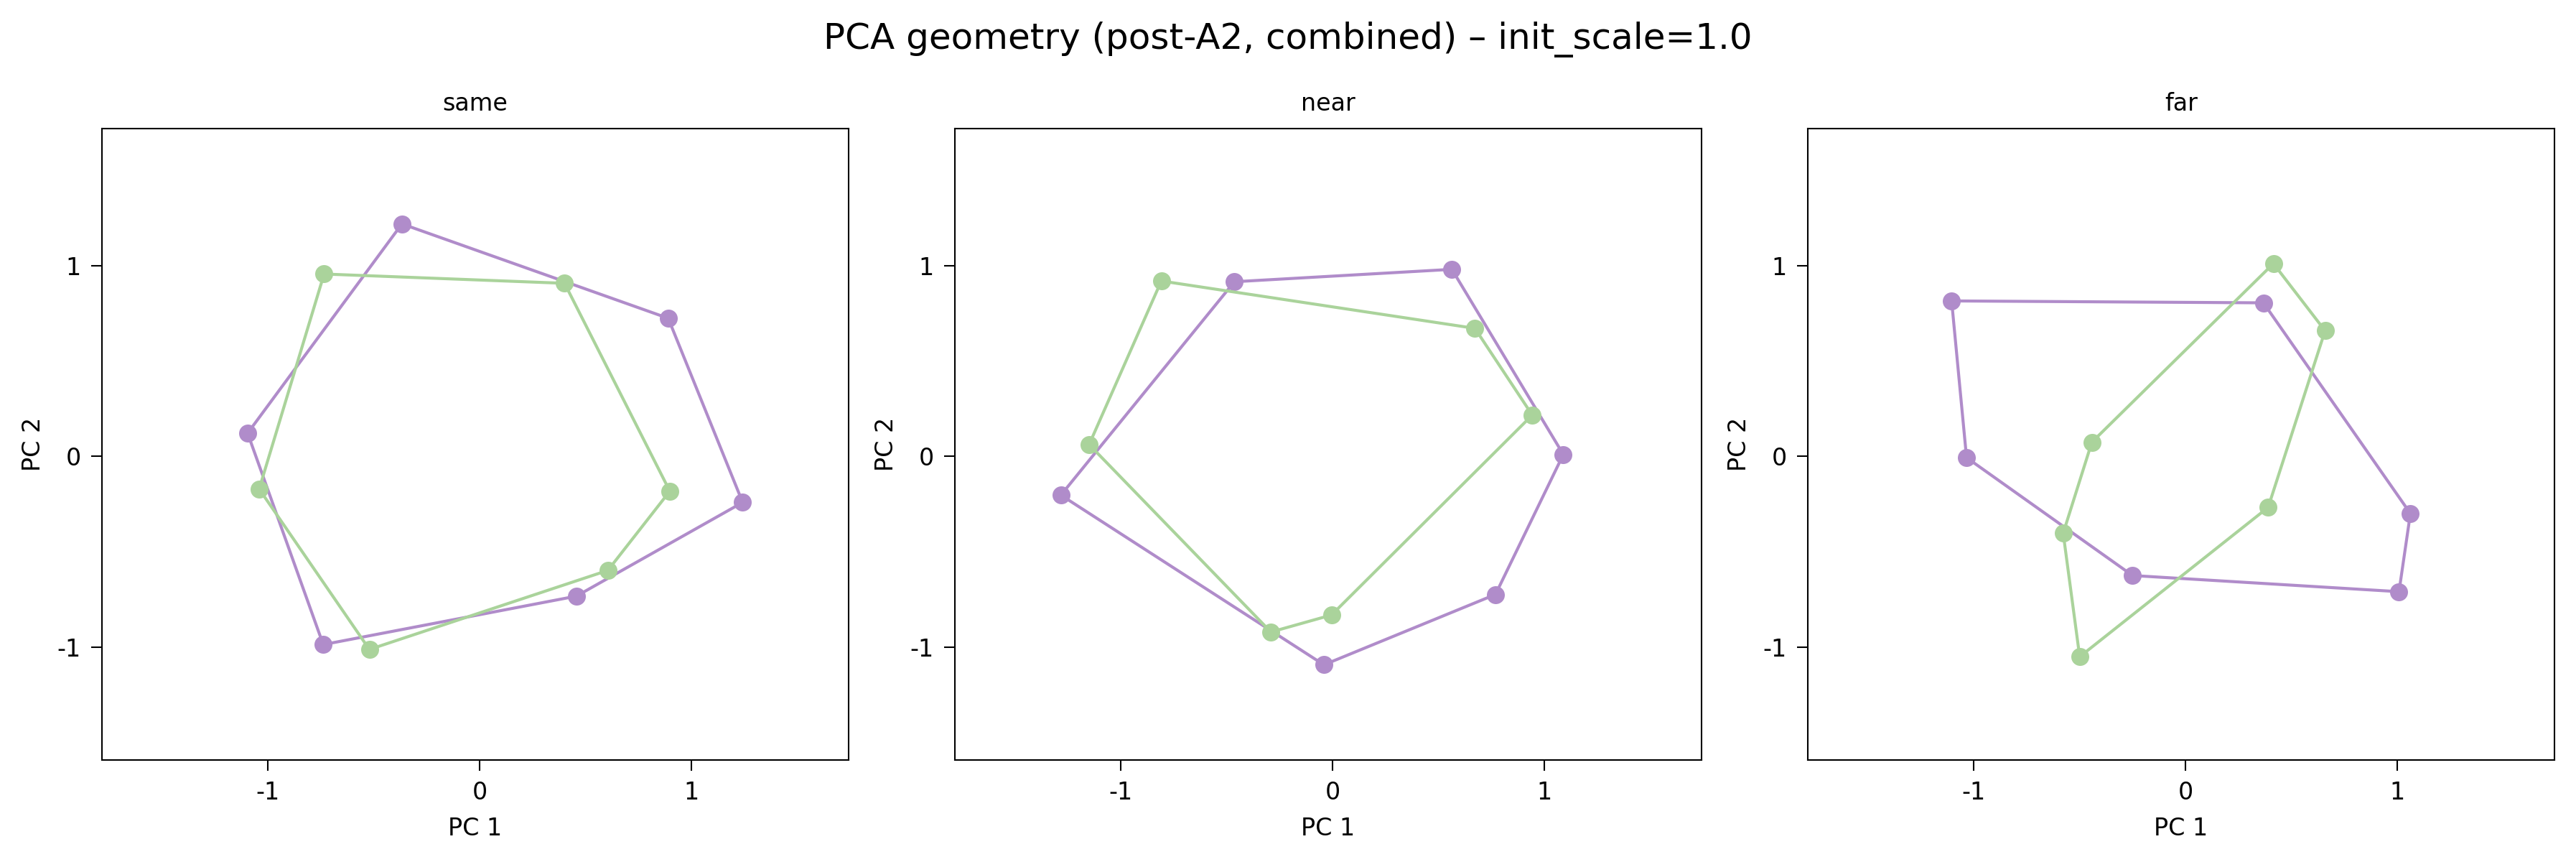

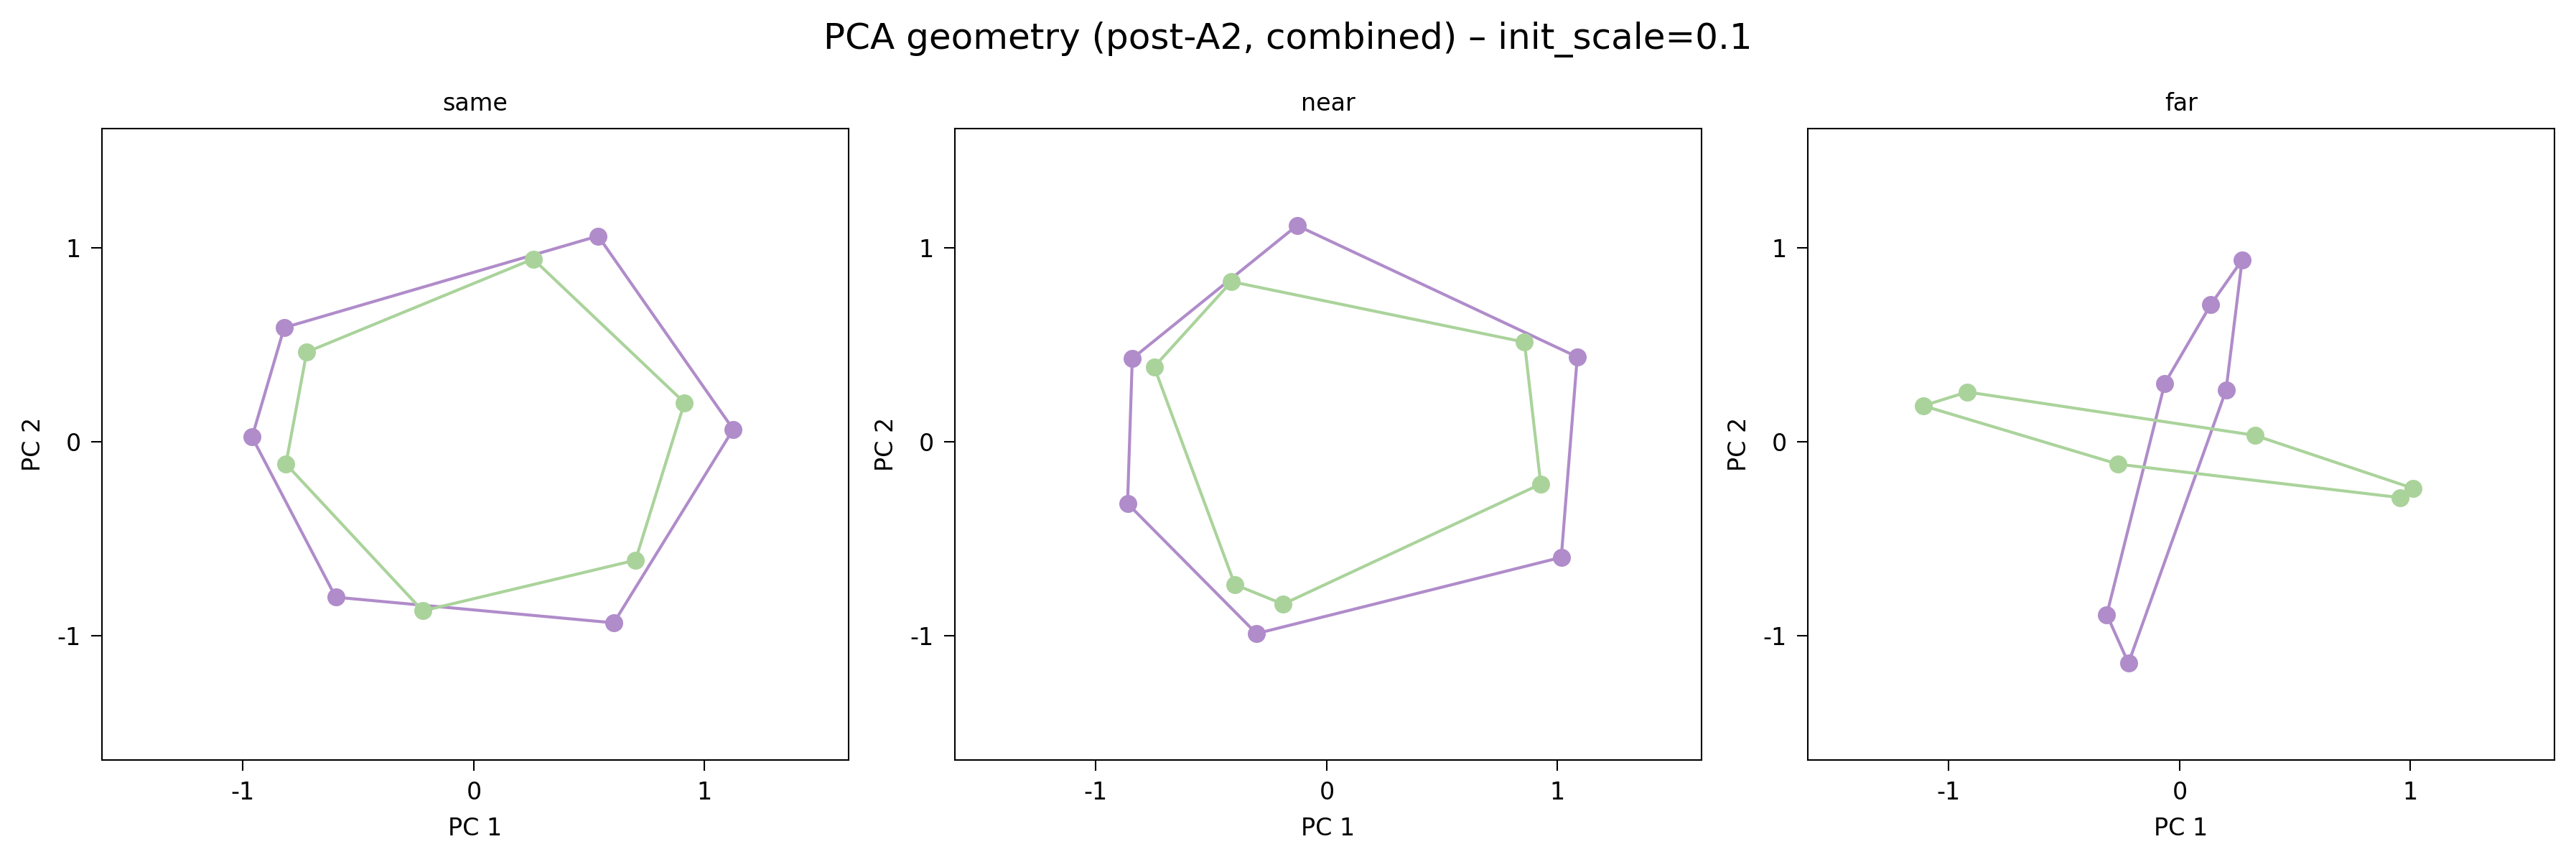

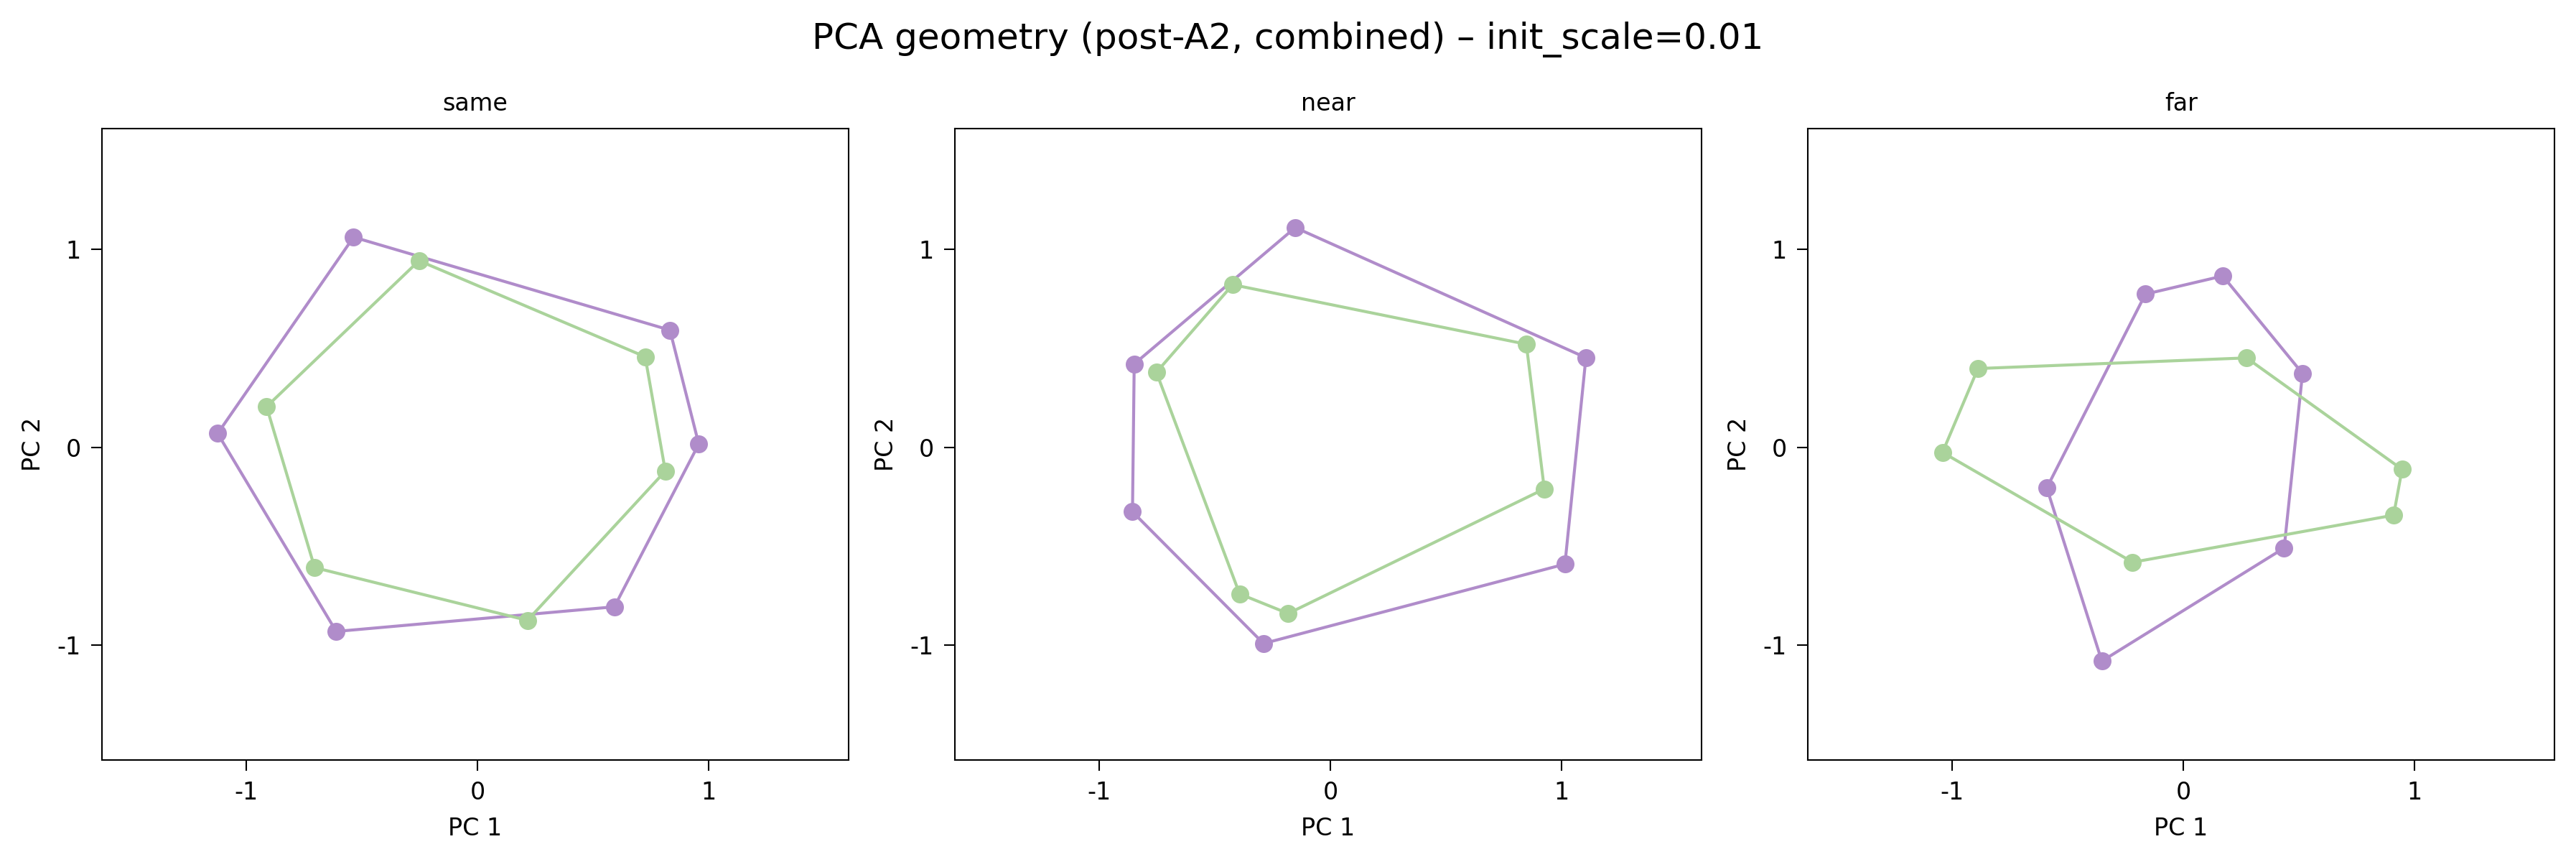

In [9]:
# 6b. PCA geometry (2D): same / near / far per init_scale

# One figure per init_scale: 3 panels (same, near, far), each = 2D PCA of post-A2 combined hiddens
phase_idx = 2  # post-A2
n_stim_plot = 12  # first 12 stimuli (6 A + 6 B) for geometry

for run_id in run_labels:
    bundle = all_ann_data[run_id]
    init_scale = bundle["init_scale"]
    ann_data = bundle["data"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"PCA geometry (post-A2, combined) – init_scale={init_scale}", fontsize=12)

    all_2d = []
    for cond in ["same", "near", "far"]:
        entries = ann_data.get(cond, [])
        if not entries:
            all_2d.append(None)
            continue
        entry = entries[0]
        hids = np.asarray(entry.get(f"hiddens_post_phase_{phase_idx}"))
        if hids is None or hids.size == 0 or hids.shape[0] < n_stim_plot:
            all_2d.append(None)
            continue
        hids = hids[:n_stim_plot]
        _, X2 = prepare_pca_single_task(hids)
        all_2d.append(X2)

    valid = [x for x in all_2d if x is not None]
    lims_global = get_axis_limits(np.vstack(valid)) if valid else {}

    for ax, cond, X2 in zip(axes, ["same", "near", "far"], all_2d):
        if X2 is None:
            ax.set_title(f"{cond}\n(no data)")
            ax.axis("off")
            continue
        plot_split_stim(ax, X2, task_colours, lims_global)
        ax.set_title(cond)
    plt.tight_layout()
    plt.show()

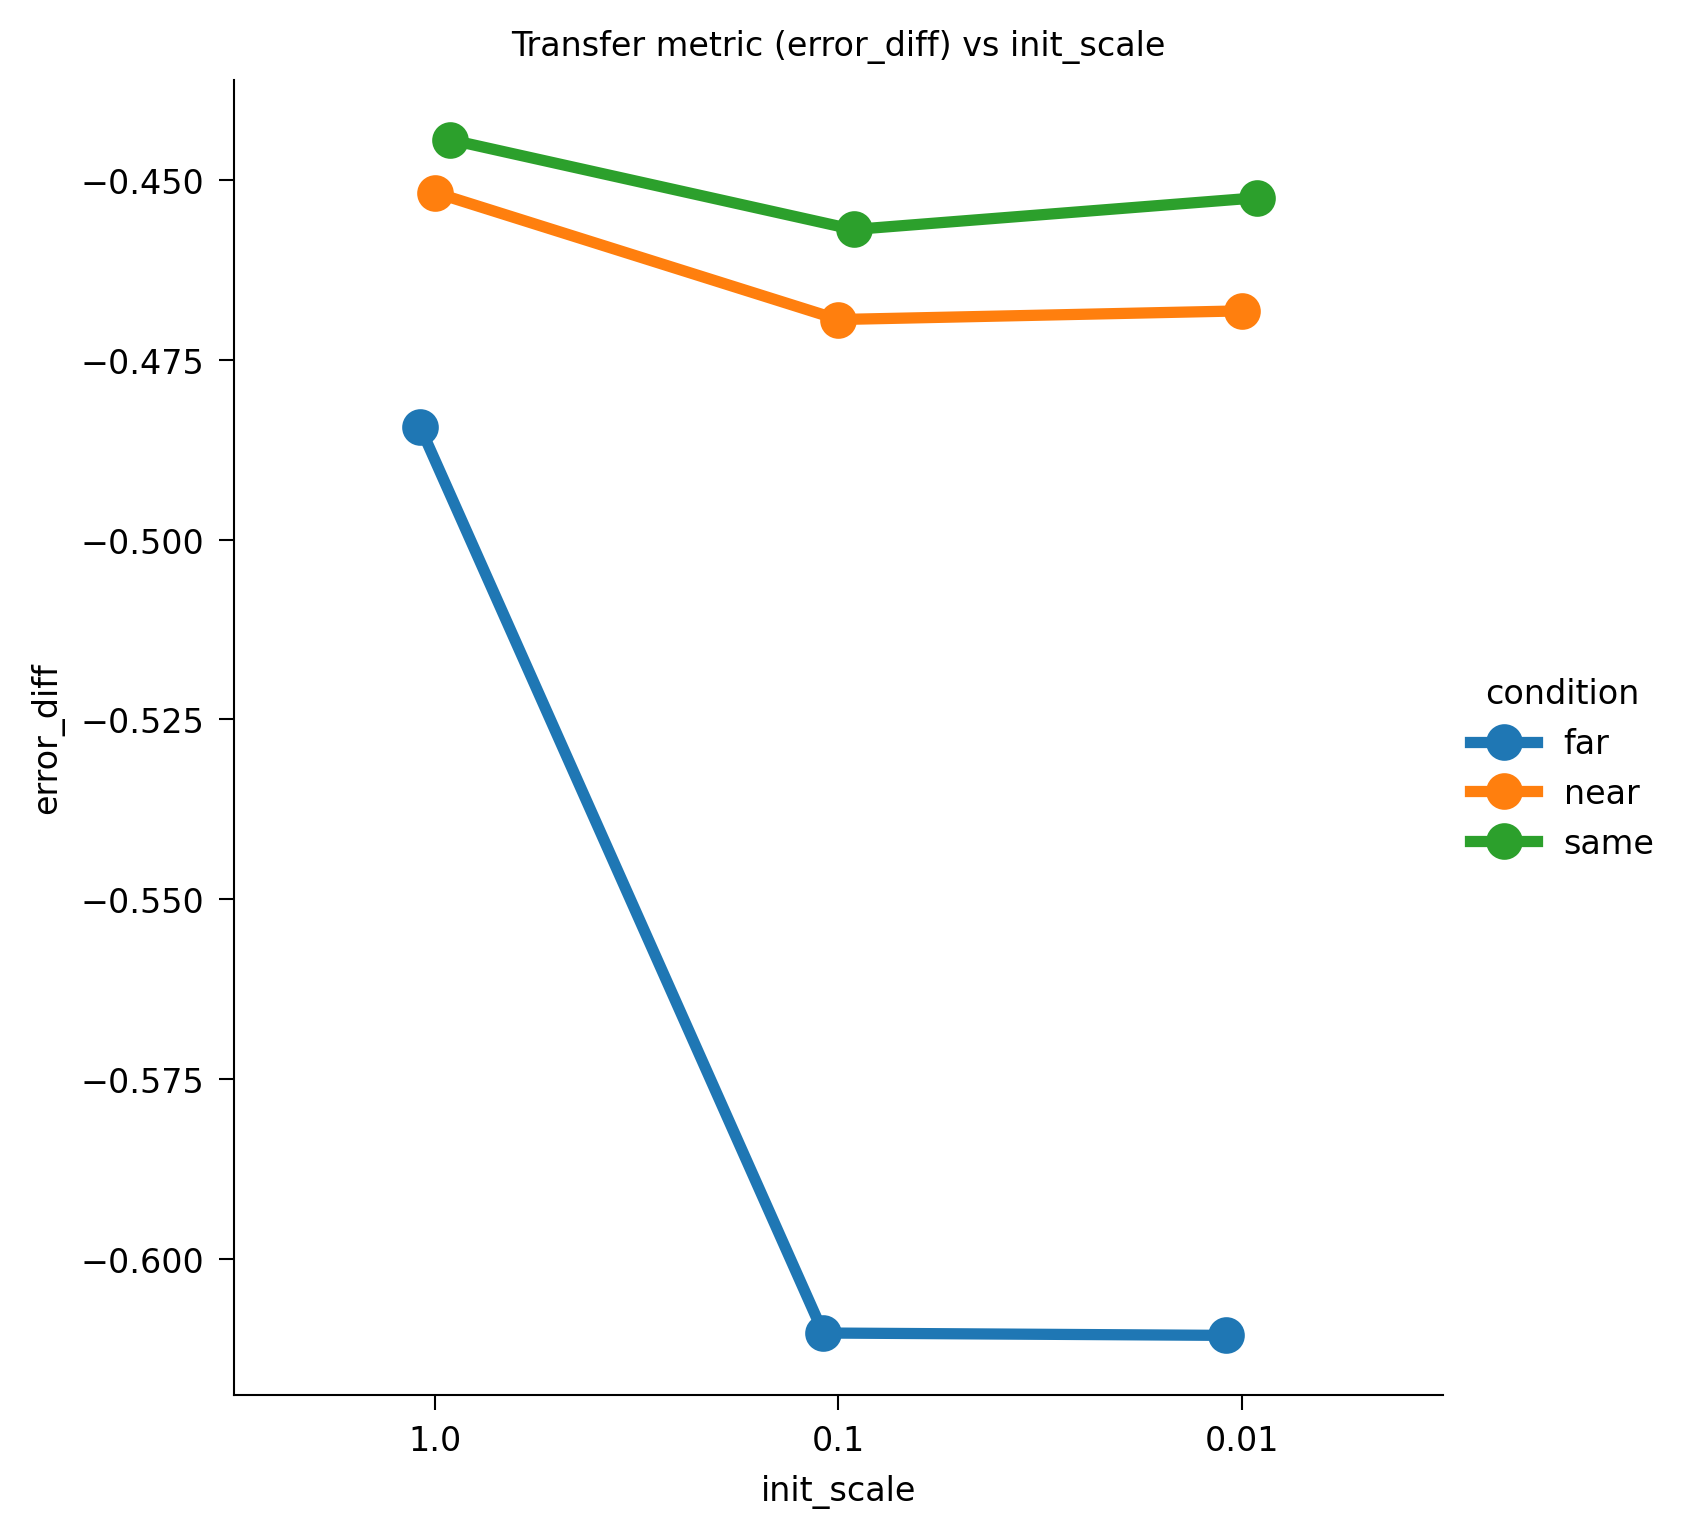

In [10]:
# 7. Visualization: transfer and drift vs init_scale

transfer_order = sorted(transfer_summary["init_scale"].dropna().unique(), reverse=True) if 'transfer_summary' in globals() and not transfer_summary.empty else []
drift_order = sorted(drift_summary["init_scale"].dropna().unique(), reverse=True) if 'drift_summary' in globals() and not drift_summary.empty else []

if 'transfer_summary' in globals() and not transfer_summary.empty:
    sns.catplot(
        data=transfer_summary,
        x="init_scale",
        y="error_diff",
        hue="condition",
        palette=SIMILARITY_PALETTE,
        kind="point",
        dodge=True,
        order=transfer_order,
    )
    plt.xlabel("init_scale")
    plt.title("Transfer metric (error_diff) vs init_scale")
    plt.show()

if 'drift_summary' in globals() and not drift_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    sns.pointplot(data=drift_summary, x="init_scale", y="drift_preA", hue="condition", palette=SIMILARITY_PALETTE, ax=axes[0], dodge=True, order=drift_order)
    sns.pointplot(data=drift_summary, x="init_scale", y="drift_preA", palette=SIMILARITY_PALETTE,
    axes[0].set_title("Drift pre→A1 vs init_scale")
    axes[0].set_xlabel("init_scale")
    sns.pointplot(data=drift_summary, x="init_scale", y="drift_AB", hue="condition", palette=SIMILARITY_PALETTE, ax=axes[1], dodge=True, order=drift_order)
    sns.pointplot(data=drift_summary, x="init_scale", y="drift_AB", palette=SIMILARITY_PALETTE,
    axes[1].set_title("Drift A1→B vs init_scale")
    axes[1].set_xlabel("init_scale")
    plt.tight_layout()
    plt.show()


## 8. Interpretation notes

Use the summary tables and plots above to answer:

- For which similarity conditions (same/near/far) and pathways (combined/core/comms) does smaller `init_scale`:
  - Increase or decrease `drift_preA` and `drift_AB`?
  - Shift `var_topk`, `n_pcs_95 / n_pcs_99`, or `pr` (state dimensionality)?
  - Improve or worsen `error_diff` (transfer behaviour)?
- Do changes in dimensionality co-vary with changes in transfer, and is this relationship different across similarity levels?
- Are the effects strongest in `comms` (consistent with communication leveraging low-dimensional structure), or elsewhere?


## Appendix: PCA geometry (PC3 vs PC4)

For configurations that have **more than 2 PCs** (95% variance criterion, combined pathway, post-A2), we plot the **third and fourth** principal components in the same layout as the main geometry (same / near / far panels).

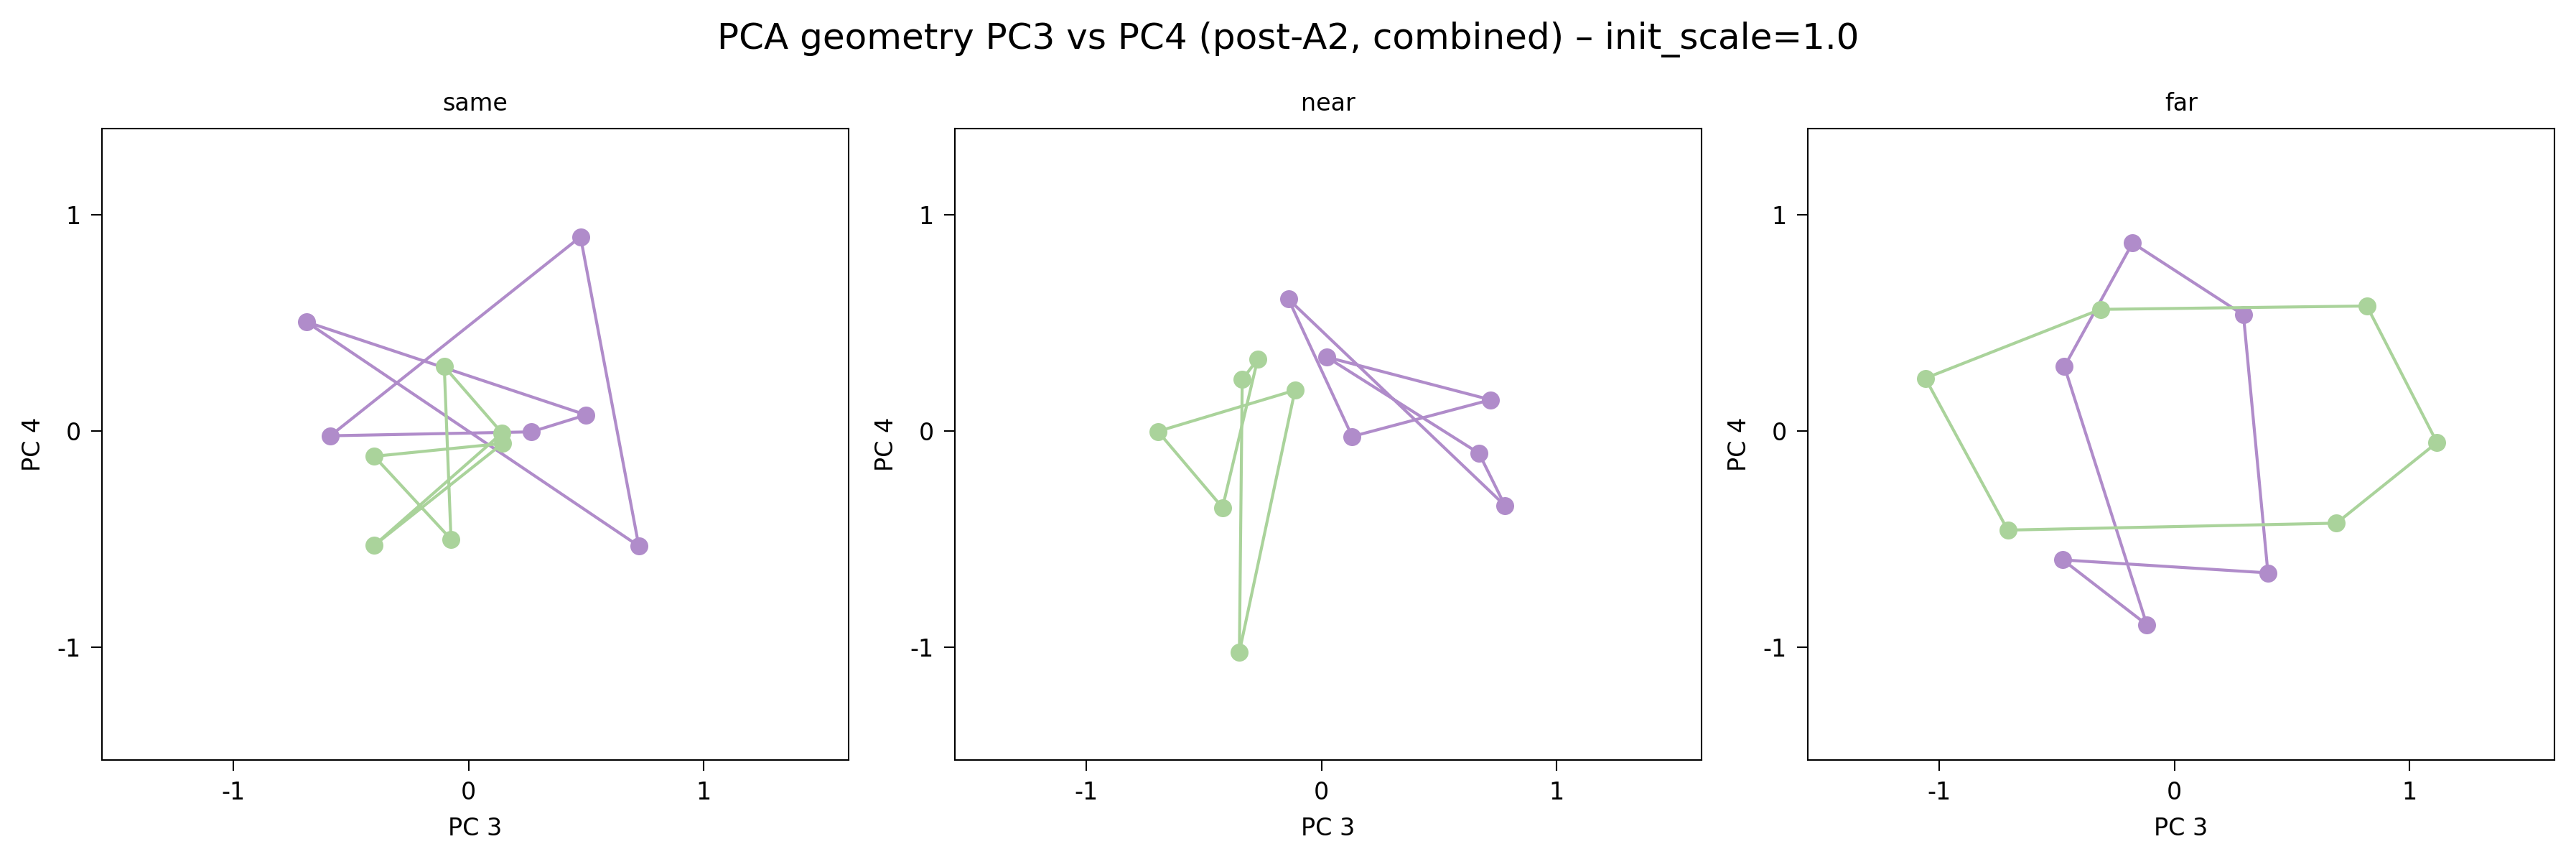

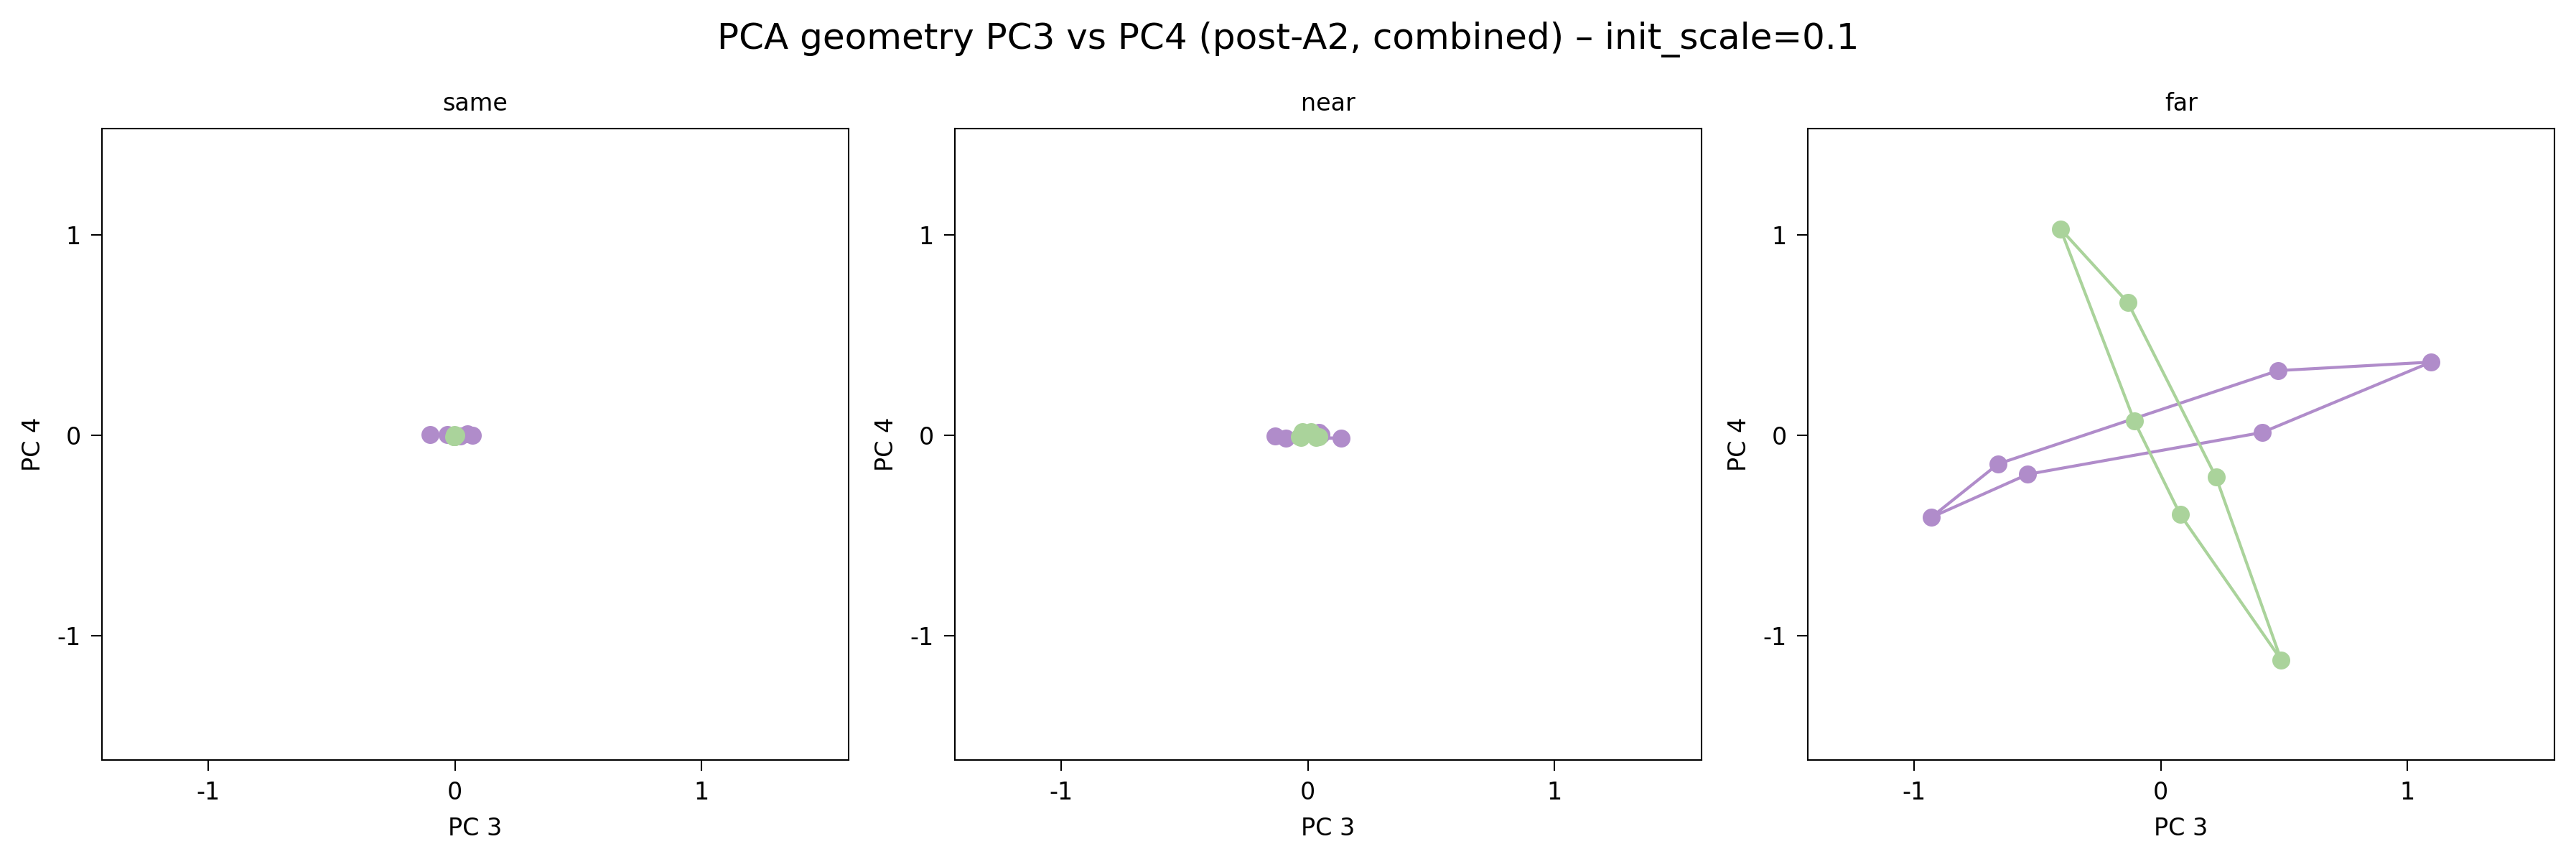

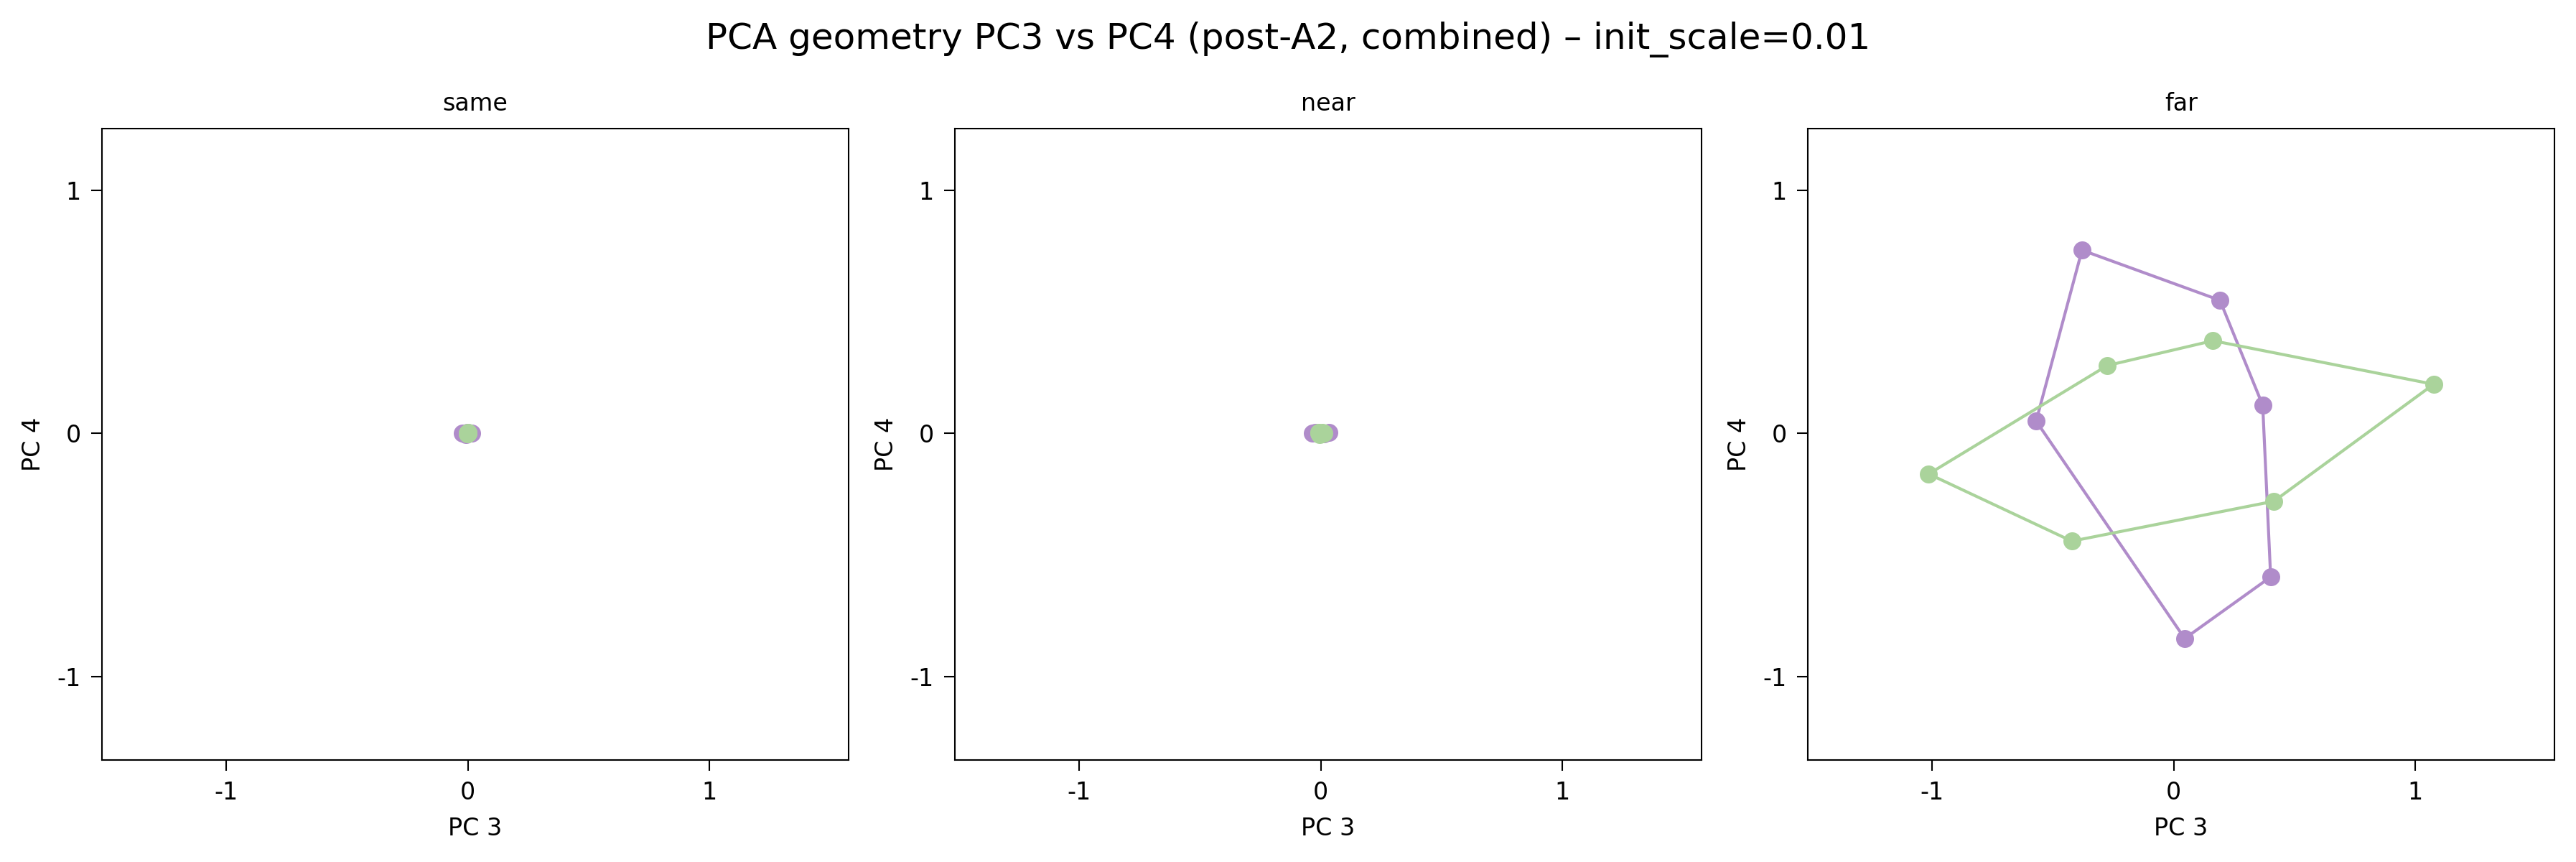

In [11]:
# Appendix: PC3 vs PC4 for configs with > 2 PCs (95% variance, combined, post-A2)

from sklearn.decomposition import PCA

phase_idx = 2  # post-A2
n_stim_plot = 12

# Runs that have > 2 PCs for at least one condition (combined, post_A2)
if 'rep_summary' in globals() and not rep_summary.empty:
    sub = rep_summary[(rep_summary["phase"] == "post_A2") & (rep_summary["pathway"] == "combined")]
    if "n_pcs_95" in sub.columns:
        run_has_gt2 = sub.groupby("run_id")["n_pcs_95"].max()
        run_ids_gt2 = set(run_has_gt2[run_has_gt2 > 2].index)
    else:
        run_ids_gt2 = set()
else:
    run_ids_gt2 = set()

for run_id in run_labels:
    if run_id not in run_ids_gt2:
        continue
    bundle = all_ann_data[run_id]
    init_scale = bundle["init_scale"]
    ann_data = bundle["data"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"PCA geometry PC3 vs PC4 (post-A2, combined) – init_scale={init_scale}", fontsize=12)

    all_34 = []
    for cond in ["same", "near", "far"]:
        entries = ann_data.get(cond, [])
        if not entries:
            all_34.append(None)
            continue
        entry = entries[0]
        hids = np.asarray(entry.get(f"hiddens_post_phase_{phase_idx}"))
        if hids is None or hids.size == 0 or hids.shape[0] < n_stim_plot:
            all_34.append(None)
            continue
        hids = hids[:n_stim_plot]
        n_comp = min(4, hids.shape[1])
        if n_comp < 4:
            all_34.append(None)
            continue
        pca = PCA(n_components=4).fit(hids)
        X = pca.transform(hids)
        X34 = X[:, [2, 3]]  # PC3, PC4
        all_34.append(X34)

    valid = [x for x in all_34 if x is not None]
    if not valid:
        plt.close(fig)
        continue
    lims_global = get_axis_limits(np.vstack(valid))

    for ax, cond, X34 in zip(axes, ["same", "near", "far"], all_34):
        if X34 is None:
            ax.set_title(f"{cond}\n(≤2 PCs or no data)")
            ax.axis("off")
            continue
        plot_split_stim(ax, X34, task_colours, lims_global)
        ax.set_xlabel("PC 3")
        ax.set_ylabel("PC 4")
        ax.set_title(cond)
    plt.tight_layout()
    plt.show()

### Appendix: PCA geometry by pathway (combined vs core vs comms)

For each init_scale and each similarity regime (same, near, far), we plot 2D PCA of post-A2 hiddens for the **combined**, **core**, and **comms** pathways side by side. This highlights how geometry differs across pathways and how that difference varies with init_scale and task similarity.

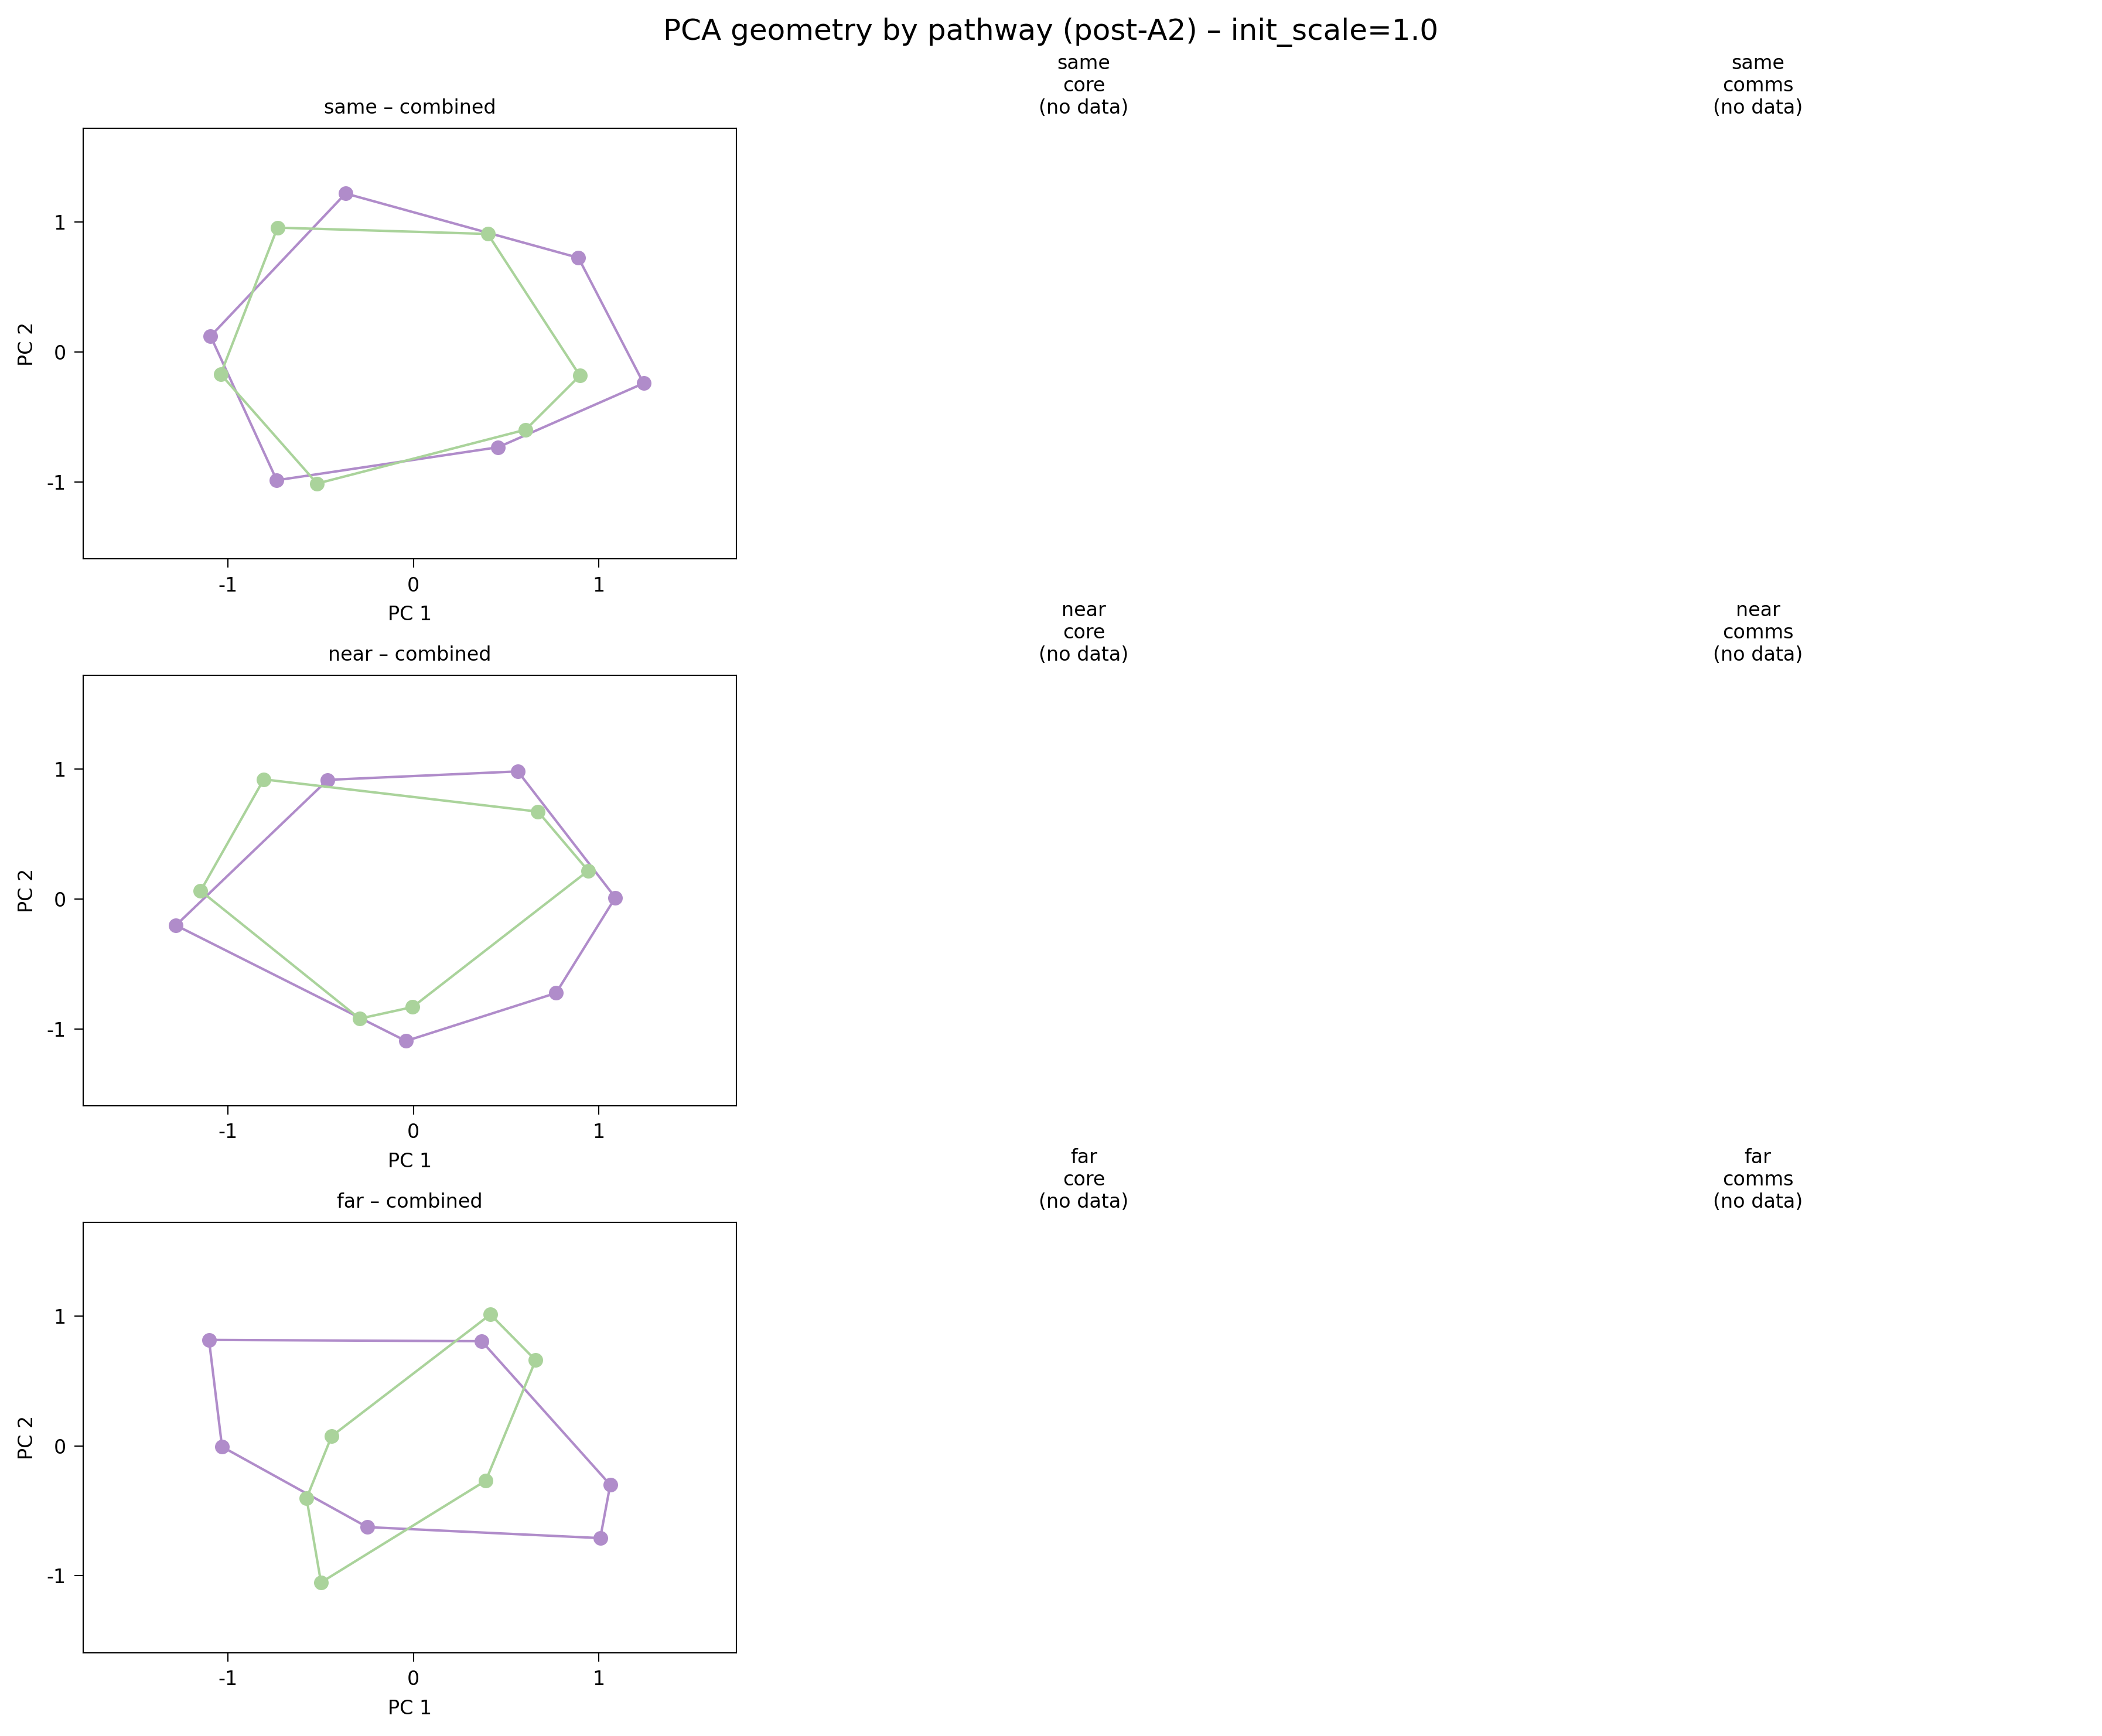

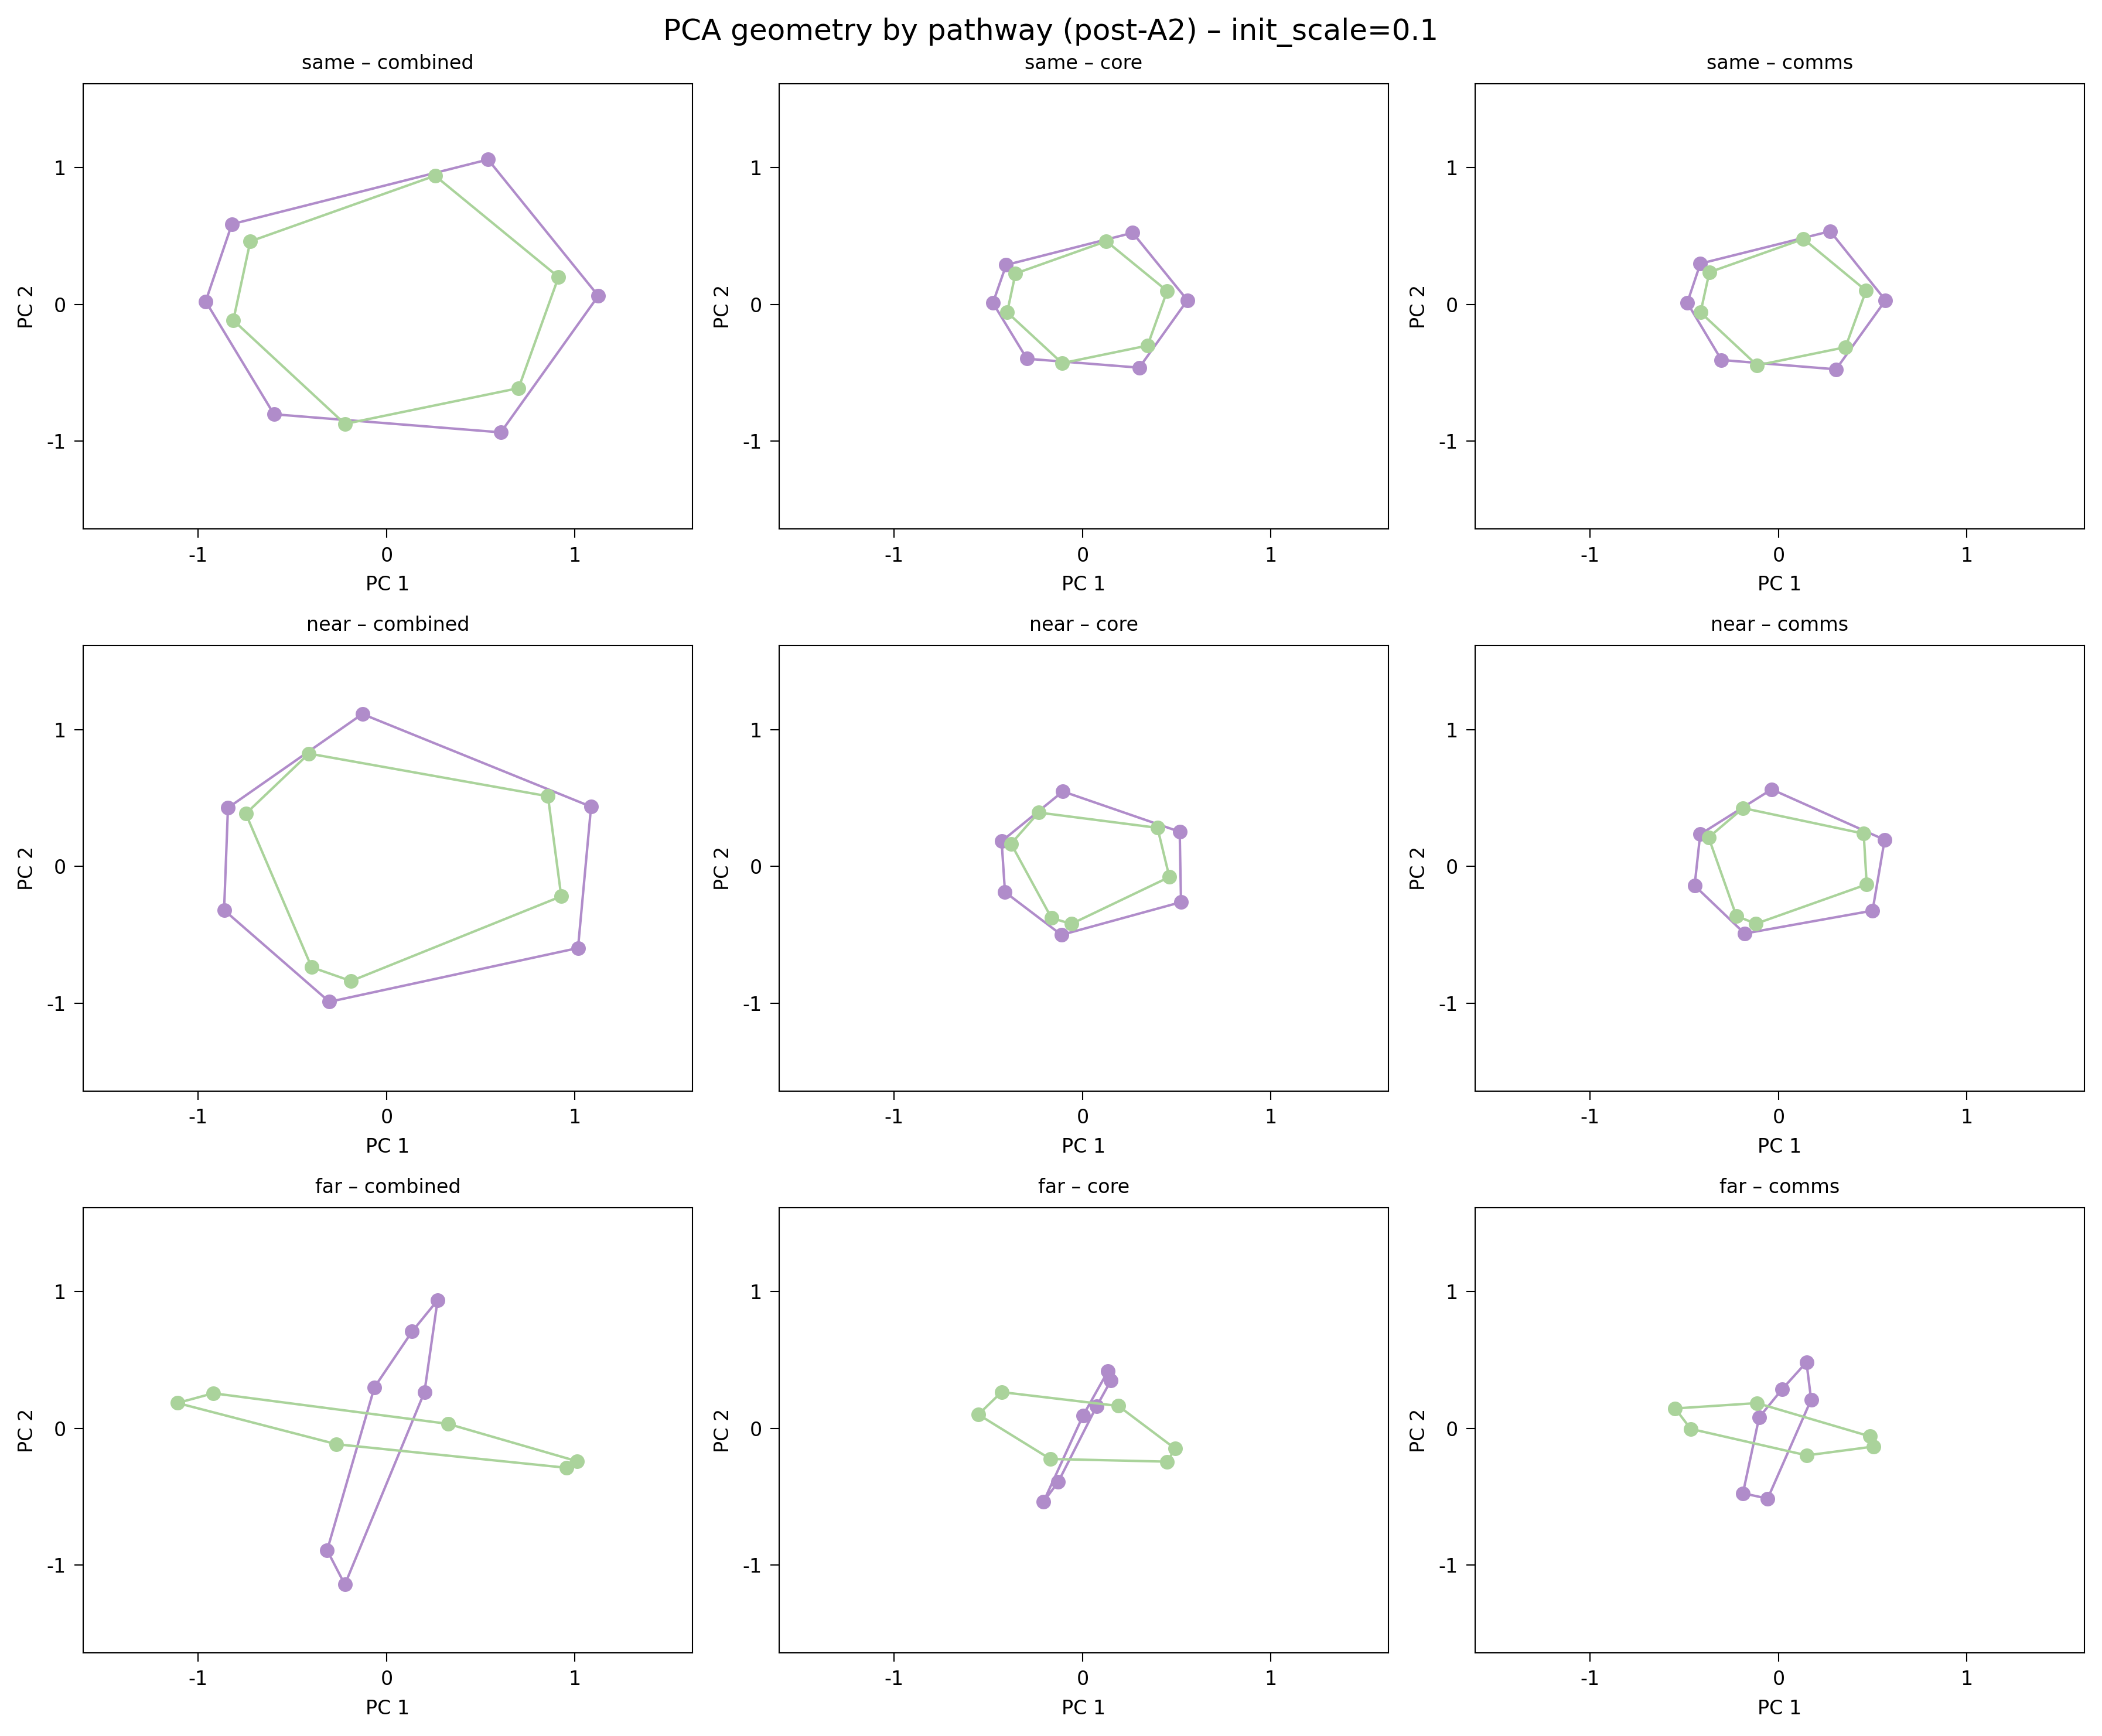

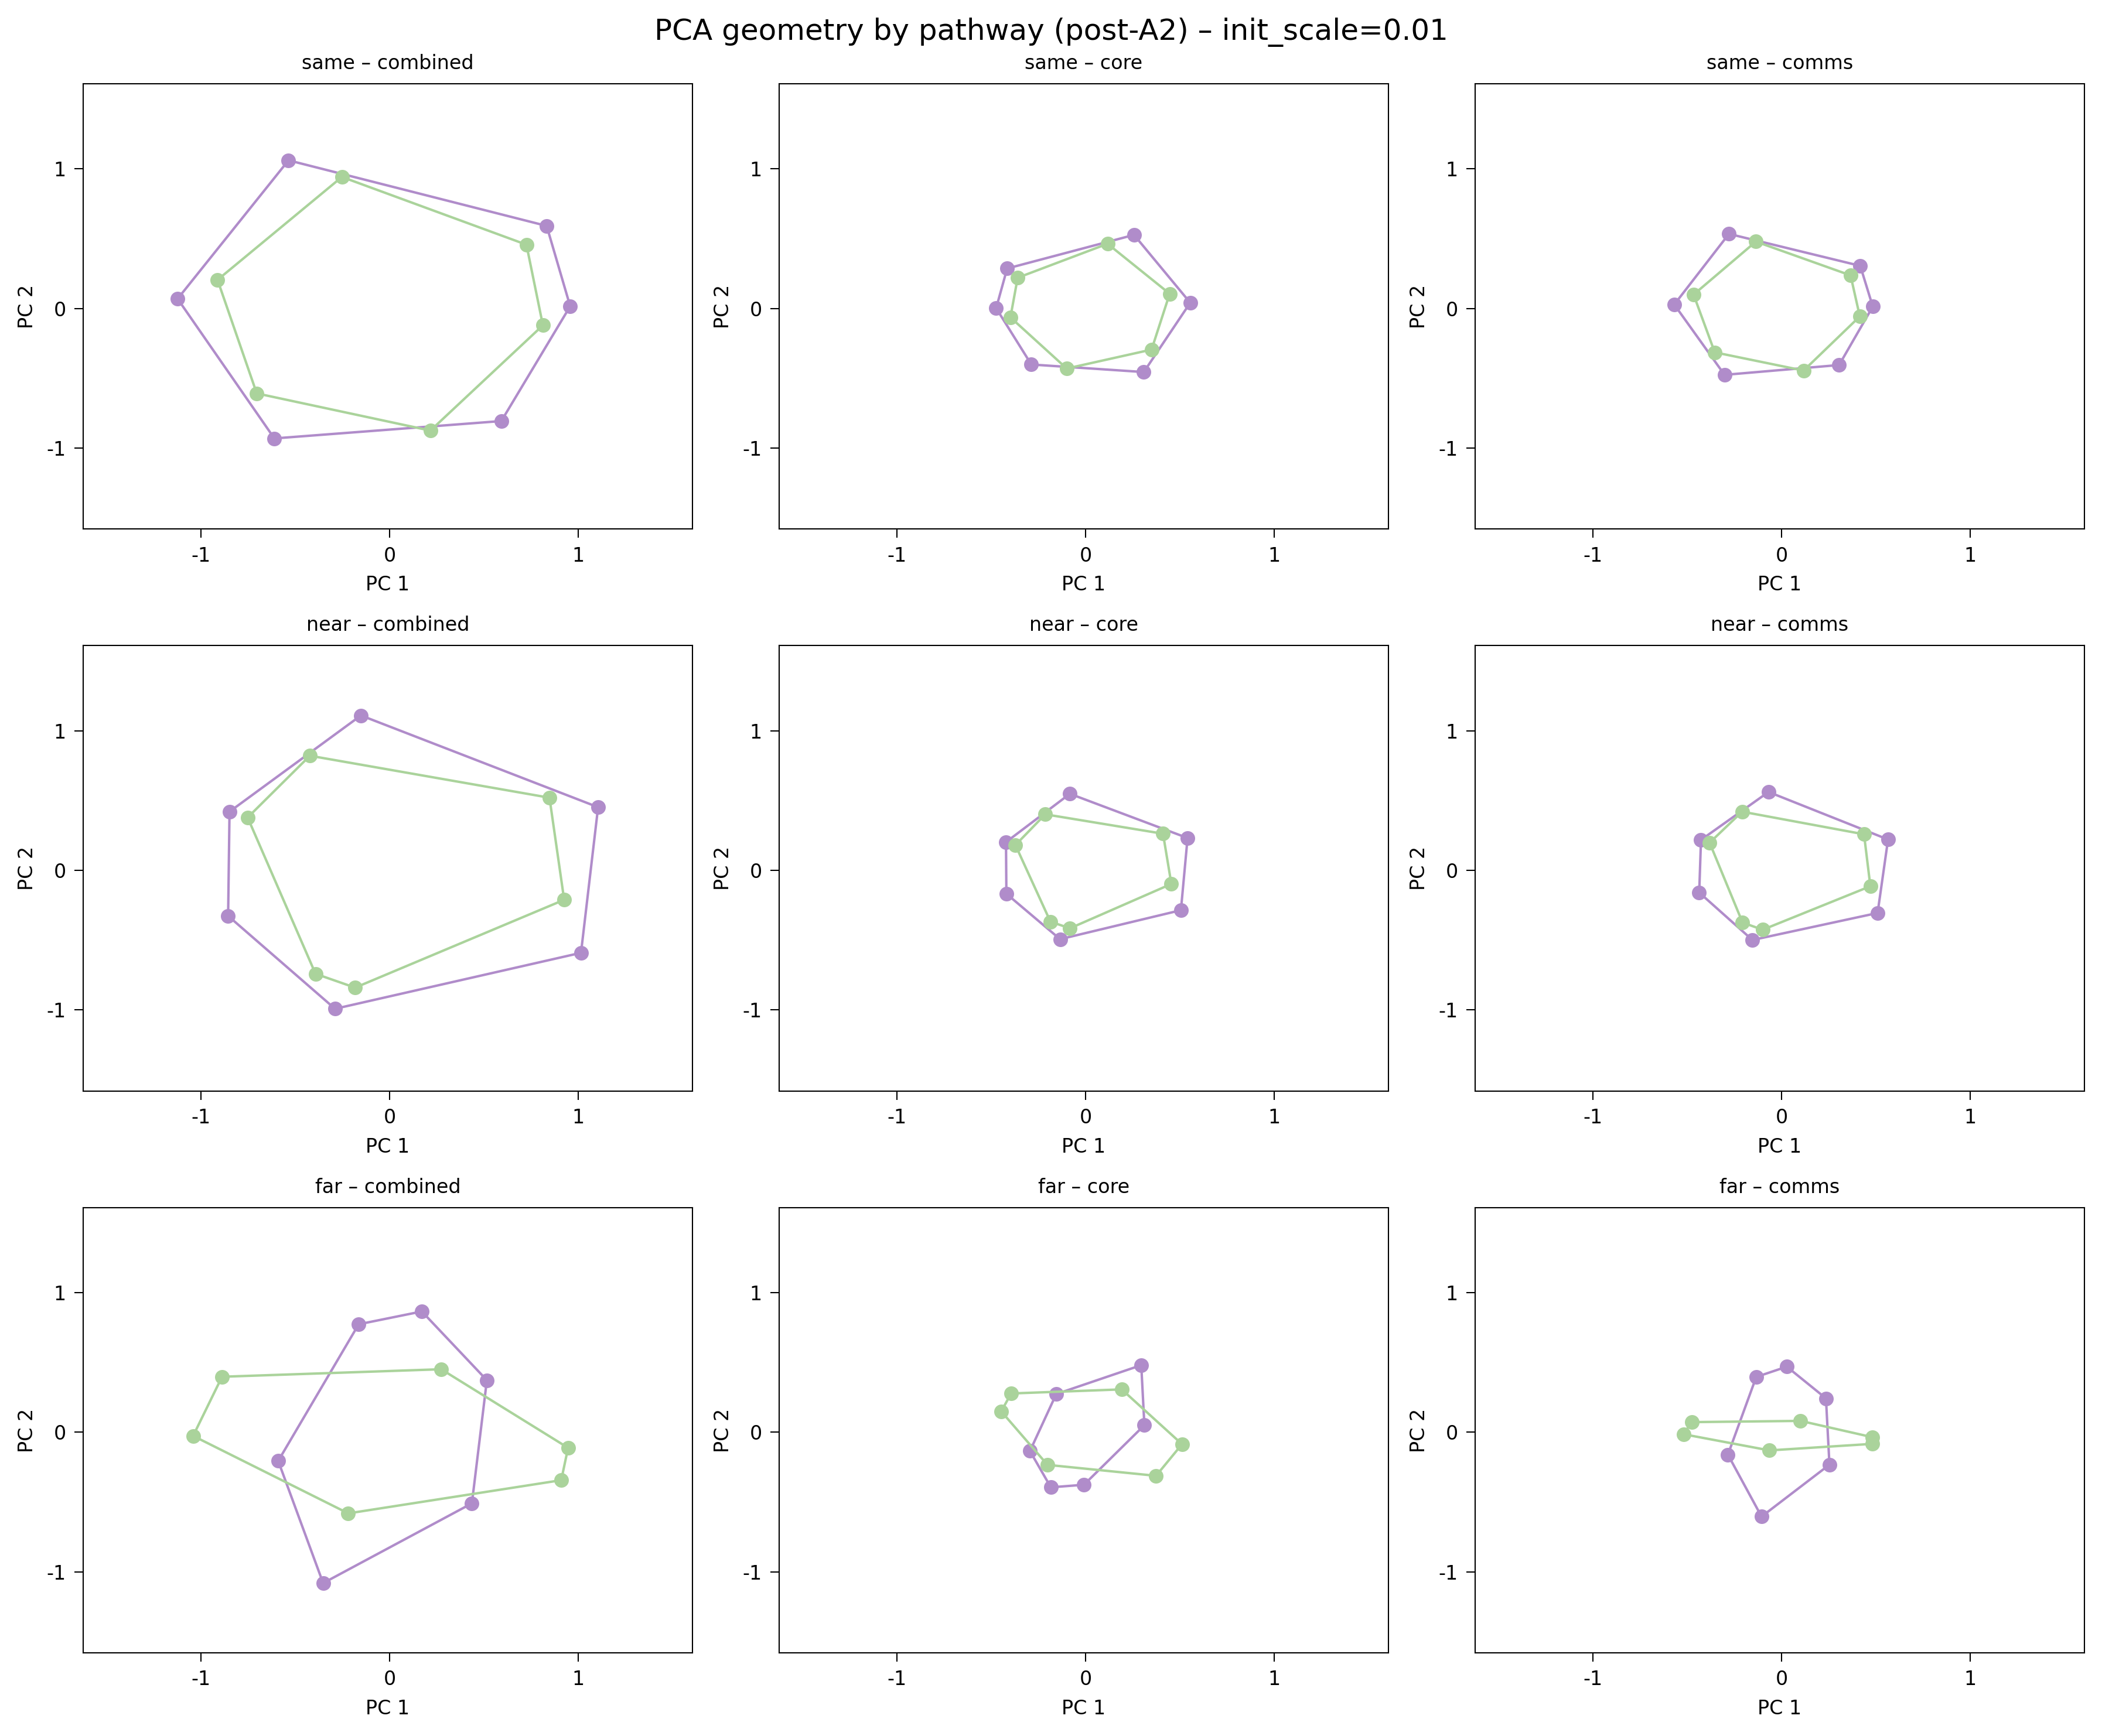

In [12]:
# PCA geometry: combined vs core vs comms per init_scale and similarity (same/near/far)

phase_idx = 2  # post-A2
n_stim_plot = 12
pathways = ["combined", "core", "comms"]

for run_id in run_labels:
    bundle = all_ann_data[run_id]
    init_scale = bundle["init_scale"]
    ann_data = bundle["data"]

    # 3 rows = same / near / far, 3 cols = combined / core / comms
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    fig.suptitle(f"PCA geometry by pathway (post-A2) – init_scale={init_scale}", fontsize=12)

    all_2d = []
    for row, cond in enumerate(["same", "near", "far"]):
        entries = ann_data.get(cond, [])
        for col, path in enumerate(pathways):
            ax = axes[row, col]
            if not entries:
                ax.set_title(f"{cond}\n{path}\n(no data)")
                ax.axis("off")
                all_2d.append(None)
                continue
            entry = entries[0]
            try:
                hids = ann._get_last_step_geometry_hids(entry, phase_idx, path=path)
            except (KeyError, ValueError):
                ax.set_title(f"{cond}\n{path}\n(no data)")
                ax.axis("off")
                all_2d.append(None)
                continue
            hids = np.asarray(hids)
            if hids.size == 0 or hids.shape[0] < n_stim_plot:
                ax.set_title(f"{cond}\n{path}\n(no data)")
                ax.axis("off")
                all_2d.append(None)
                continue
            hids = hids[:n_stim_plot]
            _, X2 = prepare_pca_single_task(hids)
            all_2d.append(X2)
            lims = get_axis_limits(X2)
            plot_split_stim(ax, X2, task_colours, lims)
            ax.set_title(f"{cond} – {path}")
            ax.set_xlabel("PC 1")
            ax.set_ylabel("PC 2")

    # Optional: use shared axis limits across all panels for comparable scale
    valid = [x for x in all_2d if x is not None]
    if valid:
        lims_global = get_axis_limits(np.vstack(valid))
        for row in range(3):
            for col in range(3):
                ax = axes[row, col]
                if all_2d[row * 3 + col] is not None:
                    ax.set_xlim(lims_global.get("xmin", 0) - 0.5, lims_global.get("xmax", 0) + 0.5)
                    ax.set_ylim(lims_global.get("ymin", 0) - 0.5, lims_global.get("ymax", 0) + 0.5)
    plt.tight_layout()
    plt.show()